In [175]:
import pandas as pd
import numpy as np


import glob
import itertools

import seaborn as sns

import matplotlib.colors as colors
import matplotlib.cm as cmx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from matplotlib_venn import venn2

from IPython.display import display, clear_output


from scipy.spatial import ConvexHull, convex_hull_plot_2d
from scipy.stats import spearmanr
from scipy.stats import sem

from scipy.spatial.distance import braycurtis, cdist
from skbio.stats.ordination import pcoa
from skbio.stats.distance import permanova, DistanceMatrix

### Outline 

Figures and analyses for the wild beer project

outputs of QC pipeline:  
`pipelines/cromwell-executions/quality_control/d5337b68-5bb8-415c-8fe2-901d053f6f73`  

```
# in trimmed_reads
cp ~/pipelines/cromwell-executions/quality_control/d5337b68-5bb8-415c-8fe2-901d053f6f73/call-Trimmomatic/shard-*/execution/*_R1.trimmed.fastq.gz .
cp ~/pipelines/cromwell-executions/quality_control/d5337b68-5bb8-415c-8fe2-901d053f6f73/call-Trimmomatic/shard-*/execution/*_R2.trimmed.fastq.gz .
cp ~/pipelines/cromwell-executions/quality_control/d5337b68-5bb8-415c-8fe2-901d053f6f73/call-Trimmomatic/shard-*/execution/*.summary .
cp ~/pipelines/cromwell-executions/quality_control/d5337b68-5bb8-415c-8fe2-901d053f6f73/call-Trimmomatic/shard-*/execution/*.trimlog .
cp ~/pipelines/cromwell-executions/quality_control/d5337b68-5bb8-415c-8fe2-901d053f6f73/call-Trimmomatic/shard-*/execution/fastqc_dir/*.trimmed_fastqc.html fastqc_resports
```

# Formatting functional data

In [168]:
# get interproscan name mapping to GO terms
interpro2go = pd.read_csv('/data/mhoffert/db/GO/interpro2go', sep=';', skiprows=6, header=None, names=['interpro_data', 'go'])
interpro2go['interpro_id'] = interpro2go['interpro_data'].apply(lambda x: x.split(':')[1].split(' ')[0])
interpro2go = interpro2go.set_index('interpro_id')['go']
# interpro2go.head()

# # get MAG name mapping
mag_gtdbtk = pd.read_csv('/data/mhoffert/fiererlab/beer/mag_pipeline/derep_mags/gtdbtk.bac120.summary.tsv', sep='\t')

mag2species = mag_gtdbtk.set_index('user_genome')['classification'].apply(lambda x: x.split(';')[-1])

mag2species.loc['S_cerevisiae'] = 'S_cerevisiae'
mag2species.loc['UO5-1_MAG_02'] = mag_gtdbtk.set_index('user_genome').loc['UO5-1_MAG_02', 'classification'].split(';')[-2]
mag2species.head()

# from collections import defaultdict


# # making functional table
interpro_columns = ['protein_accession', 'sequence_md5', 'sequence_length', 'analysis', 
                    'signature_accession', 'signature_description', 'start_location',
                    'stop_location', 'score', 'status', 'date', 'interpro_accession',
                    'interpro_annotations', 'mag']

interpro_tables = glob.glob('/data/mhoffert/fiererlab/beer/mag_pipeline/derep_mags/*interpro.tsv')
tables = pd.concat([pd.read_csv(i, sep='\t', header=None).assign(mag=mag2species.loc[i.split('/')[-1].split('_interpro')[0]]) for i in interpro_tables])
tables.columns = interpro_columns
tables = tables[~tables.interpro_accession.eq('-')]
tables = pd.merge(tables, interpro2go, left_on='interpro_accession', right_index=True, how='left')
tables['present'] = True

In [174]:
tables[tables['signature_description'].apply(lambda x: x.lower()).str.contains('amylase')]['signature_description'].unique()

array(['Carbohydrate-binding module 48 (Isoamylase N-terminal domain)',
       'Alpha amylase, catalytic domain', 'E_set_GDE_Isoamylase_N',
       'Putative glucoamylase',
       'Alpha amylase, C-terminal all-beta domain',
       'Maltogenic Amylase, C-terminal domain',
       'Alpha amylase, N-terminal ig-like domain'], dtype=object)

In [165]:
pd.read_csv(interpro_tables[0], sep='\t', header=None)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,NODE_5_length_427411_cov_244.668763_47,4381a9e62fee802b1694bdb5d2d345a5,458,Gene3D,G3DSA:3.30.70.1170,Sun protein; domain 3,137,241,2.1E-15,T,26-05-2023,-,-
1,NODE_5_length_427411_cov_244.668763_47,4381a9e62fee802b1694bdb5d2d345a5,458,SUPERFAMILY,SSF53335,S-adenosyl-L-methionine-dependent methyltransf...,143,445,8.29E-71,T,26-05-2023,IPR029063,S-adenosyl-L-methionine-dependent methyltransf...
2,NODE_5_length_427411_cov_244.668763_47,4381a9e62fee802b1694bdb5d2d345a5,458,CDD,cd02440,AdoMet_MTases,255,380,4.11075E-10,T,26-05-2023,-,-
3,NODE_5_length_427411_cov_244.668763_47,4381a9e62fee802b1694bdb5d2d345a5,458,PRINTS,PR02008,RNA (C5-cytosine) methyltransferase signature,228,242,7.6E-27,T,26-05-2023,IPR023267,RNA (C5-cytosine) methyltransferase
4,NODE_5_length_427411_cov_244.668763_47,4381a9e62fee802b1694bdb5d2d345a5,458,PRINTS,PR02008,RNA (C5-cytosine) methyltransferase signature,257,267,7.6E-27,T,26-05-2023,IPR023267,RNA (C5-cytosine) methyltransferase
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18750,NODE_2_length_513548_cov_317.819548_47,8a4cbb3210cf762b8e2ee7c8627999b5,264,ProSitePatterns,PS00061,Short-chain dehydrogenases/reductases family s...,142,170,-,T,26-05-2023,IPR020904,"Short-chain dehydrogenase/reductase, conserved..."
18751,NODE_2_length_513548_cov_317.819548_47,8a4cbb3210cf762b8e2ee7c8627999b5,264,PANTHER,PTHR42879,3-OXOACYL-(ACYL-CARRIER-PROTEIN) REDUCTASE,5,260,1.8E-53,T,26-05-2023,-,-
18752,NODE_2_length_513548_cov_317.819548_47,8a4cbb3210cf762b8e2ee7c8627999b5,264,CDD,cd05233,SDR_c,11,257,2.81254E-69,T,26-05-2023,-,-
18753,NODE_2_length_513548_cov_317.819548_47,8a4cbb3210cf762b8e2ee7c8627999b5,264,SMART,SM00822,This enzymatic domain is part of bacterial pol...,9,192,0.0046,T,26-05-2023,-,-


## Figure 0 - samples with too few reads

FileNotFoundError: [Errno 2] No such file or directory: '/data/ftp/2022_10_3_WildBeer_NovaSeqMG/post_trim_data/summaries/read_counts.txt'

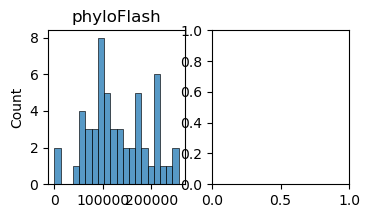

In [8]:
fig = plt.figure(figsize = (6,2))
ax = fig.add_subplot(1,3,1)
sns.histplot(pd.read_csv('/data/mhoffert/fiererlab/beer/project_data_and_tutorials/data/2022_10_20_WildBeer.phyloFlash.NTUfull_abundance.csv').pivot_table(index='NTU_taxonomy', columns='sample', values='read_count').fillna(0).sum(),
            kde=False, bins=20)
plt.tick_params(labelsize=10)

ax.set_title('phyloFlash', fontsize=12)

ax = fig.add_subplot(1,3,2)
sns.histplot(pd.read_csv('/data/ftp/2022_10_3_WildBeer_NovaSeqMG/post_trim_data/summaries/read_counts.txt', 
                         sep='\t', header=None, index_col=0),
            kde=False, bins=20)
plt.tick_params(labelsize=10)
ax.set_xticks([i for i in np.linspace(0, 4e7, 4)])
ax.set_xticklabels([f'{i:.2E}' for i in np.linspace(0, 4e7, 4)], rotation=45)
ax.set_title('MG reads', fontsize=12)



### Loading in mapping files from bowtie2
fix these links - summaries should still be in the cromwell dir

In [9]:
mapped_counts = glob.glob('/data/mhoffert/fiererlab/beer/mag_pipeline/bowtie2_map/*count.txt')
df_list = []
for m in mapped_counts:
    df = pd.read_csv(m, header=None).assign(sample_name=m.split('/')[-1].split('_mapped')[0])
    df_list.append(df)
mapped_counts_df = pd.concat(df_list)

In [10]:
read_counts = glob.glob('/data/ftp/2022_10_3_WildBeer_NovaSeqMG/post_trim_data/summaries/*.summary')

In [11]:
input_reads = pd.concat([pd.read_csv(r, header=None, sep=': ', engine='python').assign(sample_name=r.split('/')[-1].split('.summary')[0]) for r in read_counts])

ValueError: No objects to concatenate

In [12]:
total_reads = input_reads[input_reads[0].str.contains('Both Surviving Reads')].set_index('sample_name')[1].rename('total_reads')

NameError: name 'input_reads' is not defined

In [12]:
# full_map_df = pd.merge(mapped_df, mapped_counts_df.rename(columns={0:'reads_mapped'}), left_on='sample_name', right_on='sample_name')

In [13]:
full_map_df = pd.merge(total_reads, mapped_counts_df.rename(columns={0:'reads_mapped'}), left_index=True, right_on='sample_name')

In [14]:
full_map_df['frac_mapped'] =  full_map_df['reads_mapped'] / full_map_df['total_reads']

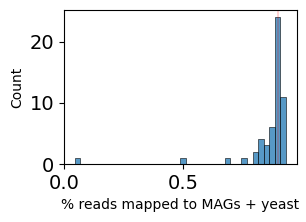

In [15]:
fig, ax = plt.subplots(figsize=(3,2))
sns.histplot(full_map_df['frac_mapped'], ax=ax)
ax.axvline(0.90, color='red', zorder=1, linewidth=0.25)
ax.set_xlabel('% reads mapped to MAGs + yeast', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
plt.tick_params(labelsize=14)


## Figure 1

### Bar plot

In [13]:
sns.set(font_scale=1.5)
sns.set_style('white')

In [ ]:
# additional data: alcohol and sugars

In [36]:
plotdf.columns

Index(['sample_name', 'species', 'rpkm', 'Unnamed: 0', 'Sample Description',
       'Sample Name', 'Sample ID', 'timepoint', 'Filter replicate', 'pH',
       'Density', 'Scent notes', 'Notes', 'Hops', 'Location', 'treatment',
       'Fructose', 'Glucose', 'Sucrose', 'Maltose', 'Maltotriose', 'Method',
       'Density Temperature', 'Alcohol (% v/v)', 'Alcohol (% w/w)',
       'Specific Gravity', 'Ea (app. extract) (% w/w)',
       'Er (real extract) (% w/w)', 'p (original extract) (% w/w)',
       'Concentration Sugar', 'RDF (real deg. of ferm.)', 'ADF (% w/w)',
       'Calories (kcal/12oz)'],
      dtype='object')

In [35]:
plotdf[sugars]

,Fructose,Glucose,Sucrose,Maltose,Maltotriose
0,1.5,5.000000,6.500000,49.700000,17.200000
1,1.5,5.000000,6.500000,49.700000,17.200000
2,1.5,5.000000,6.500000,49.700000,17.200000
3,1.5,5.000000,6.500000,49.700000,17.200000
4,1.5,5.000000,6.500000,49.700000,17.200000
...,...,...,...,...,...
454,0.0,0.041511,0.053035,0.051548,13.727103
455,0.0,0.041511,0.053035,0.051548,13.727103
456,0.0,0.041511,0.053035,0.051548,13.727103
457,0.0,0.041511,0.053035,0.051548,13.727103


In [81]:
# prep data
strip_plotdf = plotdf[['sample_name', 'species', 'rpkm', 'timepoint', 'treatment', 'pH', 'Maltose', 'Alcohol (% v/v)']].copy(deep=True)
strip_plotdf['replicate'] = strip_plotdf['sample_name'].apply(lambda x: x.split('-')[0][-1])
strip_plotdf['Alcohol\n(% v/v)'] = strip_plotdf['Alcohol (% v/v)'].fillna(0).replace('---', np.nan).astype(float)
species_reformat = dict((x, x.replace('S_', 'Saccharomyces ').split('__')[-1].replace('Enterobacter', 'unclassified Enterobacter').replace('_', ' ')) for x in strip_plotdf['species'].unique())

In [38]:
# color_map = dict(zip(order, ['green',  'skyblue', 'blue', 'darkblue', 'red', 'gray', 'lightcoral', 'dodgerblue']))
species_color_map = {'s__Gluconobacter_A japonicus': 'green',
 's__Schleiferilactobacillus harbinensis': 'skyblue',
 's__Pantoea agglomerans':'red',
 's__Levilactobacillus brevis': 'darkblue',
 's__Lentilactobacillus parabuchneri': 'blue',
 'g__Enterobacter': 'lightcoral', 
 'S_cerevisiae': 'gray',
 's__Pseudescherichia vulneris': 'firebrick',
 's__Lacticaseibacillus paracasei':'dodgerblue',}

In [39]:
species_color_map.items()

dict_items([('s__Gluconobacter_A japonicus', 'green'), ('s__Schleiferilactobacillus harbinensis', 'skyblue'), ('s__Pantoea agglomerans', 'red'), ('s__Levilactobacillus brevis', 'darkblue'), ('s__Lentilactobacillus parabuchneri', 'blue'), ('g__Enterobacter', 'lightcoral'), ('S_cerevisiae', 'gray'), ('s__Pseudescherichia vulneris', 'firebrick'), ('s__Lacticaseibacillus paracasei', 'dodgerblue')])

In [91]:
def stacked_bar(tidy_data, x, y, hue_col, order, palette_map, ax, norm=True):
    hues = tidy_data[hue_col].unique()
    piv = tidy_data.pivot_table(index=hue_col, columns=x, values=y).reindex(index=order)
    
    if norm:
        cumsum = piv.divide(piv.sum(0)).cumsum()
        # cumsum = piv.cumsum()
        cumsum = cumsum.stack().reset_index().rename(columns={0:y})
    else:
        cumsum = piv.cumsum()
        cumsum = cumsum.stack().reset_index().rename(columns={0:y})

    for hue_item, z in zip(order, range(len(order), 0, -1)):
        sns.barplot(data=cumsum[cumsum.species.eq(hue_item)], x=x, y=y, color=palette_map[hue_item], zorder=z, ax=ax)
        
def plot_md(tidy_data, chem_var, treatment, lims, ax): 
    # subset = tidy_data[tidy_data['timepoint'].eq(timepoint) & tidy_data['treatment'].eq(treatment)]
    subset = strip_plotdf[strip_plotdf['treatment'].eq(treatment)]
    sns.scatterplot(data=subset, y=chem_var, x='replicate', ax=ax, 
                    alpha=0.65, s=75,
                    hue='timepoint', palette=['lightgray', 'k'], legend=False)

    ax.set_ylabel(chem_var, rotation=0)
    # lims = (strip_plotdf[chem_var].min(), strip_plotdf[chem_var].max())
    ax.set_ylim(lims[0], lims[1])
    # for hline in [subset]:
    hline = tidy_data[tidy_data.timepoint.eq('initial')][chem_var].mean()
    ax.axhline(hline, color='gray', alpha=1, zorder=0, linewidth=0.5)

In [41]:
# %config InlineBackend.print_figure_kwargs={'bbox_inches':'tight'}

In [42]:
strip_plotdf

,sample_name,species,rpkm,timepoint,treatment,pH,Maltose,Alcohol (% v/v),replicate
0,HC1,S_cerevisiae,107.758136,initial,HC,5.29,49.700000,NaN,1
1,HC1,g__Enterobacter,36.448063,initial,HC,5.29,49.700000,NaN,1
2,HC1,s__Gluconobacter_A japonicus,0.000164,initial,HC,5.29,49.700000,NaN,1
3,HC1,s__Lacticaseibacillus paracasei,0.180938,initial,HC,5.29,49.700000,NaN,1
4,HC1,s__Lentilactobacillus parabuchneri,0.017283,initial,HC,5.29,49.700000,NaN,1
...,...,...,...,...,...,...,...,...,...
454,UO6-3,s__Lentilactobacillus parabuchneri,34.247458,3 week,UO,3.68,0.051548,4.1,6
455,UO6-3,s__Levilactobacillus brevis,0.062558,3 week,UO,3.68,0.051548,4.1,6
456,UO6-3,s__Pantoea agglomerans,4.291070,3 week,UO,3.68,0.051548,4.1,6
457,UO6-3,s__Pseudescherichia vulneris,113.086363,3 week,UO,3.68,0.051548,4.1,6


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


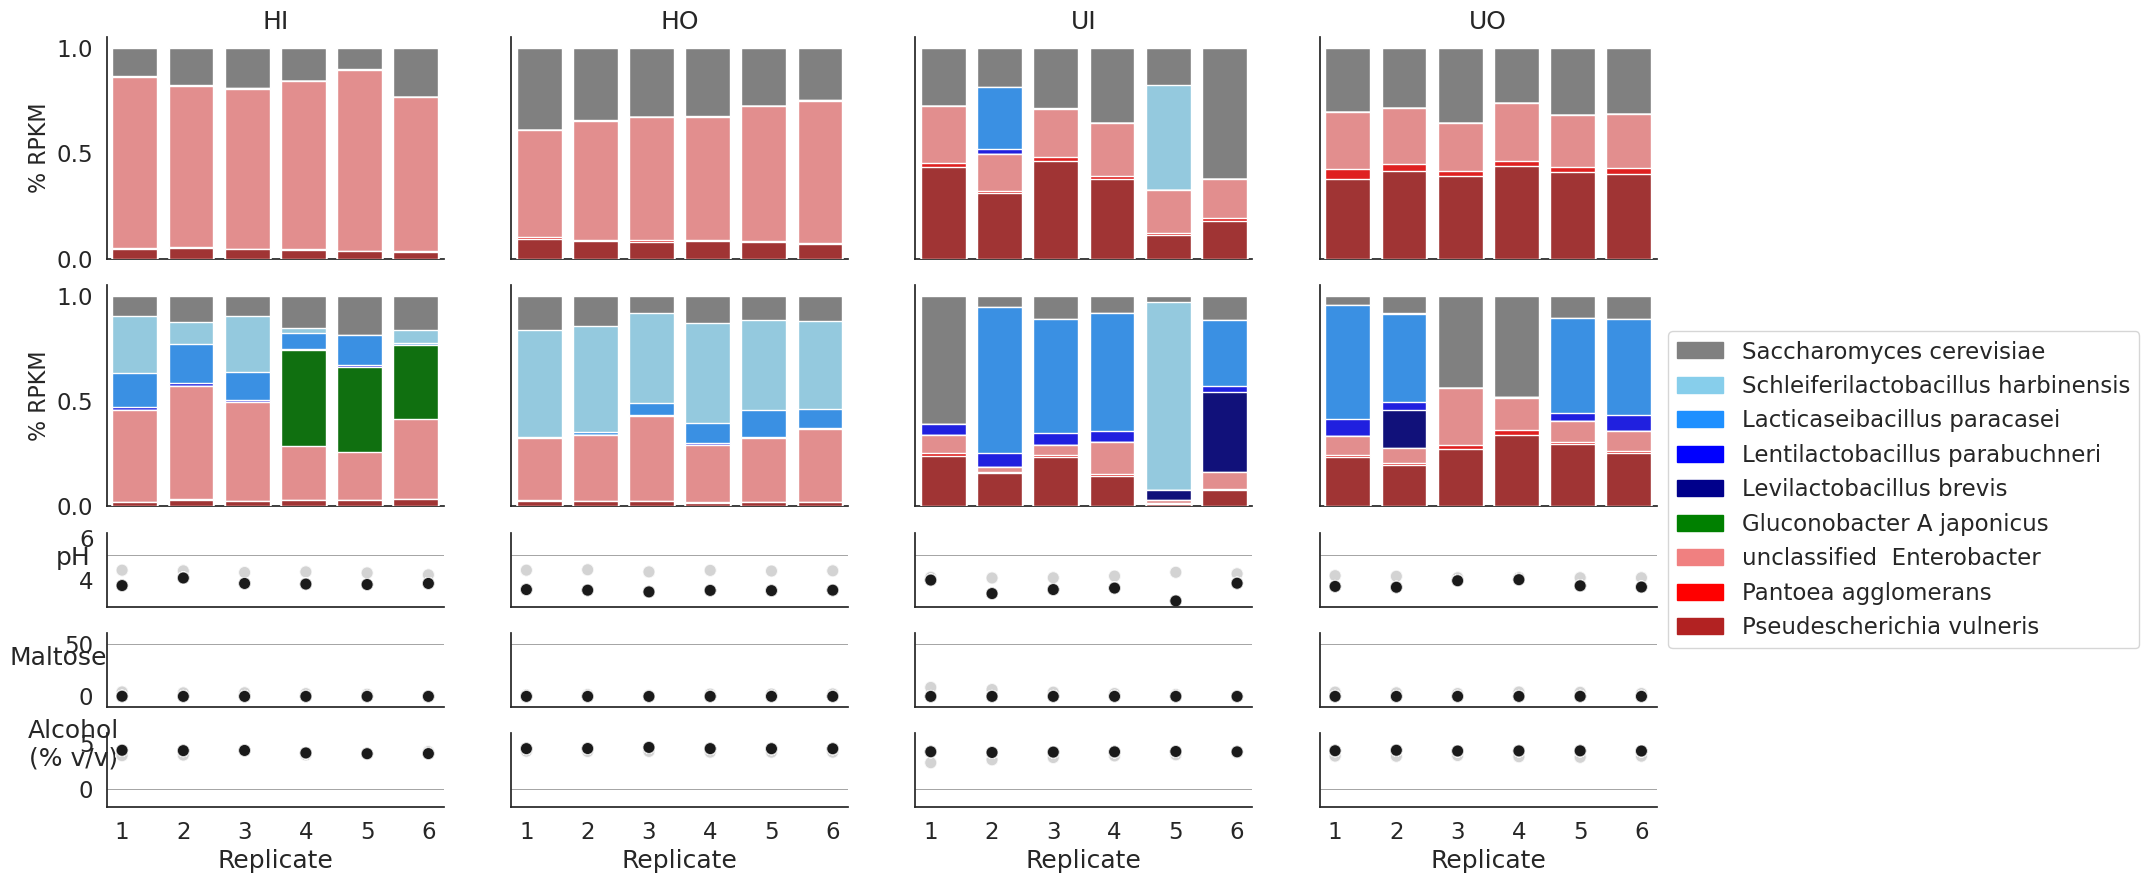

In [97]:
mag_order = ['S_cerevisiae',
             's__Schleiferilactobacillus harbinensis',
             's__Lacticaseibacillus paracasei',
             's__Lentilactobacillus parabuchneri',
             's__Levilactobacillus brevis', 
             's__Gluconobacter_A japonicus',  
             'g__Enterobacter', 
             's__Pantoea agglomerans',
             's__Pseudescherichia vulneris', 
             ]

# do it manually
fig = plt.figure(figsize=(20, 10))
# column and row control
nrow, ncol = 5, 4
gs = fig.add_gridspec(nrow, ncol, height_ratios=(3,3,1,1,1), width_ratios=(5,5,5,5))
i = 1
axes = []
# chemistry metadata have week 1 and 3 plotted simultaneously
weeks = ['1 week', '3 week', '3 week', '3 week', '3 week']
treatments = ['HI', 'HO', 'UI', 'UO']

# while i < (nrow * ncol):
for timepoint, treatment in list(itertools.product(weeks, treatments)):

    # print(treatment, timepoint, np.floor(i / ncol- 0.01), i)

    y_plot_index = int(np.floor(i / ncol - 0.01))
    # print(y_plot_index)
    print(i)

    ax = fig.add_subplot(gs[y_plot_index, treatments.index(treatment)])

    if y_plot_index in [0, 1]:

        subset = strip_plotdf[strip_plotdf['timepoint'].eq(timepoint) & strip_plotdf['treatment'].eq(treatment)]
        stacked_bar(tidy_data=subset, x='replicate', y='rpkm', hue_col='species', order=mag_order[::-1], palette_map=species_color_map, ax=ax)

        ax.set_ylabel('% RPKM', fontsize=16)

        upper =  int(np.floor(ax.get_ylim()[1] / 100))
        for j in np.linspace(100, upper * 100, upper):
            ax.axhline(j, zorder=0, color='k', alpha=1, linewidth=0.5)

        if i <= 4:
            ax.set_title(treatment)


    elif y_plot_index == 2:

        plot_md(strip_plotdf, 'pH', treatment, (2.75, 6.25), ax)
            
    elif y_plot_index == 3:
        
        plot_md(strip_plotdf, 'Maltose', treatment, (-10, 60), ax)
        ax.tick_params(labelbottom=False)
        # ax.set_xlabel('test')
        
    else:
        plot_md(strip_plotdf, 'Alcohol\n(% v/v)', treatment, (-2, 6), ax)


    if i < 17:
        ax.set_xlabel('')
        plt.tick_params(bottom=False, labelbottom=False)
    else:
        ax.set_xlabel('Replicate')



    if i % 4 != 1:
        ax.set_ylabel('')
        plt.tick_params(left=False, labelleft=False)

    sns.despine()    

    i += 1
    
patches = [mpatches.Patch(color=species_color_map[key], label=key) for key in mag_order]
labels = [l.replace('s__', '').replace('_', ' ').replace('S ', 'Saccharomyces ').replace('g ', 'unclassified ') for l in mag_order]
lgd = plt.legend(labels=labels, handles=patches, loc='lower left', bbox_to_anchor=(1, 2))
    
# # loop for pH plots
# for ph_i in range(4):
#     ax = fig.add_subplot(gs[2, ph_i])
    
    

# plt.savefig('/data/mhoffert/fiererlab/beer/data/figures/taxa_plots.svg', bbox_extra_artists=(lgd,), bbox_inches='tight', dpi=300)
plt.savefig('/data/mhoffert/fiererlab/beer/data/figures/taxa_plots.svg', bbox_extra_artists=(lgd,), bbox_inches='tight')

In [27]:
mag2species

NameError: name 'mag2species' is not defined

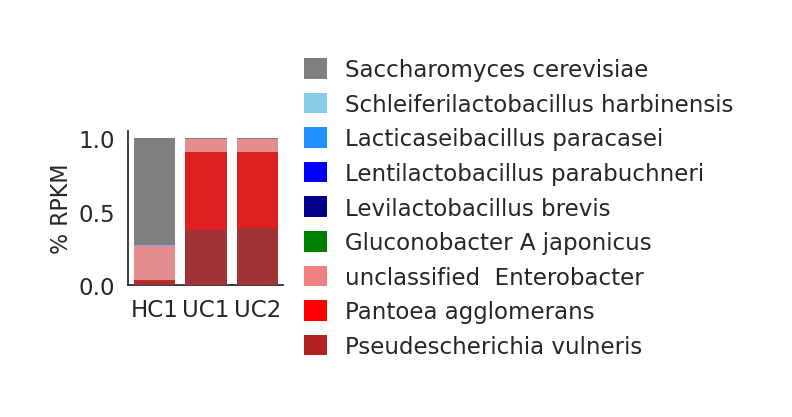

In [281]:
# control plot
mag_order = ['S_cerevisiae',
             's__Schleiferilactobacillus harbinensis',
             's__Lacticaseibacillus paracasei',
             's__Lentilactobacillus parabuchneri',
             's__Levilactobacillus brevis', 
             's__Gluconobacter_A japonicus',  
             'g__Enterobacter', 
             's__Pantoea agglomerans',
             's__Pseudescherichia vulneris', 
             ]

# do it manually
fig = plt.figure(figsize=(2, 2))
ax = fig.add_subplot(1,1,1)
        
subset = strip_plotdf[strip_plotdf['timepoint'].eq('initial') & strip_plotdf['treatment'].isin(['HC', 'UC'])]
stacked_bar(tidy_data=subset, x='sample_name', y='rpkm', hue_col='species', order=mag_order[::-1], palette_map=species_color_map, ax=ax, norm=True)

ax.set_ylabel('% RPKM', fontsize=16)

#         upper =  int(np.floor(ax.get_ylim()[1] / 100))
#         for j in np.linspace(100, upper * 100, upper):
#             ax.axhline(j, zorder=0, color='k', alpha=1, linewidth=0.5)
            
#         if i <= 4:
#             ax.set_title(treatment)
        
    

    
patches = [mpatches.Patch(color=species_color_map[key], label=key) for key in mag_order]
labels = [l.replace('s__', '').replace('_', ' ').replace('S ', 'Saccharomyces ').replace('g ', 'unclassified ') for l in mag_order]
lgd = plt.legend(labels=labels, handles=patches, loc='center left', bbox_to_anchor=(1, 0.5))

sns.despine()
ax.set_xlabel('')

# # loop for pH plots
# for ph_i in range(4):
#     ax = fig.add_subplot(gs[2, ph_i])
    
    

plt.savefig('/data/mhoffert/fiererlab/beer/data/figures/controls.png', bbox_extra_artists=(lgd,), bbox_inches='tight', dpi=400)

In [24]:
subset

,sample_name,species,rpkm,timepoint,treatment,pH,replicate


In [15]:
# sns.scatterplot(data=plotdf[plotdf.species.eq('s__Schleiferilactobacillus harbinensis')], x='rpkm', y='pH', hue='species')

## Supplemental Figure 1: chemistry data

In [260]:
md = pd.read_csv('/data/mhoffert/fiererlab/beer/project_data_and_tutorials/data/2022_10_12_WildBeer_metadata.tsv', sep='\t')
sf1_plotdf = md.copy(deep=True)

In [273]:
sf1_plotdf['Alcohol (% v/v)'] = sf1_plotdf['Alcohol (% v/v)'].replace('---', np.nan)
tidy_plotdf = sf1_plotdf.set_index('Sample ID')[['pH', 'Density', 'Glucose', 'Sucrose', 'Maltose', 'Maltotriose',  'Alcohol (% v/v)']].stack().reset_index().rename(columns={'level_1':'measurement', 0:'value'})
tidy_plotdf['timepoint (weeks)'] = tidy_plotdf['Sample ID'].apply(lambda x: '0' if 'C' in x else x.split('-')[-1])
tidy_plotdf['hops'] = tidy_plotdf['Sample ID'].apply(lambda x: x[0])
tidy_plotdf['exposure'] = tidy_plotdf['Sample ID'].apply(lambda x: x[1] if not 'C' in x else 'C')
tidy_plotdf['value'] = tidy_plotdf['value'].astype(float)

In [270]:
tidy_plotdf['treatment'] = tidy_plotdf.apply(lambda row: f'{row["hops"]}{row["exposure"]}', axis=1)
tidy_plotdf['replicate'] = tidy_plotdf['Sample ID'].apply(lambda x: x.split('-')[0][-1])

In [271]:
tidy_plotdf.head()

,Sample ID,measurement,value,timepoint (weeks),hops,exposure,treatment,replicate
0,HC1,pH,5.29,0,H,C,HC,1
1,HC1,Density,10.0,0,H,C,HC,1
2,HC1,Glucose,5.0,0,H,C,HC,1
3,HC1,Sucrose,6.5,0,H,C,HC,1
4,HC1,Maltose,49.7,0,H,C,HC,1


In [272]:
tidy_plotdf['timepoint (weeks)']

0      0
1      0
2      0
3      0
4      0
      ..
396    3
397    3
398    3
399    3
400    3
Name: timepoint (weeks), Length: 401, dtype: object

### New version of plot

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


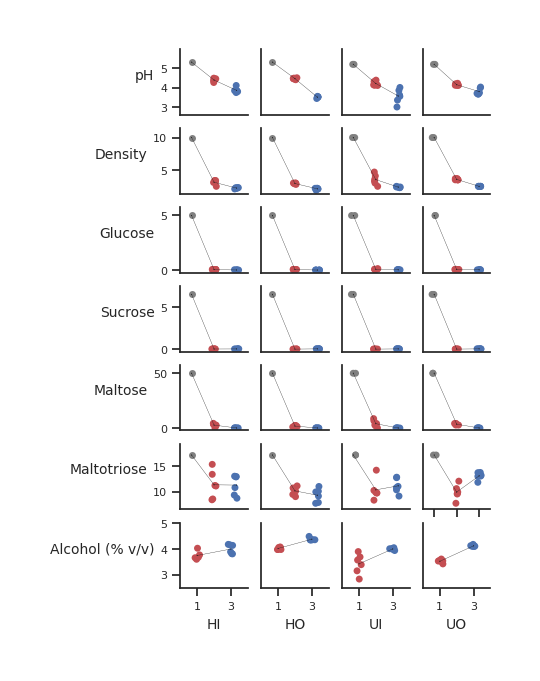

In [268]:
i = 1
rows = tidy_plotdf[tidy_plotdf['timepoint (weeks)'] != '0']['measurement'].unique()
cols = tidy_plotdf[tidy_plotdf['timepoint (weeks)'] != '0']['treatment'].unique()
fig = plt.figure(figsize=(4,7))
for row in rows:
    row_axes = []
    row_i = 0
    for col in cols:
        if len(row_axes) == 0:
            ax = fig.add_subplot(len(rows), len(cols), i)
        else:
            ax = fig.add_subplot(len(rows), len(cols), i, sharey=row_axes[row_i - 1])
        row_axes.append(ax)
        row_i += 1
        sns.stripplot(data=tidy_plotdf[tidy_plotdf.measurement.eq(row) & tidy_plotdf['treatment'].isin([col, col[0] + 'C'])],
                     x='timepoint (weeks)', y='value', hue='timepoint (weeks)',  hue_order=['0', '1', '3'], palette=['gray', 'r', 'b'], zorder=1)
        
        sns.pointplot(data=tidy_plotdf[tidy_plotdf.measurement.eq(row) & tidy_plotdf['treatment'].isin([col, col[0] + 'C'])],
                     x='timepoint (weeks)', y='value', errwidth=0, color='k', scale=0.25)
        ax.get_legend().remove()
        plt.tick_params(labelsize=8, labelleft=False, labelbottom=False)
        sns.despine()
        ylims = ax.get_ylim()
        # ax.set_xticks(['0', '1', '3'])
        if i % 4 == 1:
            ax.set_ylabel(row, fontsize=10, rotation=0, ha='right')
            plt.tick_params(labelleft=True, left=True)
        else:
            ax.set_ylabel(' ')
            
        if i < 24:
            ax.set_xlabel(' ')
        else:
            ax.set_xlabel(col, fontsize=10)
            plt.tick_params(labelbottom=True, bottom=True)
        

            
        # for ytick in ax.get_yticks():
        #     print(ytick)
        #     ax.axhline(ytick, zorder=0, alpha=0.5, color='gray', linewidth=0.5)
            
        if i % 4 == 0:
            ax.set_ylim(ylims[0]*0.9, ylims[1]*1.1)

        i += 1
        print(i)

plt.savefig('/data/mhoffert/fiererlab/beer/data/figures/SF1.png', dpi=400, bbox_inches='tight')

## Figure 2

In [99]:
# get MAG name mapping
mag_gtdbtk = pd.read_csv('/data/mhoffert/fiererlab/beer/mag_pipeline/derep_mags/gtdbtk.bac120.summary.tsv', sep='\t')

mag2species = mag_gtdbtk.set_index('user_genome')['classification'].apply(lambda x: x.split(';')[-1])

In [100]:
mag2species

user_genome
HI4-3_MAG_04              s__Gluconobacter_A japonicus
HO2-3_MAG_03           s__Lacticaseibacillus paracasei
HO2-3_MAG_04    s__Schleiferilactobacillus harbinensis
UO2-1_MAG_03                    s__Pantoea agglomerans
UO2-3_MAG_03               s__Levilactobacillus brevis
UO5-1_MAG_01              s__Pseudescherichia vulneris
UO5-1_MAG_02                                       s__
UO6-3_MAG_03        s__Lentilactobacillus parabuchneri
Name: classification, dtype: object

In [258]:
mag_gtdbtk

,user_genome,classification,fastani_reference,fastani_reference_radius,fastani_taxonomy,fastani_ani,fastani_af,closest_placement_reference,closest_placement_radius,closest_placement_taxonomy,closest_placement_ani,closest_placement_af,pplacer_taxonomy,classification_method,note,"other_related_references(genome_id,species_name,radius,ANI,AF)",msa_percent,translation_table,red_value,warnings
0,HI4-3_MAG_04,d__Bacteria;p__Proteobacteria;c__Alphaproteoba...,GCF_002723975.1,95.0,d__Bacteria;p__Proteobacteria;c__Alphaproteoba...,97.17,0.941,NaN,NaN,NaN,NaN,NaN,NaN,ani_screen,classification based on ANI only,NaN,NaN,NaN,NaN,NaN
1,HO2-3_MAG_03,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,GCF_000829035.1,95.0,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,98.21,0.899,NaN,NaN,NaN,NaN,NaN,NaN,ani_screen,classification based on ANI only,NaN,NaN,NaN,NaN,NaN
2,HO2-3_MAG_04,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,GCF_000425885.1,95.0,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,98.04,0.892,NaN,NaN,NaN,NaN,NaN,NaN,ani_screen,classification based on ANI only,NaN,NaN,NaN,NaN,NaN
3,UO2-1_MAG_03,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,GCF_001598475.1,95.0,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,98.48,0.927,NaN,NaN,NaN,NaN,NaN,NaN,ani_screen,classification based on ANI only,NaN,NaN,NaN,NaN,NaN
4,UO2-3_MAG_03,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,GCF_001433855.1,95.0,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,97.65,0.970,NaN,NaN,NaN,NaN,NaN,NaN,ani_screen,classification based on ANI only,NaN,NaN,NaN,NaN,NaN
5,UO5-1_MAG_01,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,GCF_000759795.1,95.0,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,96.03,0.891,NaN,NaN,NaN,NaN,NaN,NaN,ani_screen,classification based on ANI only,NaN,NaN,NaN,NaN,NaN
6,UO5-1_MAG_02,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,taxonomic classification defined by topology a...,classification based on placement in class-lev...,"GCF_004331265.1, s__Enterobacter wuhouensis, 9...",94.28,11.0,0.99221,Genome not assigned to closest species as it f...
7,UO6-3_MAG_03,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,GCF_001435315.1,95.0,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,97.56,0.927,NaN,NaN,NaN,NaN,NaN,NaN,ani_screen,classification based on ANI only,NaN,NaN,NaN,NaN,NaN


In [101]:
# sample_to_go = []
# for index, row in plotdf_piv.iloc[:, 1:].iterrows():
#     sample_to_go.append(mag2go.loc[row[row >= 10].index, :].sum().rename(index))

# sample_go_piv = pd.concat(sample_to_go, axis=1).T.astype(int)

# sample_go_piv

# # remove completely ubiquitous interpro terms
# # sample_go_piv = sample_go_piv.loc[:, sample_go_piv.sum() != len(sample_go_piv)] #.value_counts()

In [102]:
md = pd.read_csv('/data/mhoffert/fiererlab/beer/data/md/2022_10_12_WildBeer_metadata.tsv', sep='\t')

In [103]:
table = pd.read_csv('/data/mhoffert/fiererlab/beer/data/20230605_MAG_coverage_table.tsv', sep='\t', index_col=0)

In [104]:
table_tidy = table.stack().reset_index().rename(columns={'level_1':'species', 0:'rpkm'})
table_tidy['sample_name'] = table_tidy['sample_name'].apply(lambda x: x.split('_S')[0])

In [105]:
table_tidy.head()

,sample_name,species,rpkm
0,CommStd,S_cerevisiae,5.522979
1,CommStd,g__Enterobacter,6.230058
2,CommStd,s__Gluconobacter_A japonicus,0.112916
3,CommStd,s__Lacticaseibacillus paracasei,0.330954
4,CommStd,s__Lentilactobacillus parabuchneri,0.004396


In [106]:
plotdf = pd.merge(table_tidy, md, left_on='sample_name', right_on='Sample ID')

### Doing Bray-Curtis

In [107]:
plotdf_piv = plotdf.pivot_table(index='sample_name', columns='species', values='rpkm').iloc[:, 1:]

In [108]:
plotdf_piv.head()

species,g__Enterobacter,s__Gluconobacter_A japonicus,s__Lacticaseibacillus paracasei,s__Lentilactobacillus parabuchneri,s__Levilactobacillus brevis,s__Pantoea agglomerans,s__Pseudescherichia vulneris,s__Schleiferilactobacillus harbinensis
sample_name,,,,,,,,
HC1,36.448063,0.000164,0.180938,0.017283,0.000025,0.323434,4.375019,0.149213
HI1-1,292.094805,0.000045,0.010081,0.003780,0.000050,1.060631,16.577554,0.059789
HI1-3,188.812844,0.000336,69.644149,4.574688,0.029238,0.417488,8.235550,116.267355
HI2-1,273.451107,0.000230,0.192491,0.020545,0.000027,1.180448,17.458278,0.174158
HI2-3,213.585575,0.000091,73.361376,5.081964,0.023502,0.910374,12.516940,40.084955


In [109]:
braycurtis_community_dists = pd.DataFrame(index=plotdf_piv.index, columns=plotdf_piv.index,
                                data=cdist(plotdf_piv.values, plotdf_piv.values, metric=braycurtis))

# braycurtis_functional_dists = pd.DataFrame(index=sample_go_piv.index, columns=sample_go_piv.index,
#                                 data=cdist(sample_go_piv.values, sample_go_piv.values, metric=braycurtis))

In [110]:
braycurtis_community_pcoa = pcoa(braycurtis_community_dists)
# braycurtis_functional_pcoa = pcoa(braycurtis_functional_dists)

/data/mhoffert/miniconda3/envs/beer_metagenomics/lib/python3.8/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:143: RuntimeWarning: The result contains negative eigenvalues. Please compare their magnitude with the magnitude of some of the largest positive eigenvalues. If the negative ones are smaller, it's probably safe to ignore them, but if they are large in magnitude, the results won't be useful. See the Notes section for more details. The smallest eigenvalue is -0.25188174830696436 and the largest is 4.270630114932084.
  warn(


In [111]:
braycurtis_community_plotdf = braycurtis_community_pcoa.samples.iloc[:, :2].rename(index=dict((str(i), plotdf_piv.index[i]) for i in range(len(plotdf_piv))))
braycurtis_community_plotdf = pd.merge(braycurtis_community_plotdf, md, left_index=True, right_on='Sample ID')

# braycurtis_functional_plotdf = braycurtis_functional_pcoa.samples.iloc[:, :2].rename(index=dict((str(i), sample_go_piv.index[i]) for i in range(len(sample_go_piv))))
# braycurtis_functional_plotdf = pd.merge(braycurtis_functional_plotdf, md, left_index=True, right_on='Sample ID')

In [112]:
plotdf['replicate'] = plotdf['sample_name'].apply(lambda x: x.split('-')[0]) 

In [113]:
total_rpkm = plotdf.groupby(['replicate', 'timepoint']).sum()['rpkm']

/tmp/ipykernel_643144/682232204.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  total_rpkm = plotdf.groupby(['replicate', 'timepoint']).sum()['rpkm']


making hulls
H I 1 week
H I 3 week
H O 1 week
H O 3 week
U I 1 week
U I 3 week
U O 1 week
U O 3 week
g__Enterobacter
S_cerevisiae
s__Pseudescherichia vulneris
s__Gluconobacter_A japonicus
s__Levilactobacillus brevis
s__Lentilactobacillus parabuchneri
s__Schleiferilactobacillus harbinensis
blank
s__Lacticaseibacillus paracasei


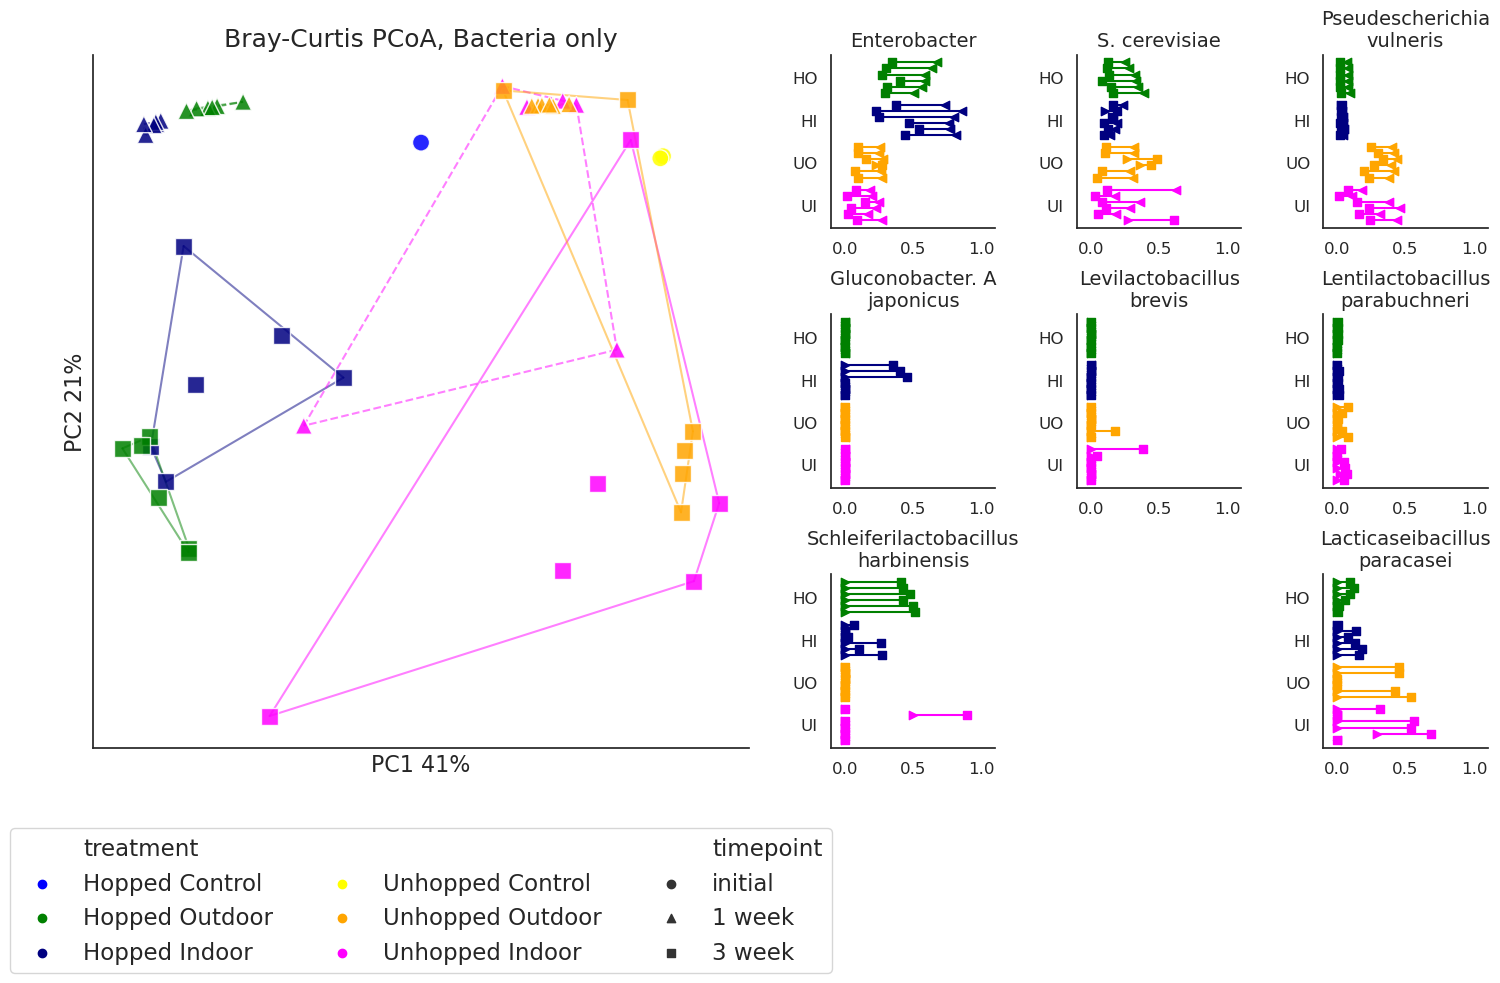

In [115]:
fig = plt.figure(figsize=(18,9))
gs = fig.add_gridspec(3, 6,)
ax = fig.add_subplot(gs[:3, :3])
x, y = 'PC1', 'PC2'
# scatter underlying data 
sns.scatterplot(data=braycurtis_community_plotdf, x=x, y=y, hue='treatment', ax=ax, style='timepoint',
            linewidth=1, alpha=0.85, s=150, 
            hue_order=['HC', 'HO', 'HI', 'UC', 'UO', 'UI'], 
            palette=['blue', 'green', 'navy', 'yellow', 'orange', 'magenta'],
            markers=['o', '^', 's'])

print('making hulls')
handles, labels = ax.get_legend_handles_labels()
blank_handle = Rectangle((0,0), 1, 1, fill=False, edgecolor='none',visible=False)
# manually formatting legend
labels = ['treatment', 
          'Hopped Control', 
          'Hopped Outdoor', 
          'Hopped Indoor', 
          '', 
          'Unhopped Control', 
          'Unhopped Outdoor', 
          'Unhopped Indoor', 
          'timepoint', 
          'initial', 
          '1 week', 
          '3 week']
handles = handles[0:4] + [blank_handle] + handles[4:]
lgd = ax.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncols=3)

# Plotting PERMANOVA hulls
# --------------------------------------------------------------------------------
condition_colors = ['navy', 'navy', 'green', 'green',  'magenta', 'magenta', 'orange', 'orange']
test_condition = 'Hops + Location + timepoint'
# ax = fig.add_subplot(gs[pm1, pm2])
conditions = test_condition.split(' + ')

# make a subset df to safely add columns
pm_plotdf = braycurtis_community_plotdf.copy(deep=True)
# make a condition column with the combined condition columns
pm_plotdf['condition'] = pm_plotdf[conditions].apply(lambda row: ' '.join([row[c] for c in conditions]), axis=1)
# get unique values: 1 simplex / permanova per unique value
unique_combos = pm_plotdf[~pm_plotdf['timepoint'].eq('initial')]['condition'].unique()

# maybe need to map to ints?
condition_map = dict((unique_combos[i], i) for i in range(len(unique_combos)))

for uc, uc_c in zip(unique_combos, condition_colors):
    print(uc)
    if '1 week' in uc:
        linestyle = '--'
    else:
        linestyle = '-'
    # get points relevant to group
    subset = pm_plotdf[pm_plotdf['condition'].eq(uc)]
    points = subset[['PC1', 'PC2']].values
    hull = ConvexHull(points)

    # plot hulls
    for simplex in hull.simplices:
        plt.plot(points[simplex, 0], points[simplex, 1], ls=linestyle, color=uc_c, zorder=0, alpha=0.5)

# do PERMANOVA
# --------------------------------------------------------------------------------          
# do permanova
# permanova_samples = pm_plotdf[~pm_plotdf['timepoint'].eq('initial')]['Sample ID'].unique()
# # get grouping from condition
# grouping = pm_plotdf.set_index('Sample ID').loc[permanova_samples, 'condition'].values
# # make distance matrix
# dm = DistanceMatrix(braycurtis_community_dists.loc[permanova_samples, permanova_samples].values)
# dm.ids = permanova_samples
# # perform test
# permanova_result = permanova(dm, grouping = grouping)
# pval = permanova_result['p-value']

plt.tick_params(labelleft=False, labelbottom=False, bottom=False, left=False)
ax.set_title('Bray-Curtis PCoA, Bacteria only')
# ax.set_title(f'{", ".join(conditions)}\np-value={pval}', fontsize=20)
# ax.set_ylabel(' ')
# ax.set_xlabel(' ')
ax.set_ylabel(f'{y} {braycurtis_community_pcoa.proportion_explained.loc[y]*100:.0f}%', fontsize=16)
ax.set_xlabel(f'{x} {braycurtis_community_pcoa.proportion_explained.loc[x]*100:.0f}%', fontsize=16)

# ax = fig.add_subplot(gs[1, 0])
# for s in mag_order:
#     sns.lineplot(y=plotdf[plotdf['species'].eq(s)].set_index('Sample ID')['rpkm'], x=braycurtis_community_plotdf.set_index('Sample ID')['PC1'], 
#                 color=species_color_map[s])

species = ['g__Enterobacter', 'S_cerevisiae',
's__Pseudescherichia vulneris',
's__Gluconobacter_A japonicus',

's__Levilactobacillus brevis',
's__Lentilactobacillus parabuchneri',
's__Schleiferilactobacillus harbinensis',
'blank',
's__Lacticaseibacillus paracasei']
i = 1
for s, index in zip(species, [(0,3), (0,4), (0,5), (1,3), (1,4), (1,5), (2,3), (2,4), (2,5)]):
    print(s)
    ax = fig.add_subplot(gs[index[0], index[1]])
    if s == 'blank':
        ax.axis('off')
        
    else:
        
        subset = plotdf[plotdf['species'].eq(s) & ~plotdf['timepoint'].eq('initial')].copy(deep=True)
        subset['replicate'] = subset['sample_name'].apply(lambda x: x.split('-')[0])
        lineplot = subset.pivot_table(index='replicate', columns='timepoint', values='rpkm')
        
        groups = ['HO', 'HI', 'UO', 'UI']
        colors = ['green', 'navy', 'orange', 'magenta'][::-1]
        
        for index, row in lineplot.iterrows():
            
            y_ind = groups[::-1].index(index[:2])
            shift = (1/7) * int(index[-1]) + 0.5
            y_ind_s = y_ind + shift
            
            week1 = row['1 week'] / total_rpkm.loc[(index, '1 week')]
            week3 = row['3 week'] / total_rpkm.loc[(index, '3 week')]
            
            plt.plot((week1, week3), (y_ind_s, y_ind_s), color=colors[y_ind])
            marker = '>'
            if week1 > week3:
                marker = '<'
            
            plt.scatter(x=(week1,), y=(y_ind_s,), color=colors[y_ind], marker=marker)
            plt.scatter(x=(week3,), y=(y_ind_s,), color=colors[y_ind], marker='s')
        
        ax.set_yticks(range(1,5))
        ax.set_yticklabels(groups[::-1])
        
        

#         sns.swarmplot(data=subset,
#                       x='treatment', y='rpkm', hue='timepoint', dodge=True, 
#                       palette=['green', 'navy', 'yellow', 'orange', 'magenta'],
#                       alpha=0.65
#                      )

#         sns.boxplot(data=subset,
#                       x='treatment', y='rpkm', hue='timepoint', dodge=True,
#                       color='white')

        ax.set_xlim(-0.1, 1.1)
        ax.set_xticks([0, 0.5, 1])
        plt.tick_params(labelsize=12)
        ax.set_xlabel(' ')
        ax.set_title(s.split('__')[-1].replace(' ', '\n').replace('_', '. '), fontsize=14)
        sns.despine()
    

    i += 1
# lgd2 = ax.legend(loc='upper right', bbox_to_anchor=(1.1, -0.25), ncols=6)  
fig.subplots_adjust(wspace=0.5, hspace=0.5)
plt.savefig('/data/mhoffert/fiererlab/beer/data/figures/figure2.svg', bbox_inches='tight', dpi=300)

In [284]:
# do PERMANOVA
# --------------------------------------------------------------------------------          
# do permanova
permanova_samples = pm_plotdf[~pm_plotdf['timepoint'].eq('initial')]['Sample ID'].unique()
# get grouping from condition
grouping = pm_plotdf.set_index('Sample ID').loc[permanova_samples, 'condition'].values
# make distance matrix
dm = DistanceMatrix(braycurtis_community_dists.loc[permanova_samples, permanova_samples].values)
dm.ids = permanova_samples
# perform test
permanova_result = permanova(dm, grouping = grouping)
pval = permanova_result['p-value']

In [288]:
permanova_result

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      48
number of groups                  8
test statistic            13.314073
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object

In [290]:
pseudo_f = permanova_result['test statistic']
n = len(permanova_samples)
k = len(set(grouping))
print('r squared', (pseudo_f * (k - 1)) / (pseudo_f * (k - 1) + (n - k)))

r square 0.6996963449273286


In [286]:
grouping

array(['H I 1 week', 'H I 3 week', 'H I 1 week', 'H I 3 week',
       'H I 1 week', 'H I 3 week', 'H I 1 week', 'H I 3 week',
       'H I 1 week', 'H I 3 week', 'H I 1 week', 'H I 3 week',
       'H O 1 week', 'H O 3 week', 'H O 1 week', 'H O 3 week',
       'H O 1 week', 'H O 3 week', 'H O 1 week', 'H O 3 week',
       'H O 1 week', 'H O 3 week', 'H O 1 week', 'H O 3 week',
       'U I 1 week', 'U I 3 week', 'U I 1 week', 'U I 3 week',
       'U I 1 week', 'U I 3 week', 'U I 1 week', 'U I 3 week',
       'U I 1 week', 'U I 3 week', 'U I 1 week', 'U I 3 week',
       'U O 1 week', 'U O 3 week', 'U O 1 week', 'U O 3 week',
       'U O 1 week', 'U O 3 week', 'U O 1 week', 'U O 3 week',
       'U O 1 week', 'U O 3 week', 'U O 1 week', 'U O 3 week'],
      dtype=object)

### Panel A only

In [136]:
plotdf.columns

Index(['sample_name', 'species', 'rpkm', 'Unnamed: 0', 'Sample Description',
       'Sample Name', 'Sample ID', 'timepoint', 'Filter replicate', 'pH',
       'Density', 'Scent notes', 'Notes', 'Hops', 'Location', 'treatment',
       'Fructose', 'Glucose', 'Sucrose', 'Maltose', 'Maltotriose', 'Method',
       'Density Temperature', 'Alcohol (% v/v)', 'Alcohol (% w/w)',
       'Specific Gravity', 'Ea (app. extract) (% w/w)',
       'Er (real extract) (% w/w)', 'p (original extract) (% w/w)',
       'Concentration Sugar', 'RDF (real deg. of ferm.)', 'ADF (% w/w)',
       'Calories (kcal/12oz)', 'replicate'],
      dtype='object')

In [141]:
plotdf['treatment'].unique()

array(['HC', 'HI', 'HO', 'UC', 'UI', 'UO'], dtype=object)

H I 1 week
H I 3 week
H O 1 week
H O 3 week
U I 1 week
U I 3 week
U O 1 week
U O 3 week


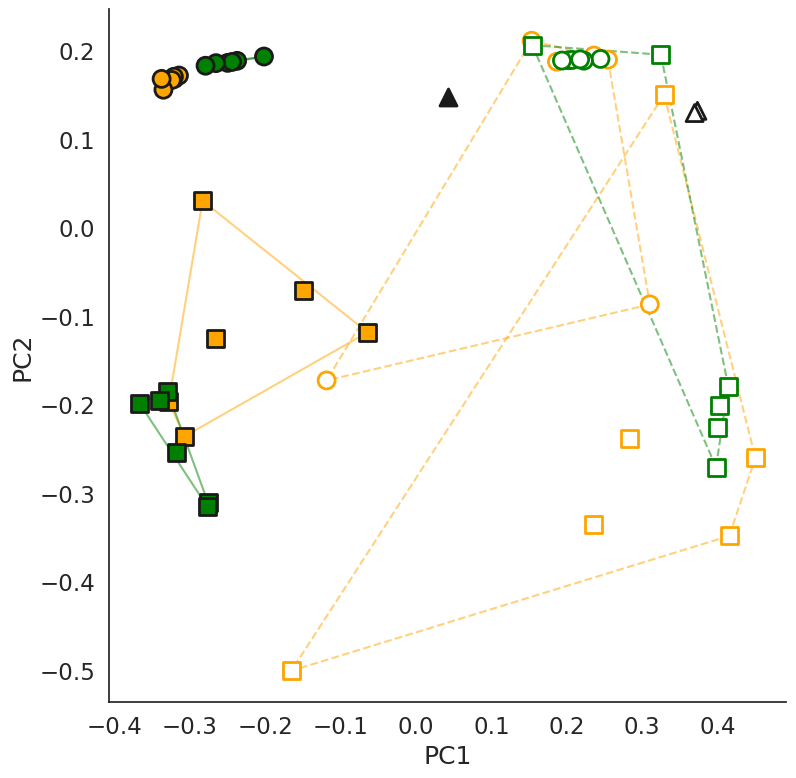

In [174]:
fig = plt.figure(figsize=(18,9))
gs = fig.add_gridspec(3, 6,)
ax = fig.add_subplot(gs[:3, :3])
sns.despine()
x, y = 'PC1', 'PC2'
# scatter underlying data 
treatments = ['HC', 'HI', 'HO', 'UC', 'UI', 'UO']
markers = [['^'], ['o', 's'], ['o', 's'], ['^'],['o', 's'], ['o', 's']]
colors = ['k', 'orange', 'green', 'white', 'white', 'white']
edgecolors = ['k', 'k', 'k', 'k', 'orange', 'green']
for i, treatment in enumerate(treatments):
    sns.scatterplot(data=braycurtis_community_plotdf.mask(~braycurtis_community_plotdf['treatment'].eq(treatment)), 
                    ax=ax, style='timepoint', markers=markers[i], color=colors[i],
                    x=x, y=y, legend=False, s=150, linewidth=2, edgecolor=edgecolors[i],
                   alpha=1)

# Plotting PERMANOVA hulls
# --------------------------------------------------------------------------------
condition_colors = ['orange', 'orange', 'green', 'green',  'orange', 'orange', 'green', 'green']
test_condition = 'Hops + Location + timepoint'
conditions = test_condition.split(' + ')

# make a subset df to safely add columns
pm_plotdf = braycurtis_community_plotdf.copy(deep=True)
# make a condition column with the combined condition columns
pm_plotdf['condition'] = pm_plotdf[conditions].apply(lambda row: ' '.join([row[c] for c in conditions]), axis=1)
# get unique values: 1 simplex / permanova per unique value
unique_combos = pm_plotdf[~pm_plotdf['timepoint'].eq('initial')]['condition'].unique()

# maybe need to map to ints?
condition_map = dict((unique_combos[i], i) for i in range(len(unique_combos)))

for uc, uc_c in zip(unique_combos, condition_colors):
    print(uc)
    if 'U' in uc:
        linestyle = '--'
    else:
        linestyle = '-'
    # get points relevant to group
    subset = pm_plotdf[pm_plotdf['condition'].eq(uc)]
    points = subset[['PC1', 'PC2']].values
    hull = ConvexHull(points)

    # plot hulls
    for simplex in hull.simplices:
        plt.plot(points[simplex, 0], points[simplex, 1], ls=linestyle, color=uc_c, zorder=0, alpha=0.5)
        
plt.savefig('./../data/figures/PCoA_plot.svg', bbox_inches='tight')

In [91]:
pm_plotdf.columns

Index(['PC1', 'PC2', 'Unnamed: 0', 'Sample Description', 'Sample Name',
       'Sample ID', 'timepoint', 'Filter replicate', 'pH', 'Density',
       'Scent notes', 'Notes', 'Hops', 'Location', 'treatment', 'Fructose',
       'Glucose', 'Sucrose', 'Maltose', 'Maltotriose', 'Method',
       'Density Temperature', 'Alcohol (% v/v)', 'Alcohol (% w/w)',
       'Specific Gravity', 'Ea (app. extract) (% w/w)',
       'Er (real extract) (% w/w)', 'p (original extract) (% w/w)',
       'Concentration Sugar', 'RDF (real deg. of ferm.)', 'ADF (% w/w)',
       'Calories (kcal/12oz)', 'condition'],
      dtype='object')

In [89]:
unique_combos

array(['H 1 week', 'H 3 week', 'U 1 week', 'U 3 week'], dtype=object)

In [78]:
mag2species

user_genome
HI4-3_MAG_04              s__Gluconobacter_A japonicus
HO2-3_MAG_03           s__Lacticaseibacillus paracasei
HO2-3_MAG_04    s__Schleiferilactobacillus harbinensis
UO2-1_MAG_03                    s__Pantoea agglomerans
UO2-3_MAG_03               s__Levilactobacillus brevis
UO5-1_MAG_01              s__Pseudescherichia vulneris
UO5-1_MAG_02                                       s__
UO6-3_MAG_03        s__Lentilactobacillus parabuchneri
Name: classification, dtype: object

In [80]:
pd.read_csv('/data/mhoffert/tools/gapseq/dat/meta_rea_pwy-gapseq.tbl', sep='\t')

,rxn,name,ec,pathway,pathway.name,subsystem,gapseq
0,DHLAXANAU-RXN,"1,2-dichloroethane dehalogenase",3.8.1.5,|12DICHLORETHDEG-PWY|,"1,2-dichloroethane degradation","Degradation,CHLORINATED-COMPOUNDS-DEG",rxn03596 rxn03668 rxn03669 rxn03670 rxn03671 r...
1,MOXXANAU-RXN,2-chloroethanol dehydrogenase,1.1.2.7,|12DICHLORETHDEG-PWY|,"1,2-dichloroethane degradation","Degradation,CHLORINATED-COMPOUNDS-DEG",rxn00847 rxn01796 rxn12745 rxn14207 rxn15989 r...
2,ALDXANAU-RXN,chloroacetaldehyde dehydrogenase,1.2.1.4,|12DICHLORETHDEG-PWY|,"1,2-dichloroethane degradation","Degradation,CHLORINATED-COMPOUNDS-DEG",rxn00507 rxn03455 rxn05880 rxn14071 rxn19116
3,DHLBXANAU-RXN,chloroacetate dehalogenase,3.8.1.3,|12DICHLORETHDEG-PWY|,"1,2-dichloroethane degradation","Degradation,CHLORINATED-COMPOUNDS-DEG",rxn02050 rxn03599 rxn06154 rxn19881
4,DIOXYXANFL-RXN,"1,4-dichlorobenzene dioxygenase",1.14.12.26,|14DICHLORBENZDEG-PWY|,"1,4-dichlorobenzene degradation","CHLORINATED-COMPOUNDS-DEG,Degradation,AROMATIC...",NaN
...,...,...,...,...,...,...,...
14469,ASPARTATE-SEMIALDEHYDE-DEHYDROGENASE-RXN,aspartate-semialdehyde dehydrogenase,1.2.1.11,THRBIOSYN-GS,Threonine biosynthis from aspartate via homose...,"Biosynthesis,Amino-Acid-Biosynthesis,IND-AMINO...",rxn01643 rxn33374 rxn33956
14470,HOMOSERDEHYDROG-RXN,homoserine dehydrogenase,1.1.1.3,THRBIOSYN-GS,Threonine biosynthis from aspartate via homose...,"Biosynthesis,Amino-Acid-Biosynthesis,IND-AMINO...",rxn01301 rxn01302 rxn19904 rxn33957
14471,NAD-KIN-RXN,NAD kinase,2.7.1.23,|NADPHOS-DEPHOS-PWY|,NAD phosphorylation and dephosphorylation,"Enzyme-Cofactor-Biosynthesis,Biosynthesis,Cofa...",rxn00077 rxn10056 rxn10057 rxn10058 rxn10059 r...
14472,TRANS-RXN0-277,pyridine nucleotide transhydrogenase,7.1.1.1/1.6.1.5,|NADPHOS-DEPHOS-PWY|,NAD phosphorylation and dephosphorylation,"Enzyme-Cofactor-Biosynthesis,Biosynthesis,Cofa...",rxn09295 rxn10125 rxn27378


In [81]:
pd.read_csv('/data/mhoffert/tools/gapseq/dat/kegg_pwy.tbl', sep='\t')

,id,name,altname,hierarchy,taxrange,reaId,reaEc,keyRea,reaName,reaNr,ecNr,superpathway,status
0,map00010,Glycolysis / Gluconeogenesis,NaN,kegg;Metabolism;Carbohydrate metabolism,NaN,"R07105,R01481,R01000,R01146,R05062,R09479,R010...","1.1.1.1,1.1.1.2,1.1.1.27,1.1.2.7,1.1.2.8,1.1.5...",NaN,trichloroethanol:NAD+ oxidoreductase;L-gulonat...,51,51,False,True
1,map00020,Citrate cycle (TCA cycle),NaN,kegg;Metabolism;Carbohydrate metabolism,NaN,"R01936,R07136,R00709,R00267,R01257,R00014,R006...","1.1.1.286,1.1.1.37,1.1.1.41,1.1.1.42,1.1.5.4,1...",NaN,"(1R,2S)-1-hydroxybutane-1,2,4-tricarboxylate:N...",26,26,False,True
2,map00030,Pentose phosphate pathway,NaN,kegg;Metabolism;Carbohydrate metabolism,NaN,"R08879,R10221,R01096,R07147,R00835,R10520,R020...","1.1.1.215,1.1.1.343,1.1.1.359,1.1.1.360,1.1.1....",NaN,5-dehydro-D-gluconate:NADP+ 2-oxidoreductase;6...,59,59,False,True
3,map00040,Pentose and glucuronate interconversions,NaN,kegg;Metabolism;Carbohydrate metabolism,NaN,"R01904,R00868,R01903,R01542,R02441,R02637,R015...","1.1.1.10,1.1.1.11,1.1.1.12,1.1.1.127,1.1.1.13,...",NaN,Xylitol:NADP+ 4-oxidoreductase (L-xylulose-for...,70,70,False,True
4,map00051,Fructose and mannose metabolism,NaN,kegg;Metabolism;Carbohydrate metabolism,NaN,"R00868,R07675,R00880,R03396,R00870,R00875,R056...","1.1.1.11,1.1.1.122,1.1.1.132,1.1.1.135,1.1.1.1...",NaN,D-Mannitol:NAD+ 2-oxidoreductase;L-galactose:N...,77,77,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
518,map07231,Sodium channel blocking drugs,NaN,kegg;Drug Development;Target-based classificat...,NaN,NaN,NaN,NaN,NaN,0,0,False,True
519,map07232,Potassium channel blocking and opening drugs,NaN,kegg;Drug Development;Target-based classificat...,NaN,NaN,NaN,NaN,NaN,0,0,False,True
520,map07233,Ion transporter inhibitors,NaN,kegg;Drug Development;Target-based classificat...,NaN,NaN,NaN,NaN,NaN,0,0,False,True
521,map07234,Neurotransmitter transporter inhibitors,NaN,kegg;Drug Development;Target-based classificat...,NaN,NaN,NaN,NaN,NaN,0,0,False,True


In [76]:
print(s)

s__Lacticaseibacillus paracasei


## Figure 3: dispersion

In [176]:
dispersions = pd.DataFrame(dtype='float', index=['HO', 'HI', 'UO', 'UI'], columns=['mean', 'sem'])
temp_dfs = []
for treatment in ['HO', 'HI', 'UO', 'UI']:
    samples = plotdf[plotdf['timepoint'].eq('3 week') & plotdf['treatment'].eq(treatment)]['Sample ID'].unique()
   
    sample_dists = braycurtis_community_dists.loc[samples, samples]
    temp_dfs.append(sample_dists)
    mask = np.ones(sample_dists.shape, dtype='bool')
    mask[np.triu_indices(len(sample_dists), k=1)] = False
    values = [s for s in sample_dists.mask(mask).values.flatten() if not np.isnan(s)]
    dispersions.loc[treatment, 'mean'] = np.mean(values)
    dispersions.loc[treatment, 'sem'] = sem(values)

In [177]:
dispersions

,mean,sem
HO,0.092936,0.008977
HI,0.380167,0.051092
UO,0.350598,0.056325
UI,0.624175,0.075478


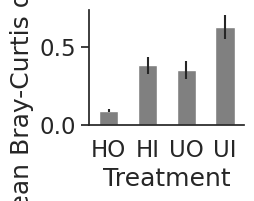

In [184]:
fig, ax = plt.subplots(figsize=(2, 1.5))
dispersions.reset_index().plot(x='index', y='mean', yerr='sem', color='gray', kind='bar', legend=False, ax=ax)
# ax.set_ylim(-0.1, 0.75)
ax.set_ylabel('mean Bray-Curtis distance')
ax.set_xlabel('Treatment')
plt.tick_params(rotation=0, axis='x')
ax.tick_params(left=True)
sns.despine()
# ax.set_title('Week 3 dispersion')
plt.savefig('/data/mhoffert/fiererlab/beer/data/figures/dispersions.svg',  bbox_inches='tight')

## Figure 4: Comparing hops-specific Lactobacilli

In [43]:
# get interproscan name mapping to GO terms
interpro_go_data = pd.read_csv('/data/mhoffert/db/GO/interpro2go', sep=';', skiprows=6, header=None, names=['interpro_data', 'go'])
interpro_go_data['interpro_id'] = interpro_go_data['interpro_data'].apply(lambda x: x.split(':')[1].split(' ')[0])
interpro_go_data['go_annot'] = interpro_go_data['interpro_data'].apply(lambda x: x.split(' > GO:')[-1].rstrip())
interpro2go = interpro_go_data.set_index('interpro_id')['go']
interpro2go.head()

# # making functional table
interpro_columns = ['protein_accession', 'sequence_md5', 'sequence_length', 'analysis', 
                    'signature_accession', 'signature_description', 'start_location',
                    'stop_location', 'score', 'status', 'date', 'interpro_accession',
                    'interpro_annotations']

interpro_tables = glob.glob('/data/mhoffert/fiererlab/beer/mag_pipeline/derep_mags/*interpro.tsv')
tables = pd.concat([pd.read_csv(i, sep='\t', header=None, names=interpro_columns).assign(mag=mag2species.loc[i.split('/')[-1].split('_interpro')[0]]) for i in interpro_tables])

tables = tables[~tables.interpro_accession.eq('-')]
tables = pd.merge(tables, interpro2go, left_on='interpro_accession', right_index=True, how='left')
tables['present'] = True

In [44]:
tables['go'] = tables['go'].fillna('None').apply(lambda x: x.lstrip(' '))

In [45]:
md['sample_no_time'] = md[~md.timepoint.eq('initial')]['Sample ID'].apply(lambda x: x.split('-')[0])
delta_ph = md.pivot_table(index='sample_no_time', columns='timepoint', values='pH')
delta_ph = delta_ph['3 week'] - delta_ph['1 week']

In [46]:
plotdf['sample_no_time'] = plotdf[~plotdf.timepoint.eq('initial')]['Sample ID'].apply(lambda x: x.split('-')[0])
delta_rpkm = plotdf.pivot_table(index=['sample_no_time', 'species'], columns='timepoint', values='rpkm')
delta_rpkm = delta_rpkm['3 week'] - delta_rpkm['1 week']

In [47]:
sns.set(font_scale=1)
sns.set_style('white')


In [48]:
pathway_data = glob.glob('/data/mhoffert/fiererlab/beer/mag_pipeline/derep_mags/gapseq_test/*Pathways.tbl')

In [49]:
all_pathway_data = pd.concat([pd.read_csv(p, sep='\t', skiprows=3).assign(mag_id=p.split('/')[-1].split('_protein')[0]) for p in pathway_data])

In [50]:
pathway_heatmap_data = all_pathway_data.pivot_table(index='Name', columns='mag_id', values='Completeness').fillna(0).rename(columns=mag2species)

In [51]:
horA_hits = pd.read_csv('/data/mhoffert/fiererlab/beer/Group1/2022-11-30_functional_table.csv', index_col=0)
horA_hits = pd.merge(md, horA_hits.T, left_on='Sample ID', right_index=True) 


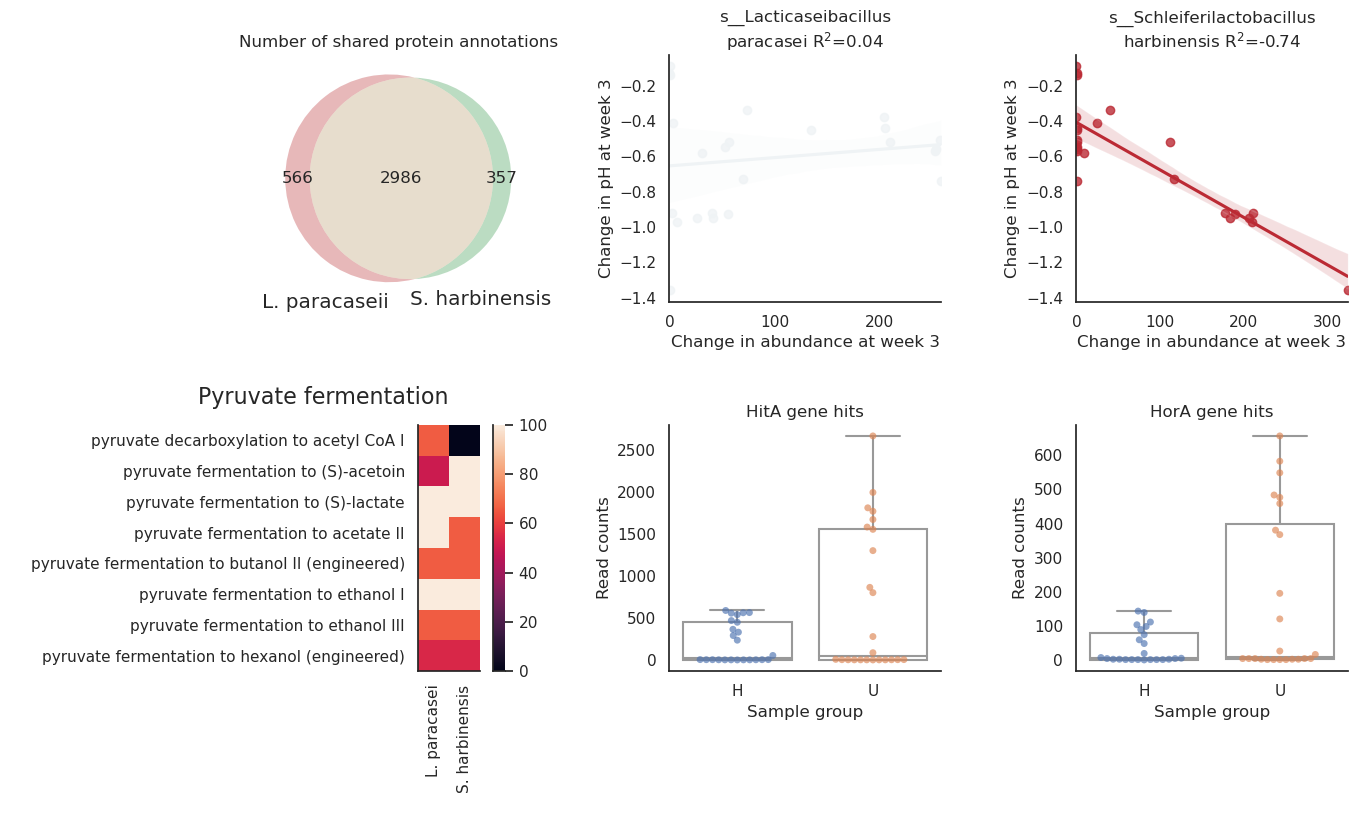

In [52]:
fig = plt.figure(figsize=(14,8))

# first subplots
ax = fig.add_subplot(2, 3, 1)
lacto_go_table = tables[tables['mag'].isin(['s__Lacticaseibacillus paracasei','s__Schleiferilactobacillus harbinensis'])].pivot_table(index='mag', columns='interpro_accession', values='present').fillna(0)
para_set = set(lacto_go_table.columns[lacto_go_table.iloc[0, :].values == 1])
harb_set = set(lacto_go_table.columns[lacto_go_table.iloc[1, :].values == 1])
venn2([para_set, harb_set], set_labels=['L. paracaseii', 'S. harbinensis'], ax=ax)
ax.set_title('Number of shared protein annotations')
# plt.savefig('/data/mhoffert/fiererlab/beer/figures/proteins_shared.png', dpi=300, bbox_inches='tight')

# second subplot
idx = pd.IndexSlice
# fig = plt.figure(figsize=(8, 8))

# colors = ['navy', 'green', 'magenta', 'orange']
jet = cm = plt.get_cmap('RdBu') 
cNorm  = colors.Normalize(vmin=-1, vmax=1)
scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=jet)

scatter_kws = {'linewidth':0}

i = 2
for species in ['s__Lacticaseibacillus paracasei','s__Schleiferilactobacillus harbinensis']:
    ax = fig.add_subplot(2,3,i)
    r_val = spearmanr(delta_rpkm.loc[idx[delta_ph.index, species]], delta_ph)[0]
    
    sns.regplot(x=delta_rpkm.loc[idx[:, species]], y=delta_ph, color=scalarMap.to_rgba(r_val))

    newtitle = species.replace(' ', '\n')
    ax.set_title(newtitle + f' R$^2$={r_val:.2f}')
    ax.set_xlabel('Change in abundance at week 3')
    ax.set_ylabel('Change in pH at week 3')

    sns.despine()
    i += 1
    
pyruvate_pathways = [s for s in pathway_heatmap_data.index if 'pyruvate' in s]
pyruvate_data = pathway_heatmap_data.loc[pyruvate_pathways, ['s__Lacticaseibacillus paracasei','s__Schleiferilactobacillus harbinensis']].T
pyruvate_data = pyruvate_data.loc[:, (pyruvate_data > 50).sum() >= 1]
ax = fig.add_subplot(2,3,4)
sns.heatmap(pyruvate_data.T, square=True, ax=ax)
ax.set_ylabel(' ')
ax.set_xlabel(' ')
ax.set_xticklabels([l.get_text().split(' ')[0][3].upper() + '. ' + l.get_text().split(' ')[-1] for l in ax.get_xticklabels()])
ax.set_title('Pyruvate fermentation', y=1.05, fontsize=16, ha='right')

# # transport mechanisms
# multidrug = tables['interpro_annotations'][tables.interpro_annotations.apply(lambda x: x.lower()).str.contains('efflux')].unique()
# multidrug_heatmap = tables[tables['interpro_annotations'].isin(multidrug)].pivot_table(index='mag', columns='interpro_annotations', values='present').fillna(0)
# ax = fig.add_subplot(2,3,5)
# sns.heatmap(multidrug_heatmap.T, square=True, ax=ax)
# ax.set_ylabel(' ')
# ax.set_xlabel(' ')
# ax.set_xticklabels([l.get_text().split(' ')[0][3].upper() + '. ' + l.get_text().split(' ')[-1] for l in ax.get_xticklabels()])
# ax.set_yticklabels([' ' for l in ax.get_yticklabels()])

# ax.set_title('Multidrug resistance proteins', y=1.05, fontsize=16, ha='right')
ax = fig.add_subplot(2,3,5)
sns.swarmplot(data=horA_hits, y='HitA', x='Hops', alpha=0.65)
sns.boxplot(data=horA_hits, y='HitA', x='Hops', color='white')
ax.set_ylabel('Read counts')
ax.set_xlabel('Sample group')
ax.set_title('HitA gene hits')
sns.despine()

ax = fig.add_subplot(2,3,6)
sns.swarmplot(data=horA_hits, y='HorA', x='Hops', alpha=0.65)
sns.boxplot(data=horA_hits, y='HorA', x='Hops', color='white')
ax.set_ylabel('Read counts')
ax.set_xlabel('Sample group')
ax.set_title('HorA gene hits')
sns.despine()

fig.subplots_adjust(hspace=0.5, wspace=0.5)
plt.savefig('/data/mhoffert/fiererlab/beer/figures/figure4.png', dpi=300, bbox_inches='tight')

In [54]:
with open('/data/mhoffert/db/GO/go.obo', 'r') as handle:
    lines = handle.read()

In [55]:
go2parent = pd.Series(dtype='str')
terms = lines.split('[Term]')
for t in terms[1:5]:
    # print(t)
    go_id = t.split('id: ')[-1].split('\n')[0]
    parents = t.split('is_a')
    if not len(parents) == 1:
        for p in parents[1:]:
            go2parent.loc[go_id] = p.split(' ')[1]

In [56]:
interpro_go_map = tables.groupby('interpro_annotations').first()['go']

In [57]:
with open('/data/mhoffert/db/InterPro/ParentChildTreeFile.txt', 'r') as handle:
    lines = handle.read()

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.


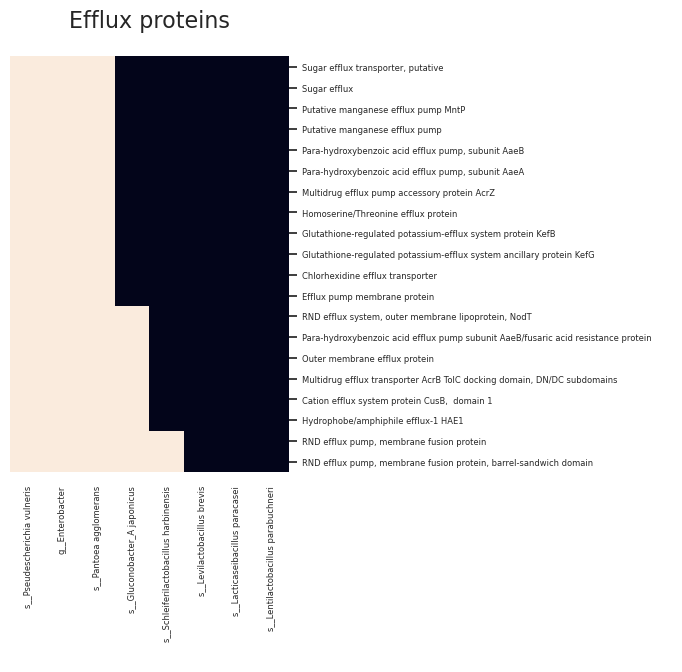

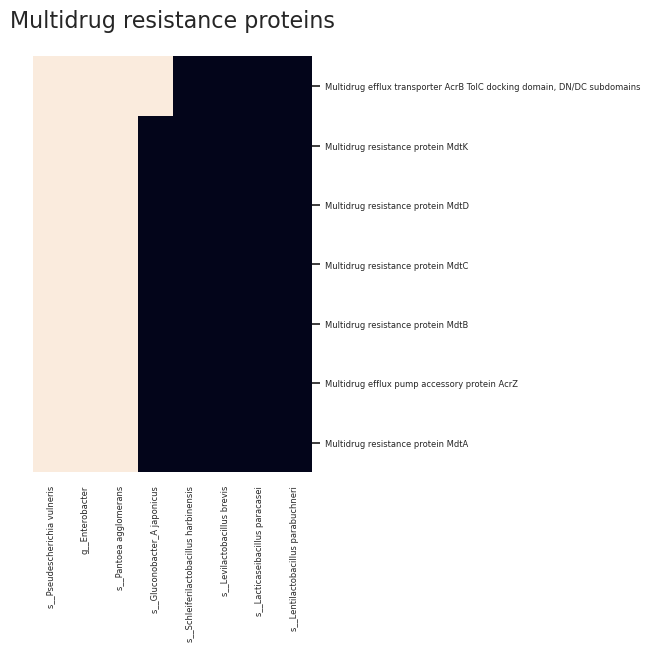

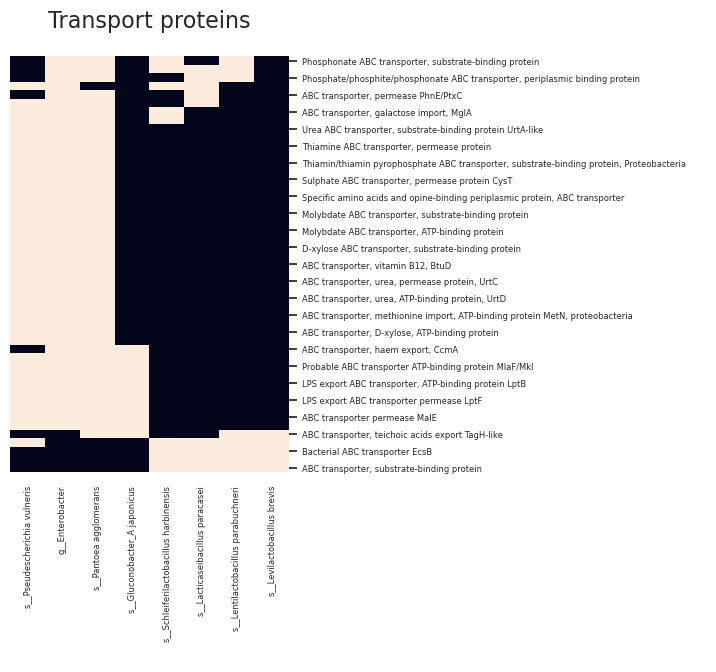

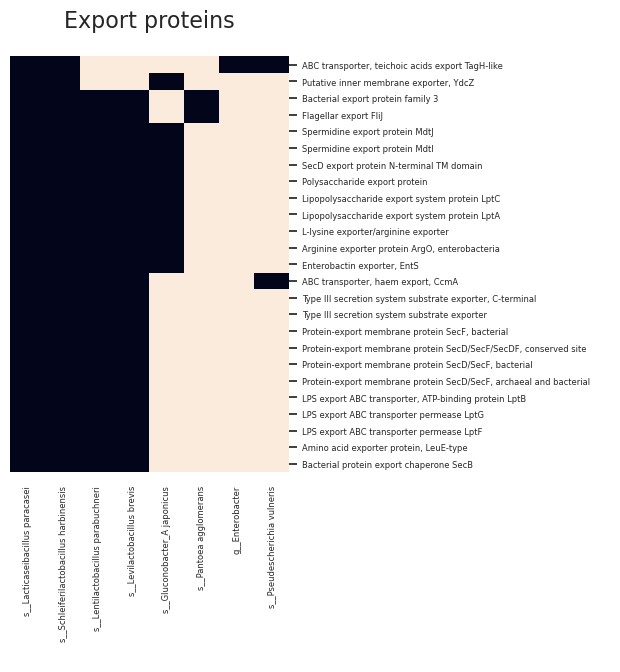

In [58]:
# fig, ax = plt.subplots(figsize=(12,4))
lactos = ['s__Lacticaseibacillus paracasei','s__Schleiferilactobacillus harbinensis']
# transport mechanisms
efflux = list(tables['interpro_annotations'][tables.interpro_annotations.apply(lambda x: x.lower()).str.contains('efflux')].unique())
multidrug = list(tables['interpro_annotations'][tables.interpro_annotations.apply(lambda x: x.lower()).str.contains('multidrug')].unique())
transporters = list(tables['interpro_annotations'][tables.interpro_annotations.apply(lambda x: x.lower()).str.contains('abc transporter')].unique())
exporters = list(tables['interpro_annotations'][tables.interpro_annotations.apply(lambda x: x.lower()).str.contains('export')].unique())

all_drugs = list(set(efflux + multidrug + transporters + exporters))
# gos = interpro_go_map.loc[all_drugs].unique()
# go_colors = dict((go, c) for c, go in zip(sns.color_palette('tab20', len(gos)), gos))
# row_colors = pd.Series(index=all_drugs, data=[go_colors[interpro_go_map.loc[a]] for a in all_drugs])
sf_index = 2
for all_drugs, ax_label in zip([efflux, multidrug, transporters, exporters], 
                     ['Efflux proteins', 'Multidrug resistance proteins', 'Transport proteins', 'Export proteins']):
    multidrug_heatmap = tables[tables['interpro_annotations'].isin(all_drugs)].pivot_table(index='mag', columns='interpro_annotations', values='present').fillna(0)
    # ax = fig.add_subplot(2,3,5)
    multidrug_heatmap = multidrug_heatmap.loc[:, ((multidrug_heatmap == 1).sum() >= 3) &  ((multidrug_heatmap == 1).sum() < 6)]
    g = sns.clustermap(multidrug_heatmap.T, row_cluster=True, figsize=(4, 6), dendrogram_ratio=0.01)
    g.ax_cbar.remove()
    g.ax_col_dendrogram.remove()
    g.ax_row_dendrogram.remove()
    g.ax_heatmap.set_ylabel(' ')
    g.ax_heatmap.set_xlabel(' ')
    # ax.set_xticklabels([l.get_text().split(' ')[0][3].upper() + '. ' + l.get_text().split(' ')[-1] for l in ax.get_xticklabels()])
    # ax.set_yticklabels([' ' for l in ax.get_yticklabels()])
    plt.tick_params(labelsize=6)
    g.ax_heatmap.set_title(ax_label, y=1.05, fontsize=16)
    sf_index += 1
    plt.savefig(f'/data/mhoffert/fiererlab/beer/figures/SF{sf_index}.png', dpi=300)

In [65]:
tables[tables.interpro_annotations.apply(lambda x: x.lower()).str.contains('rnd efflux')]

,protein_accession,sequence_md5,sequence_length,analysis,signature_accession,signature_description,start_location,stop_location,score,status,date,interpro_accession,interpro_annotations,mag,go,present
271,NODE_4_length_450692_cov_331.774510_187,6ee0a2c1cbd86985ad45af1802c0967a,316,TIGRFAM,TIGR01730,"RND_mfp: efflux transporter, RND family, MFP s...",45,289,7.9E-30,T,26-05-2023,IPR006143,"RND efflux pump, membrane fusion protein",s__Gluconobacter_A japonicus,GO:0022857,True
271,NODE_4_length_450692_cov_331.774510_187,6ee0a2c1cbd86985ad45af1802c0967a,316,TIGRFAM,TIGR01730,"RND_mfp: efflux transporter, RND family, MFP s...",45,289,7.9E-30,T,26-05-2023,IPR006143,"RND efflux pump, membrane fusion protein",s__Gluconobacter_A japonicus,GO:0055085,True
271,NODE_4_length_450692_cov_331.774510_187,6ee0a2c1cbd86985ad45af1802c0967a,316,TIGRFAM,TIGR01730,"RND_mfp: efflux transporter, RND family, MFP s...",45,289,7.9E-30,T,26-05-2023,IPR006143,"RND efflux pump, membrane fusion protein",s__Gluconobacter_A japonicus,GO:0016020,True
2960,NODE_10_length_294944_cov_287.652690_128,9a11d437e50c46283073d71091c453c3,444,Pfam,PF16576,Barrel-sandwich domain of CusB or HlyD membran...,95,316,1.3E-12,T,26-05-2023,IPR032317,"RND efflux pump, membrane fusion protein, barr...",s__Gluconobacter_A japonicus,None,True
2963,NODE_10_length_294944_cov_287.652690_128,9a11d437e50c46283073d71091c453c3,444,TIGRFAM,TIGR01730,"RND_mfp: efflux transporter, RND family, MFP s...",69,397,7.3E-76,T,26-05-2023,IPR006143,"RND efflux pump, membrane fusion protein",s__Gluconobacter_A japonicus,GO:0022857,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33804,NODE_9_length_376452_cov_152.028451_309,8a0507c262b204f91413f1ea9cf8b99d,310,TIGRFAM,TIGR01730,"RND_mfp: efflux transporter, RND family, MFP s...",46,243,5.9E-32,T,01-06-2023,IPR006143,"RND efflux pump, membrane fusion protein",g__Enterobacter,GO:0016020,True
34008,NODE_181_length_41339_cov_162.246633_10,fd471578e9679e41111757818771ecdb,373,TIGRFAM,TIGR01730,"RND_mfp: efflux transporter, RND family, MFP s...",33,363,1.7E-78,T,01-06-2023,IPR006143,"RND efflux pump, membrane fusion protein",g__Enterobacter,GO:0022857,True
34008,NODE_181_length_41339_cov_162.246633_10,fd471578e9679e41111757818771ecdb,373,TIGRFAM,TIGR01730,"RND_mfp: efflux transporter, RND family, MFP s...",33,363,1.7E-78,T,01-06-2023,IPR006143,"RND efflux pump, membrane fusion protein",g__Enterobacter,GO:0055085,True
34008,NODE_181_length_41339_cov_162.246633_10,fd471578e9679e41111757818771ecdb,373,TIGRFAM,TIGR01730,"RND_mfp: efflux transporter, RND family, MFP s...",33,363,1.7E-78,T,01-06-2023,IPR006143,"RND efflux pump, membrane fusion protein",g__Enterobacter,GO:0016020,True


In [ ]:
%pfile

In [1095]:
multidrug_heatmap
multidrug_heatmap.loc[lactos, (multidrug_heatmap.loc[lactos, :] == 1).sum() >= 1]

interpro_annotations,2-hydroxycarboxylate transporter,"2-hydroxycarboxylate transporter, Proteobacteria/Firmicutes","ABC transporter Uup, C-terminal",ABC transporter membrane protein permease protein ArtM/GltK/GlnP/TcyL/YhdX-like,ABC transporter periplasmic binding domain,"ABC transporter permease protein, BceB-type",ABC transporter substrate-binding protein PnrA-like,"ABC transporter type 1, GsiC-like, N-terminal domain","ABC transporter type 1, transmembrane domain","ABC transporter type 1, transmembrane domain MetI-like",...,Small multidrug resistance protein,"Spermidine/putrescine ABC transporter, ATP-binding subunit","Sugar transporter, conserved site",Sugar/inositol transporter,"Taurine ABC transporter, substrate-binding protein TauA",Tetracycline resistance protein TetA/multidrug resistance protein MdtG,Thiamine transporter ThiT,"TipA-like multidrug resistance regulator, antibiotic-recognition domain",Transporter protein SLAC1/Mae1/ Ssu1/TehA,Transporter-associated domain
mag,,,,,,,,,,,,,,,,,,,,,
s__Lacticaseibacillus paracasei,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,...,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
s__Schleiferilactobacillus harbinensis,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0


In [1073]:
interpro_piv = tables.pivot_table(index='mag', columns='interpro_annotations', values='present').fillna(0)
hops = ['g__Enterobacter', 's__Schleiferilactobacillus harbinensis', 's__Gluconobacter_A japonicus']
nohops = ['s__Pseudescherichia vulneris', 's__Lentilactobacillus parabuchneri', 's__Lacticaseibacillus paracasei']
interpro_piv.loc[:, (interpro_piv.loc[hops, :].sum() == 3) & (interpro_piv.loc[nohops, :].sum() <= 1)].columns.unique()
# print(tables[tables['interpro_annotations'].isin(['Autotransporter, pectate lyase C-like domain superfamily'])]['interpro_accession'].unique())

Index(['3-deoxy-8-phosphooctulonate synthase',
       'AP endonuclease 1, binding site', 'Acetoin reductase',
       'Alcohol dehydrogenase, zinc-binding type 1',
       'Aldose 1-epimerase, conserved site',
       'Autotransporter, pectate lyase C-like domain superfamily',
       'CHAP domain', 'Dual-specificity RNA methyltransferase RlmN',
       'EAL domain', 'EAL domain superfamily', 'Epoxide hydrolase-like',
       'Free Met sulfoxide reductase conserved site',
       'Glyoxalase I, conserved site', 'His-Me finger superfamily',
       'Inorganic pyrophosphatase',
       'Inosine/uridine-preferring nucleoside hydrolase',
       'Inosine/uridine-preferring nucleoside hydrolase domain',
       'KpsF-like, SIS domain',
       'Methyl-accepting chemotaxis protein (MCP) signalling domain',
       'Methylated DNA-protein cysteine methyltransferase domain superfamily',
       'Methyltransferase (Class A)', 'Oxidoreductase FAD/NAD(P)-binding',
       'Peptidase M23', 'Phosphosugar isomeras

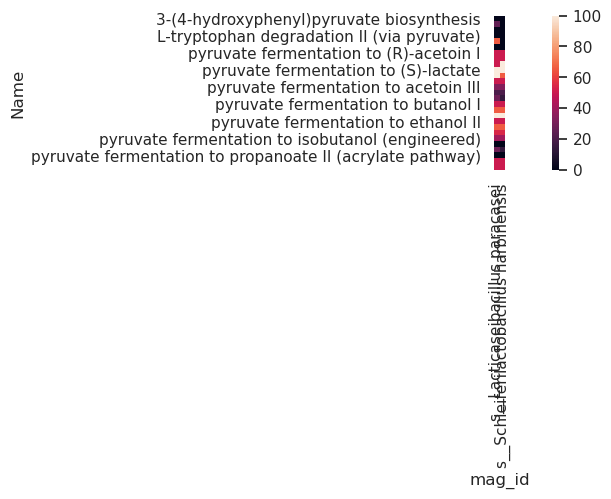

In [1009]:

# plt.savefig('/data/mhoffert/fiererlab/beer/figures/lacto_pathways.png', dpi=300, bbox_inches='tight')

In [1002]:
plotdf['sample_no_time'] = plotdf[~plotdf.timepoint.eq('initial')]['Sample ID'].apply(lambda x: x.split('-')[0])
delta_malto = md.pivot_table(index='sample_no_time', columns='timepoint', values='Maltotriose')
delta_malto = delta_malto['3 week'] - delta_malto['1 week']

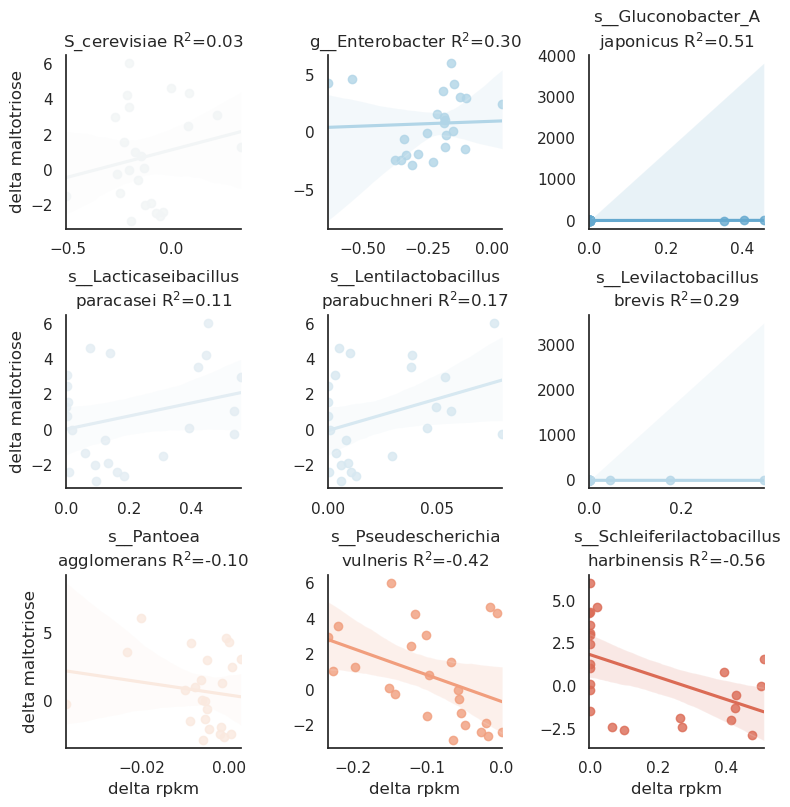

In [1008]:
# second subplot
idx = pd.IndexSlice
fig = plt.figure(figsize=(9, 9))

# colors = ['navy', 'green', 'magenta', 'orange']
jet = cm = plt.get_cmap('RdBu') 
cNorm  = colors.Normalize(vmin=-1, vmax=1)
scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=jet)

scatter_kws = {'linewidth':0}

i = 1
for s in plotdf['species'].unique():
    ax = fig.add_subplot(3,3,i)
    r_val = spearmanr(delta_rpkm.loc[idx[delta_malto.index, s]], delta_malto)[0]
    
    sns.regplot(x=delta_rpkm.loc[idx[:, s]], y=delta_malto, color=scalarMap.to_rgba(r_val))

    newtitle = s.replace(' ', '\n')
    ax.set_title(newtitle + f' R$^2$={r_val:.2f}')
    if i > 6:
        ax.set_xlabel('delta rpkm')
    else:
        ax.set_xlabel('')
    if i % 3 == 1:
        ax.set_ylabel('delta maltotriose')
    else:
        ax.set_ylabel('')
    
    sns.despine()
    i += 1
    
fig.subplots_adjust(wspace=0.5, hspace=0.5)
# plt.savefig('/data/mhoffert/fiererlab/beer/figures/delta_ph.png', dpi=300, bbox_inches='tight')

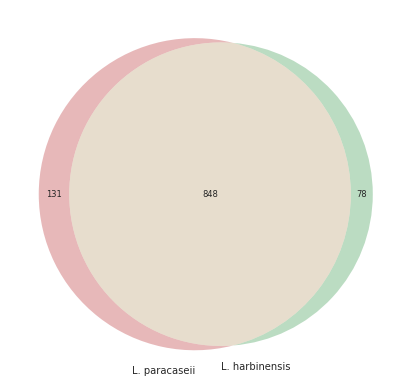

In [639]:
lacto_go_table = tables[tables['mag'].isin(['s__Lacticaseibacillus paracasei','s__Schleiferilactobacillus harbinensis'])].pivot_table(index='mag', columns='go', values='present').fillna(0)
para_set = set(lacto_go_table.columns[lacto_go_table.iloc[0, :].values == 1])
harb_set = set(lacto_go_table.columns[lacto_go_table.iloc[1, :].values == 1])
venn2([para_set, harb_set], set_labels=['L. paracaseii', 'L. harbinensis'])

In [601]:
sns.set(font_scale=0.5)

In [607]:
go2go_annot = interpro_go_data.groupby('go').first()['go_annot'].to_dict()
lacto_go_table.loc[:, (lacto_go_table.sum() == 1)].rename(columns=go2go_annot).T.sort_values('s__Schleiferilactobacillus harbinensis').tail(10)

mag,s__Lacticaseibacillus paracasei,s__Schleiferilactobacillus harbinensis
go,,
glycerate kinase activity,0.0,1.0
citryl-CoA lyase activity,0.0,1.0
UDP-galactopyranose mutase activity,0.0,1.0
L-fucose isomerase activity,0.0,1.0
L-arabinose isomerase activity,0.0,1.0
D-serine ammonia-lyase activity,0.0,1.0
5-amino-6-(5-phosphoribosylamino)uracil reductase activity,0.0,1.0
3-deoxy-8-phosphooctulonate synthase activity,0.0,1.0
hexose metabolic process,0.0,1.0


#### Notes
L. harbinensis is driving down pH. Do other species have lower "minimal pH" values?

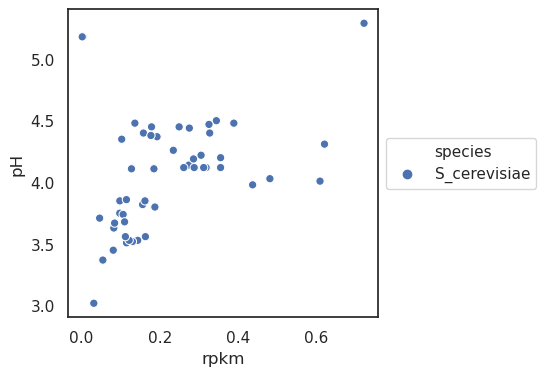

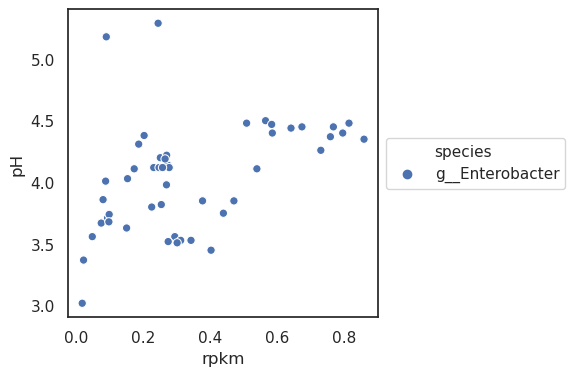

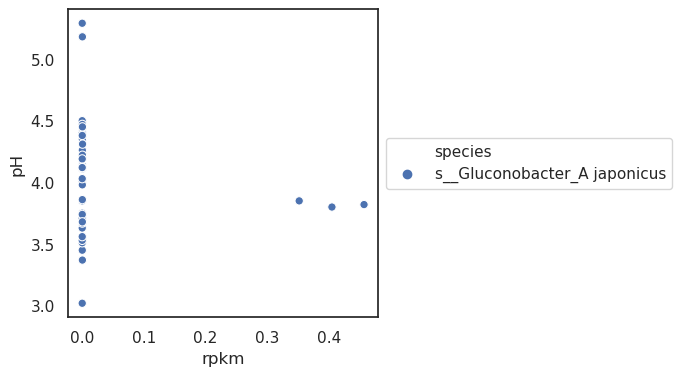

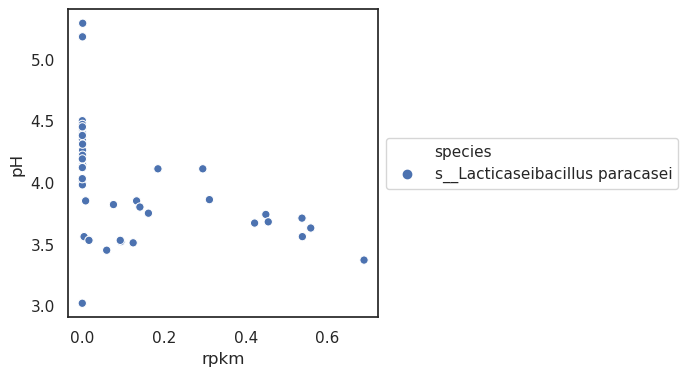

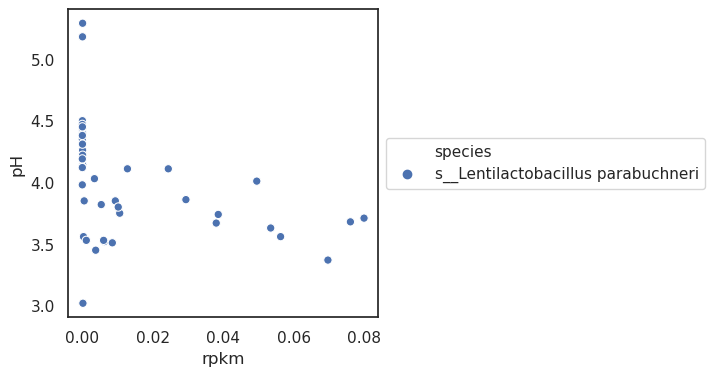

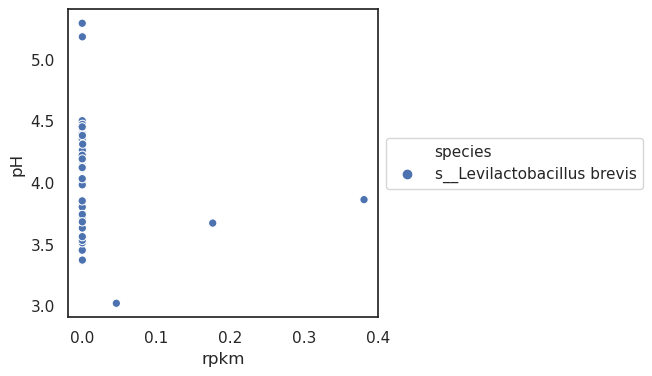

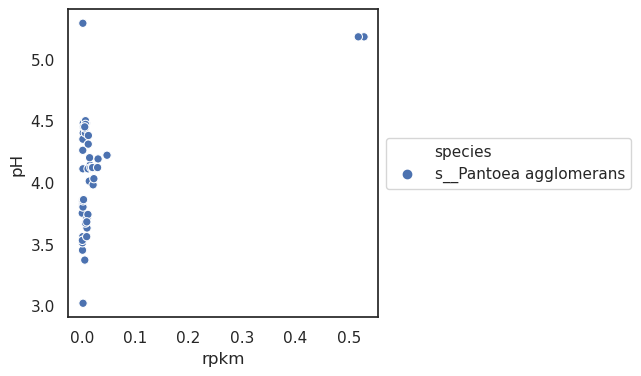

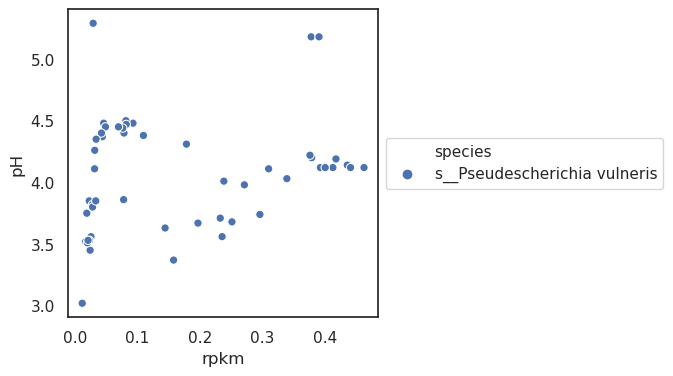

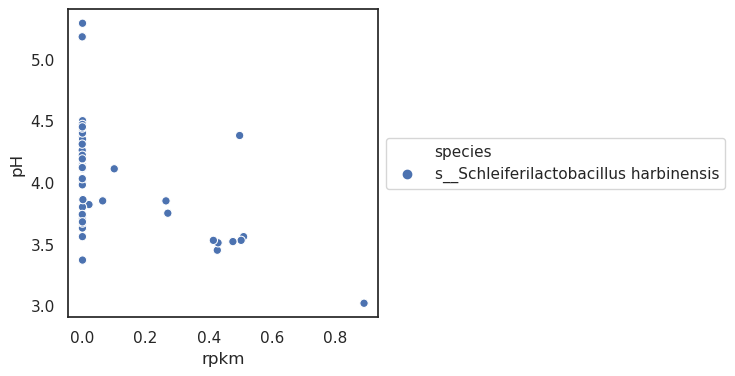

In [742]:
for species in plotdf['species'].unique():
    fig, ax = plt.subplots(figsize=(4,4))
    sns.scatterplot(data=plotdf[plotdf.species.eq(species)], x='rpkm', y='pH', hue='species', ax=ax)
    lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

### Pathway comparison

In [82]:
pathway_data = glob.glob('/data/mhoffert/fiererlab/beer/mag_pipeline/derep_mags/gapseq_test/*Pathways.tbl')

In [83]:
all_pathway_data = pd.concat([pd.read_csv(p, sep='\t', skiprows=3).assign(mag_id=p.split('/')[-1].split('_protein')[0]) for p in pathway_data])

In [84]:
pathway_heatmap_data = all_pathway_data.pivot_table(index='Name', columns='mag_id', values='Completeness').fillna(0).rename(columns=mag2species)

In [97]:
pathway_heatmap_data

mag_id,s__Gluconobacter_A japonicus,s__Lacticaseibacillus paracasei,s__Schleiferilactobacillus harbinensis,s__Pantoea agglomerans,s__Levilactobacillus brevis,s__Pseudescherichia vulneris,s__,s__Lentilactobacillus parabuchneri
Name,,,,,,,,
&alpha;-amyrin biosynthesis,0,0,0,0,0,0,0,0
&alpha;-carotene biosynthesis,0,0,0,0,0,0,0,0
&alpha;-cyclopiazonate biosynthesis,0,0,0,0,0,0,0,0
&alpha;-cyclopiazonate detoxification,0,0,0,0,0,0,0,0
&alpha;-diglucosyldiacylglycerol biosynthesis,0,50,50,0,50,0,0,50
...,...,...,...,...,...,...,...,...
zeaxanthin biosynthesis,0,0,0,100,0,100,0,0
zeaxanthin-&beta;-D-diglucoside biosynthesis,0,0,0,100,0,100,0,0
zerumbone biosynthesis,0,0,0,0,0,0,0,0


In [106]:
lab_aab = ['s__Gluconobacter_A japonicus', 's__Lacticaseibacillus paracasei',
's__Schleiferilactobacillus harbinensis', 's__Levilactobacillus brevis',
's__Lentilactobacillus parabuchneri']

In [150]:
keywords = ['pyruvate', 'maltose', 'TCA', 'lactate', 'arginine', 'glutamine', 'glutamate', 'malate', 'Histidine', 'citrate', 'acetate']
heatmap_subset = [s for s in pathway_heatmap_data.index if any(i in s for i in keywords)]

In [151]:
fermentation_figure_data = pathway_heatmap_data.loc[heatmap_subset, :]

In [152]:
fermentation_figure_data = fermentation_figure_data.loc[(fermentation_figure_data == 100).sum(1) >= 1, :]

In [153]:
# fermentation_figure_data = fermentation_figure_data.loc[(fermentation_figure_data.loc[:, lab_aab] == 100).sum(1) >= 1, :]

/data/mhoffert/miniconda3/envs/beer_metagenomics/lib/python3.8/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(**tight_params)


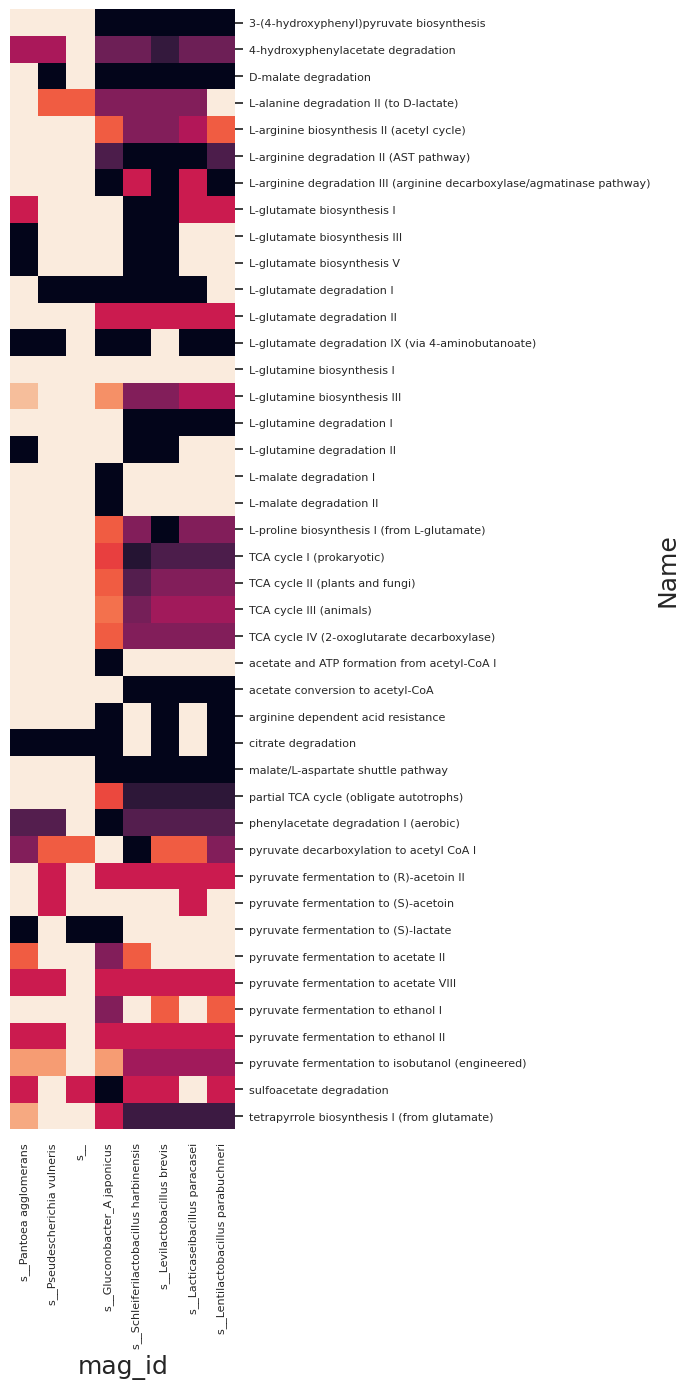

In [175]:
g = sns.clustermap(fermentation_figure_data, figsize=(4, 20), row_cluster=False)
g.ax_heatmap.tick_params(labelsize=8)
g.ax_cbar.remove()
g.ax_col_dendrogram.remove()
g.ax_row_dendrogram.remove()

In [156]:
pathway_heatmap_data[pathway_heatmap_data.index.str.contains('maltose')]

mag_id,s__Gluconobacter_A japonicus,s__Lacticaseibacillus paracasei,s__Schleiferilactobacillus harbinensis,s__Pantoea agglomerans,s__Levilactobacillus brevis,s__Pseudescherichia vulneris,s__,s__Lentilactobacillus parabuchneri
Name,,,,,,,,
glycogen biosynthesis III (from &alpha;-maltose 1-phosphate),50,37,37,50,25,62,62,25
maltose degradation,0,0,0,0,0,0,0,0


In [158]:
table

,S_cerevisiae,g__Enterobacter,s__Gluconobacter_A japonicus,s__Lacticaseibacillus paracasei,s__Lentilactobacillus parabuchneri,s__Levilactobacillus brevis,s__Pantoea agglomerans,s__Pseudescherichia vulneris,s__Schleiferilactobacillus harbinensis
sample_name,,,,,,,,,
CommStd_S36,5.522979,6.230058,0.112916,0.330954,0.004396,0.308949,0.603268,4.056984,0.247017
ExtB1_S43,68.173521,105.254034,1.003624,63.004534,7.127414,0.065378,13.681537,64.995662,46.825246
HC1_S1,107.758136,36.448063,0.000164,0.180938,0.017283,0.000025,0.323434,4.375019,0.149213
HI1-1_S46,48.848935,292.094805,0.000045,0.010081,0.003780,0.000050,1.060631,16.577554,0.059789
HI1-3_S6,41.921417,188.812844,0.000336,69.644149,4.574688,0.029238,0.417488,8.235550,116.267355
HI2-1_S50,63.693676,273.451107,0.000230,0.192491,0.020545,0.000027,1.180448,17.458278,0.174158
HI2-3_S12,50.500169,213.585575,0.000091,73.361376,5.081964,0.023502,0.910374,12.516940,40.084955
HI3-1_S4,68.186462,268.418879,0.000032,0.263308,0.031678,0.000092,1.110009,15.553427,0.140321
HI3-3_S20,41.254310,198.710553,0.000148,56.181922,3.966488,0.022117,0.620957,9.738126,111.741355


In [117]:
pathway_heatmap_data.loc[pathway_heatmap_data.index.str.contains('pyruvate'), :]

mag_id,s__Gluconobacter_A japonicus,s__Lacticaseibacillus paracasei,s__Schleiferilactobacillus harbinensis,s__Pantoea agglomerans,s__Levilactobacillus brevis,s__Pseudescherichia vulneris,s__,s__Lentilactobacillus parabuchneri
Name,,,,,,,,
3-(4-hydroxyphenyl)pyruvate biosynthesis,0,0,0,100,0,100,100,0
L-arginine degradation IX (arginine:pyruvate transaminase pathway),25,25,0,25,0,25,25,25
L-glutamate degradation VI (to pyruvate),0,0,0,0,0,25,0,0
L-tryptophan degradation II (via pyruvate),0,0,0,0,0,0,0,0
pyruvate decarboxylation to acetyl CoA I,100,66,0,33,66,66,66,33
pyruvate decarboxylation to acetyl CoA II,0,0,0,0,0,0,0,0
pyruvate fermentation to (R)-acetoin I,50,50,50,50,50,50,50,50
pyruvate fermentation to (R)-acetoin II,50,50,50,100,50,50,100,50
pyruvate fermentation to (S)-acetoin,100,50,100,100,100,50,100,100


/data/mhoffert/miniconda3/envs/beer_metagenomics/lib/python3.8/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(**tight_params)


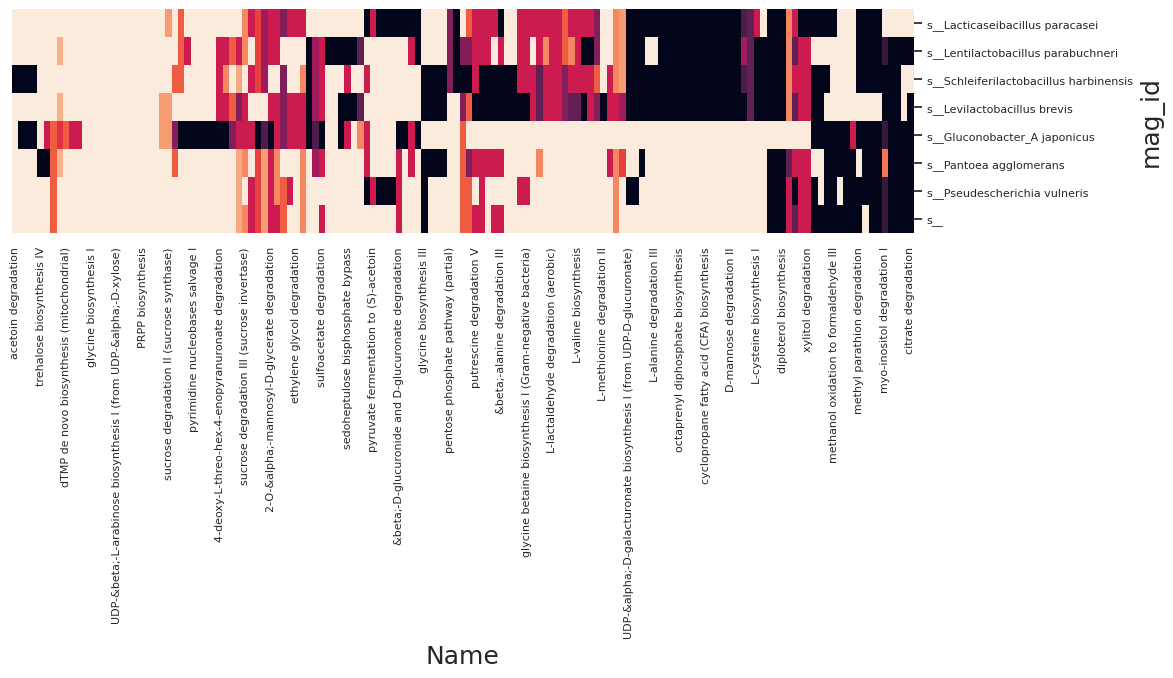

In [112]:
# test1 = 
test2 = ((pathway_heatmap_data[lab_aab] == 100).sum(1) > 0)
g = sns.clustermap(pathway_heatmap_data.loc[test2, :], figsize=(5,2))
g.ax_heatmap.tick_params(labelsize=8)
g.ax_cbar.remove()
g.ax_col_dendrogram.remove()
g.ax_row_dendrogram.remove()

In [ ]:
pathways = ['maltose degradation', '']

In [103]:
(pathway_heatmap_data == 100).sum(1) >= 2

Name
&alpha;-amyrin biosynthesis                      False
&alpha;-carotene biosynthesis                    False
&alpha;-cyclopiazonate biosynthesis              False
&alpha;-cyclopiazonate detoxification            False
&alpha;-diglucosyldiacylglycerol biosynthesis    False
                                                 ...  
zeaxanthin biosynthesis                           True
zeaxanthin-&beta;-D-diglucoside biosynthesis      True
zerumbone biosynthesis                           False
zwittermicin A biosynthesis                      False
zymosterol biosynthesis                          False
Length: 2857, dtype: bool

In [105]:
pathway_heatmap_data.columns

Index(['s__Gluconobacter_A japonicus', 's__Lacticaseibacillus paracasei',
       's__Schleiferilactobacillus harbinensis', 's__Pantoea agglomerans',
       's__Levilactobacillus brevis', 's__Pseudescherichia vulneris', 's__',
       's__Lentilactobacillus parabuchneri'],
      dtype='object', name='mag_id')

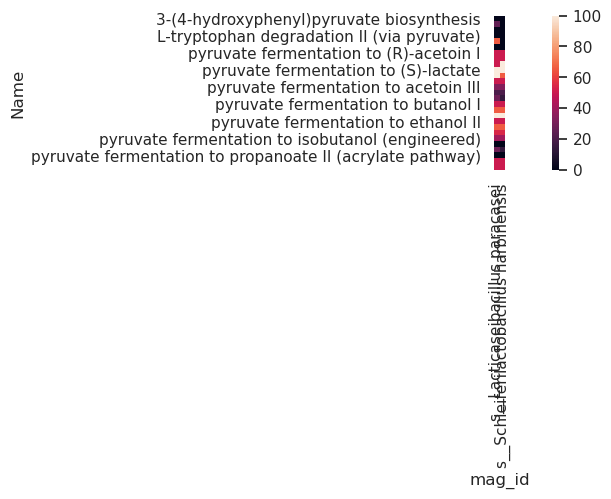

In [1009]:
pyruvate_pathways = [s for s in pathway_heatmap_data.index if 'pyruvate' in s]
pyruvate_data = pathway_heatmap_data.loc[pyruvate_pathways, ['s__Lacticaseibacillus paracasei','s__Schleiferilactobacillus harbinensis']].T
fig, ax = plt.subplots(figsize=(12, 2))
sns.heatmap(pyruvate_data.T, square=True)
# plt.savefig('/data/mhoffert/fiererlab/beer/figures/lacto_pathways.png', dpi=300, bbox_inches='tight')

In [ ]:
# multidrug resistance
# iron and zince homeostasis
# HorA, horB, horC
# maltotriose organisms

In [725]:
# number of transport-associated GO terms
for s in ['s__Lacticaseibacillus paracasei','s__Schleiferilactobacillus harbinensis']:
    print(s)
    print('N transporters:', len(tables[tables['mag'].eq(s) & tables['interpro_annotations'].apply(lambda x: x.lower()).str.contains('multidrug')]['sequence_md5'].unique()))

s__Lacticaseibacillus paracasei
N transporters: 3
s__Schleiferilactobacillus harbinensis
N transporters: 6


In [727]:
# number of transport-associated GO terms
for s in ['s__Lacticaseibacillus paracasei','s__Schleiferilactobacillus harbinensis']:
    print(s)
    print('N transporters:', len(tables[tables['mag'].eq(s) & tables['interpro_annotations'].apply(lambda x: x.lower()).str.contains('zinc transport')]['sequence_md5'].unique()))

s__Lacticaseibacillus paracasei
N transporters: 3
s__Schleiferilactobacillus harbinensis
N transporters: 4


In [728]:
# number of transport-associated GO terms
for s in ['s__Lacticaseibacillus paracasei','s__Schleiferilactobacillus harbinensis']:
    print(s)
    print('N transporters:', len(tables[tables['mag'].eq(s) & tables['interpro_annotations'].apply(lambda x: x.lower()).str.contains('iron transport')]['sequence_md5'].unique()))

s__Lacticaseibacillus paracasei
N transporters: 3
s__Schleiferilactobacillus harbinensis
N transporters: 1


In [641]:
lacto_heatmap_data = pathway_heatmap_data[['s__Lacticaseibacillus paracasei','s__Schleiferilactobacillus harbinensis']]
lacto_heatmap_data[((lacto_heatmap_data > 0).sum(1) == 1) & (lacto_heatmap_data > 75).sum(1)].sort_values('s__Lacticaseibacillus paracasei')

mag_id,s__Lacticaseibacillus paracasei,s__Schleiferilactobacillus harbinensis
Name,,
&beta;-D-glucuronide and D-glucuronate degradation,0.0,100.0
L-lactaldehyde degradation (anaerobic),0.0,100.0
meso-butanediol biosynthesis I,0.0,100.0
methanol oxidation to formaldehyde III,0.0,100.0
L-asparagine biosynthesis II,0.0,100.0
glycine betaine biosynthesis II (Gram-positive bacteria),0.0,100.0
D-xylose degradation I,0.0,100.0
ethylene glycol degradation,0.0,100.0
D-arabinose degradation I,0.0,100.0


In [863]:
mag2species

user_genome
HI4-3_MAG_04              s__Gluconobacter_A japonicus
HO2-3_MAG_03           s__Lacticaseibacillus paracasei
HO2-3_MAG_04    s__Schleiferilactobacillus harbinensis
UO2-1_MAG_03                    s__Pantoea agglomerans
UO2-3_MAG_03               s__Levilactobacillus brevis
UO5-1_MAG_01              s__Pseudescherichia vulneris
UO5-1_MAG_02                           g__Enterobacter
UO6-3_MAG_03        s__Lentilactobacillus parabuchneri
S_cerevisiae                              S_cerevisiae
Name: classification, dtype: object

In [870]:
harbinensis_rxns = pd.read_csv('/data/mhoffert/fiererlab/beer/mag_pipeline/derep_mags/gapseq_test/HO2-3_MAG_04_protein-all-Reactions.tbl', sep='\t', skiprows=3)
harbinensis_rxns

,rxn,name,ec,bihit,qseqid,pident,evalue,bitscore,qcovs,stitle,sstart,send,pathway,status,pathway.status,dbhit,complex,exception,complex.status
0,DHLAXANAU-RXN,"1,2-dichloroethane dehalogenase",3.8.1.5,NaN,UniRef90_Q93K00,18.284,7.600000e-07,45.8,84.0,NODE_131_length_30522_cov_490.361375_20 # 2111...,26.0,287.0,|12DICHLORETHDEG-PWY|,bad_blast,NaN,rxn03596 rxn03668 rxn03669 rxn03670 rxn03671 r...,NaN,0,NaN
1,MOXXANAU-RXN,2-chloroethanol dehydrogenase,1.1.2.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,|12DICHLORETHDEG-PWY|,no_blast,NaN,rxn00847 rxn01796 rxn12745 rxn14207 rxn15989 r...,Subunit 1,0,NaN
2,MOXXANAU-RXN,2-chloroethanol dehydrogenase,1.1.2.7,NaN,UniRef90_P14775,28.767,4.500000e+00,22.7,76.0,NODE_4_length_347146_cov_415.003498_108 # 9549...,253.0,318.0,|12DICHLORETHDEG-PWY|,bad_blast,NaN,rxn00847 rxn01796 rxn12745 rxn14207 rxn15989 r...,Subunit 2,0,NaN
3,ALDXANAU-RXN,chloroacetaldehyde dehydrogenase,1.2.1.4,NaN,UniRef90_Q8GAK7,37.251,4.570000e-98,298.0,98.0,NODE_100_length_46310_cov_483.864080_32 # 3901...,1.0,447.0,|12DICHLORETHDEG-PWY|,good_blast,NaN,rxn00507 rxn03455 rxn05880 rxn14071 rxn19116,NaN,0,1.0
4,DHLBXANAU-RXN,chloroacetate dehalogenase,3.8.1.3,NaN,UniRef90_Q01398,24.723,3.000000e-03,34.7,89.0,NODE_75_length_60811_cov_459.525512_26 # 29731...,21.0,257.0,|12DICHLORETHDEG-PWY|,bad_blast,NaN,rxn02050 rxn03599 rxn06154 rxn19881,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19188,ACETOLACTSYN-RXN,acetolactate synthase,2.2.1.6/4.1.3.18,NaN,sp|P0ADF8|ILVN_ECOLI,23.810,4.500000e+00,22.7,81.0,NODE_141_length_26421_cov_385.421793_12 # 1205...,30.0,108.0,|VALSYN-PWY|,bad_blast,NaN,rxn00003 rxn00011 rxn02185 rxn03194 rxn08043 r...,Subunit 2,0,1.0
19189,ACETOLACTSYN-RXN,acetolactate synthase,2.2.1.6/4.1.3.18,NaN,sp|P27696|ILVB_KLEPN,48.624,2.740000e-173,498.0,96.0,NODE_43_length_98009_cov_496.037630_92 # 94751...,8.0,550.0,|VALSYN-PWY|,good_blast,NaN,rxn00003 rxn00011 rxn02185 rxn03194 rxn08043 r...,Subunit undefined,0,1.0
19190,XYLULOKIN-RXN,xylulokinase,2.7.1.17,NaN,sp|P09099|XYLB_ECOLI,34.440,1.470000e-82,261.0,98.0,NODE_42_length_98248_cov_481.212663_46 # 52082...,6.0,486.0,|XYLCAT-PWY|,good_blast,full,rxn01199,NaN,0,1.0
19191,XYLULOKIN-RXN,xylulokinase,2.7.1.17,NaN,sp|P09099|XYLB_ECOLI,29.259,2.260000e-60,203.0,99.0,NODE_156_length_20561_cov_518.928216_8 # 6516 ...,6.0,496.0,|XYLCAT-PWY|,good_blast,full,rxn01199,NaN,0,1.0


## Additional genomics figures

In [9]:
# # get MAG name mapping
mag_gtdbtk = pd.read_csv('/data/mhoffert/fiererlab/beer/mag_pipeline/derep_mags/gtdbtk.bac120.summary.tsv', sep='\t')
mag2species = mag_gtdbtk.set_index('user_genome')['classification'].apply(lambda x: x.split(';')[-1])

mag2species

user_genome
HI4-3_MAG_04              s__Gluconobacter_A japonicus
HO2-3_MAG_03           s__Lacticaseibacillus paracasei
HO2-3_MAG_04    s__Schleiferilactobacillus harbinensis
UO2-1_MAG_03                    s__Pantoea agglomerans
UO2-3_MAG_03               s__Levilactobacillus brevis
UO5-1_MAG_01              s__Pseudescherichia vulneris
UO5-1_MAG_02                                       s__
UO6-3_MAG_03        s__Lentilactobacillus parabuchneri
Name: classification, dtype: object

In [196]:
from pycirclize import Circos
from pygenomeviz.parser import Genbank
from pygenomeviz.utils import load_example_genbank_dataset
from pygenomeviz.align import MUMmer
import re
from pathlib import Path

In [197]:
from sklearn.preprocessing import MinMaxScaler

In [198]:
from pycirclize.parser import Gff
from pycirclize.utils import load_prokaryote_example_file


In [199]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Ellipse
from itertools import combinations

In [200]:
import itertools

import matplotlib as mpl

### Initial drawing of annotations

In [201]:
def process_interpro(file):
    
    columns = ['gene_ID', 'gene_md4', 'gene_length', 'analysis', 'match_acc', 
               'match_desc', 'match_start', 'match_stop', 'score',  'match_status', 
               'date', 'interpro_acc', 'interpro_desc',]
    annot = pd.read_csv(file, sep='\t', names=columns, comment="#")
    annot['contig'] = annot['gene_ID'].apply(lambda x: '_'.join(x.split('_')[:-1]))
    annot['gene_order_contig'] = annot['gene_ID'].apply(lambda x: '_'.join(x.split('_')[:-1]))
    return annot


# --- 1. Parse the protein FASTA headers ---
def parse_prodigal_header(header):
    """
    Input:  '>NODE_2_length_383871_cov_263.307098_2 # 2919 # 3362 # 1 # ID=...'
    Returns: dict of parsed fields
    """
    # gene_ID is the full header ID (e.g. NODE_2_length_383871_cov_263.307098_2)
    gene_id = header.lstrip(">").split()[0]
    
    # seqid = everything except the trailing gene number
    seqid = "_".join(gene_id.split("_")[:-1])
    
    parts = header.split(" # ")
    start  = int(parts[1])
    end    = int(parts[2])
    strand = "+" if parts[3].strip() == "1" else "-"
    
    return {"gene_ID": gene_id, "seqid": seqid,
            "start": start, "end": end, "strand": strand}

def process_faa(protein_file):
    '''
    read and parse a prodigal file
    '''
    records = []
    with open(protein_file) as f:
        for line in f:
            if line.startswith(">"):
                records.append(parse_prodigal_header(line.strip()))

    genes_df = pd.DataFrame(records)
    
    return genes_df


def write_gff_file(df, output):
    '''
    write a gff3 format file
    '''
    with open(output, "w") as out:
        out.write("##gff-version 3\n")
        for _, row in df.iterrows():
            attributes = (
                f"ID={row['gene_ID']}:{row['match_acc']};"
                f"Name={row['match_desc']};"
                f"Ontology_term={row['interpro_acc']};"
                f"interpro_desc={row['interpro_desc']}"
            )
            score = row['score'] if row['score'] != "-" else "."

            fields = [
                row['seqid'],        # 1. seqid
                row['analysis'],     # 2. source
                "protein_match",     # 3. type
                row['start'],        # 4. start
                row['end'],          # 5. end
                score,               # 6. score
                row['strand'],       # 7. strand
                ".",                 # 8. phase
                attributes           # 9. attributes
            ]
            out.write("\t".join(str(f) for f in fields) + "\n")

def make_gff(protein_file, interpro_file, gff_out):
    
    Path(protein_file).resolve(strict=True)
    Path(interpro_file).resolve(strict=True)
    
    genes_df = process_faa(protein_file)
    ips_df = process_interpro(interpro_file)

    # --- 3. Merge and write GFF3 ---
    merged = ips_df.merge(genes_df, on="gene_ID")
    
    write_gff_file(merged, gff_out)
    



In [202]:
harb_file = '/data/mhoffert/fiererlab/beer/mag_pipeline/derep_mags/HO2-3_MAG_04_interpro.tsv'
para_file = '/data/mhoffert/fiererlab/beer/mag_pipeline/derep_mags/HO2-3_MAG_03_interpro.tsv'

harb_annot = process_interpro(harb_file)
harb_annot

para_annot = process_interpro(para_file)
para_annot.head(2)

,gene_ID,gene_md4,gene_length,analysis,match_acc,match_desc,match_start,match_stop,score,match_status,date,interpro_acc,interpro_desc,contig,gene_order_contig
0,NODE_73_length_61317_cov_13.789739_11,9ecb0545c7f9a86d6027a1c189412e81,125,MobiDBLite,mobidb-lite,consensus disorder prediction,64,125,-,T,30-05-2023,-,-,NODE_73_length_61317_cov_13.789739,NODE_73_length_61317_cov_13.789739
1,NODE_73_length_61317_cov_13.789739_11,9ecb0545c7f9a86d6027a1c189412e81,125,MobiDBLite,mobidb-lite,consensus disorder prediction,52,125,-,T,30-05-2023,-,-,NODE_73_length_61317_cov_13.789739,NODE_73_length_61317_cov_13.789739


In [203]:
# make example gffs for all genomes
for mag_faa in glob.glob('./../mag_pipeline/derep_mags/*_protein.faa'):
    print(mag_faa)
    make_gff(mag_faa,
         mag_faa.replace('_protein.faa', '_interpro.tsv'),
         mag_faa.replace('_protein.faa', '.gff'))

./../mag_pipeline/derep_mags/HI4-3_MAG_04_protein.faa
./../mag_pipeline/derep_mags/HO2-3_MAG_03_protein.faa
./../mag_pipeline/derep_mags/HO2-3_MAG_04_protein.faa
./../mag_pipeline/derep_mags/UO2-1_MAG_03_protein.faa
./../mag_pipeline/derep_mags/UO2-3_MAG_03_protein.faa
./../mag_pipeline/derep_mags/UO5-1_MAG_01_protein.faa
./../mag_pipeline/derep_mags/UO5-1_MAG_02_protein.faa
./../mag_pipeline/derep_mags/UO6-3_MAG_03_protein.faa


In [13]:
mag2species

user_genome
HI4-3_MAG_04              s__Gluconobacter_A japonicus
HO2-3_MAG_03           s__Lacticaseibacillus paracasei
HO2-3_MAG_04    s__Schleiferilactobacillus harbinensis
UO2-1_MAG_03                    s__Pantoea agglomerans
UO2-3_MAG_03               s__Levilactobacillus brevis
UO5-1_MAG_01              s__Pseudescherichia vulneris
UO5-1_MAG_02                                       s__
UO6-3_MAG_03        s__Lentilactobacillus parabuchneri
Name: classification, dtype: object

In [204]:
# Load GFF file
# gff_file = load_prokaryote_example_file()
para_gff = Gff("./../mag_pipeline/derep_mags/HO2-3_MAG_03.gff")
harb_gff = Gff("./../mag_pipeline/derep_mags/HO2-3_MAG_04.gff")
entero_gff = Gff("./../mag_pipeline/derep_mags/UO5-1_MAG_02.gff")
vuln_gff = Gff("./../mag_pipeline/derep_mags/UO5-1_MAG_01.gff")
gluc_gff = Gff("./../mag_pipeline/derep_mags/HI4-3_MAG_04.gff")

In [205]:
gffs = [para_gff,
harb_gff,
entero_gff,
vuln_gff,
gluc_gff]

In [206]:
# mapping of gene id to genome id
gene2genome = pd.Series(dtype='object')
for g in gffs:
    print(g.name)
    for i, r in enumerate(g.all_records):
        gene2genome.loc[r.attrs['ID'][0].split(':')[0]] = g.name

HO2-3_MAG_03
HO2-3_MAG_04
UO5-1_MAG_02
UO5-1_MAG_01
HI4-3_MAG_04


In [207]:
assert len(gene2genome) == len(gene2genome.index.unique())
gene2genome.head()


NODE_73_length_61317_cov_13.789739_11     HO2-3_MAG_03
NODE_5_length_342301_cov_13.025514_111    HO2-3_MAG_03
NODE_5_length_342301_cov_13.025514_231    HO2-3_MAG_03
NODE_26_length_120256_cov_13.705435_10    HO2-3_MAG_03
NODE_49_length_89051_cov_14.155513_87     HO2-3_MAG_03
dtype: object

In [208]:
harb_features = harb_gff.get_seqid2features(feature_type="protein_match")
print(len(harb_features))

68


In [19]:
def get_regions(sector_features):
    '''
    get regions for links
    input: result of 
    x.get_seqid2features(feature_type="protein_match")[sector.name]

    '''
    return np.array([(r.id.split(':')[0], 
                          r.location.start, 
                          r.location.end, 
                          r.qualifiers['Ontology_term'][0]) for r in sector_features if not r.qualifiers['Ontology_term'][0] == '-'], dtype='object')

def first_match(a, B):
    idx = np.where(B == a)[0]
    return idx[0] if len(idx) else None


def get_links(gff1, gff2, target_sector, all_sectors):
    '''
    links: list(tuple(tuple, tuple)) 
    list of pairs of ID, start, stop
    for each link from gff1 -> gff2
    '''
    sector_features1 = gff1.get_seqid2features(feature_type="protein_match")[target_sector.name]
    regions1 = get_regions(sector_features1)

    links = []
    for _sector in all_sectors:
        if _sector.name in gff2.get_seqid2size().keys():
            # print('yes')
            sector_features2 = gff2.get_seqid2features(feature_type="protein_match")[_sector.name]

            regions2 = get_regions(sector_features2)
    
            matches = np.array([first_match(a, regions2) for a in regions1])
            # print(matches)
            for loc1, loc2 in enumerate(matches):
                if loc2 is not None:
                # print(loc1, loc2)
                    links.append((tuple(regions1[loc1][:3]),  
                                  tuple(regions2[loc2][:3])))
    return links


In [20]:
harb_annot.head(2)

,gene_ID,gene_md4,gene_length,analysis,match_acc,match_desc,match_start,match_stop,score,match_status,date,interpro_acc,interpro_desc,contig,gene_order_contig
0,NODE_52_length_86887_cov_348.192901_5,c449cf1dcd4ea59ddf5c5d507b573727,174,Pfam,PF01625,Peptide methionine sulfoxide reductase,5,156,3.7E-60,T,30-05-2023,IPR002569,Peptide methionine sulphoxide reductase MsrA d...,NODE_52_length_86887_cov_348.192901,NODE_52_length_86887_cov_348.192901
1,NODE_52_length_86887_cov_348.192901_5,c449cf1dcd4ea59ddf5c5d507b573727,174,SUPERFAMILY,SSF55068,Peptide methionine sulfoxide reductase,4,157,4.19E-70,T,30-05-2023,IPR036509,Peptide methionine sulphoxide reductase MsrA s...,NODE_52_length_86887_cov_348.192901,NODE_52_length_86887_cov_348.192901


In [648]:
# # Initialize circos instance
# eqid2size = gff.get_seqid2size()
# space = 0 if len(seqid2size) == 1 else 2
# circos = Circos(sectors=dict(**para_gff.get_seqid2size(), **dict(reversed(list(harb_gff.get_seqid2size().items())))),
#                 start=-358,
#     end=2,
#     space=1,
#                 sector2clockwise={seqid: False for seqid in harb_gff.get_seqid2size().keys()})

# circos.text(f"harb\n({harb_gff.full_genome_length:,} bp)", r=130, deg=-35, size=13)
# circos.text(f"para\n({para_gff.full_genome_length:,} bp)", r=130, deg=35, size=13)

# seqid2features = {**harb_gff.get_seqid2features(feature_type="protein_match"), 
#                   **para_gff.get_seqid2features(feature_type="protein_match")}

# for sector in circos.sectors[-1:]:
#     if sector.name in harb_gff.get_seqid2size().keys():
#         color='gray'    
#     else:
#         color='lightgray'
#     cds_track = sector.add_track((90, 100))
#     cds_track.axis(fc=color, ec="none")
    
# pal = sns.color_palette('gist_rainbow', n_colors=len(circos.sectors))
# # pal = [sns.desaturate(c, 0.5) for c in sns.color_palette('gist_rainbow', n_colors=5)]
# for c_i, sector in enumerate(circos.sectors[-1:]):
#     if sector.name in harb_gff.get_seqid2size().keys():
#         links = get_links(harb_gff, para_gff, sector, circos.sectors)
#         for i, link in enumerate(links):
#             circos.link(link[0], link[1], r1=98, r2=98, alpha=0.1, color=pal[c_i])


# fig = circos.plotfig()

### Adding OrthoFinder orthogroups

In [209]:
seq2genome = []
n_records = 0
# for each protein fasta in orthofinder run
for faa in glob.glob('./../data/orthofinder/proteomes/*.faa'):
    # get records
    with open(faa, 'r') as handle:
        faa_lines = handle.readlines()
    # get genome id
    genome = faa.split('/')[-1].replace('_protein.faa', '')
    # get sequence ids
    headers = [l.split(' ')[0].lstrip('>') for l in faa_lines if l[0] == '>']
    # make series of seq id -> genome id
    seq2genome.append(pd.Series(index=headers, data=[genome]*len(headers)))
    # header count
    n_records += len(headers)

seq2genome = pd.concat(seq2genome)

In [210]:
# check all records have unique ids
len(set(seq2genome.index)), n_records

(24653, 24653)

In [211]:
with open('./../data/orthofinder/proteomes/OrthoFinder/Results_Jun26_1/Orthogroups/Orthogroups.txt', 'r') as handle:
    lines = handle.readlines()

In [212]:
orthogroup_counts = []
gene2ortho = []
for l in lines:
    splits = l.split(': ')
    group, members = splits[0], splits[1].strip().split(' ')
    genome_ids = [seq2genome.loc[m] for m in members]
    orthogroup_counts.append(pd.Series(genome_ids, name=group).value_counts())
    gene2ortho.append(pd.Series(index=members, data=[group]*len(members)))
    
gene2ortho = pd.concat(gene2ortho)
orthogroup_counts = pd.concat(orthogroup_counts, axis=1).T

# orthogroup_counts = orthogroup_counts.rename(columns=mag2species)

In [213]:
mag2species

user_genome
HI4-3_MAG_04              s__Gluconobacter_A japonicus
HO2-3_MAG_03           s__Lacticaseibacillus paracasei
HO2-3_MAG_04    s__Schleiferilactobacillus harbinensis
UO2-1_MAG_03                    s__Pantoea agglomerans
UO2-3_MAG_03               s__Levilactobacillus brevis
UO5-1_MAG_01              s__Pseudescherichia vulneris
UO5-1_MAG_02                                       s__
UO6-3_MAG_03        s__Lentilactobacillus parabuchneri
Name: classification, dtype: object

In [214]:
def venn_orthos(id1, id2, orthogroups):
    '''
    make a venn diagram comparing orthogroups of two species
    orthogroups: index = orthos, cols = species, values = counts or T/F
    '''
    assert all(i in orthogroups.columns for i in [id1, id2]), 'ids must be in orthogroup.columns'
    group1 = orthogroup_counts.loc[:, id1]
    group2 = orthogroup_counts.loc[:, id2]
    
    fig, ax = plt.subplots(figsize=(4,4))
    
    venn2([set(group1[~(group1 > 0)].index), 
           set(group2[~(group2 > 0)].index)], 
          set_labels=[id1, id2], ax=ax)
    
    return ax

<Axes: >

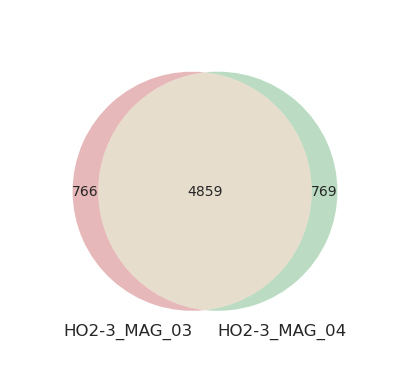

In [215]:
venn_orthos('HO2-3_MAG_03', 'HO2-3_MAG_04', 
            orthogroup_counts)

### Code for multispecies circos plot

In [186]:
def fix_link(link_tuple):
    new_tuple = ('_'.join(link_tuple[0].split('_')[:-1]),
                 link_tuple[1],
                 link_tuple[2])
    return new_tuple

In [187]:
# def draw_link(genome_gff_list, orthogroups, with_function=False):
#     '''
#     link orthogroups across genomes
#     '''
#     for _gff in genome_gff_list:
        

In [188]:
def get_single_ortho_links(ortho_id, gene2ortho, gff):
    '''
    gets a list [(s1, start, end) ... (sN, start, end)]
    for each gene in an orthogroup
    note: s1 is CONTIG Id, not gene ID
    '''
    genes = set(gene2ortho[gene2ortho.eq(ortho_id)].index)
    records = list(set([(r.seqid, r.start, r.end) for r in gff.all_records if r.attrs['ID'][0].split(':')[0] in genes]))
    return records

In [189]:
def get_shared_orthos(orthogroup_counts, gff_list):
    '''
    get a list of orthogroups shared by a group of genomes
    '''
    # get shared genes
    orthos = orthogroup_counts.loc[:, [g.name for g in gff_list]]
    # get orthos present in all genomes
    shared_orthos = orthos[(~orthos.isnull()).sum(1) == len(gff_list)].index
    return set(shared_orthos)

In [190]:
def get_orthogroup_links(ortho_list, gff_list, gene2ortho):
    '''
    get a nested list of genes for each orthogroup
    "link" = tuple (contig, gene_start, gene_stop)
    returns dict with N keys: N= len(ortho_list)
    each dict[N] = {genome: [list of links for genes in ortho]
    '''
    ortho_links = {}
    for i, s_o in enumerate(ortho_list):
        display(i)
        clear_output(wait=True)
        all_links = {}
        for g in gff_list:
            # gets a list [(s1, start, end) ... (sN, start, end)]
            # of genes in orthogroup for each genome in the list
            all_links[g.name] = get_single_ortho_links(s_o, gene2ortho, g)
        ortho_links[s_o] = all_links
        
    return ortho_links

In [191]:

def get_nonredundant_links(unpack_dict):
    '''
    get a list [((c1, start1, end1), (c2, start2, end2)),
                                  ...
                ((cX, start1, end1), (cY, start2, end2)),
    of non-redundant gene links for an orthogroup
    provided as unpack_dict,
    or get_all_links(core_orthos, gff_list)[core_orthos[i]]
    '''
    links = []
    already_linked = []

    for a, b in itertools.combinations([i for i in unpack_dict.values()], 2):
        for l1, l2 in itertools.product(a, b):
            if not any((l1[0] in a and l2[0] in a) for a in already_linked):
                links.append((l1, l2))
                already_linked.append((l1[0], l2[0]))
    return links

def get_finalized_links(ortho_set, gff_list, gene2ortho):
    # data structure containing "links" between genes in common orthogroups
    all_links = get_orthogroup_links(ortho_set, gff_list, gene2ortho)
    full_link_list = []
    for og in all_links.keys():
        full_link_list += get_nonredundant_links(all_links[og])
    return full_link_list

#### Other required data

In [192]:
# get interproscan name mapping to GO terms
interpro_go_data = pd.read_csv('/data/mhoffert/db/GO/interpro2go', sep=';', skiprows=6, header=None, names=['interpro_data', 'go'])
interpro_go_data['interpro_id'] = interpro_go_data['interpro_data'].apply(lambda x: x.split(':')[1].split(' ')[0])
interpro_go_data['go_annot'] = interpro_go_data['interpro_data'].apply(lambda x: x.split(' > GO:')[-1].rstrip())
interpro2go = interpro_go_data.set_index('interpro_id')['go']
interpro2go.head()

interpro_id
IPR000003     GO:0003677
IPR000003     GO:0003707
IPR000003     GO:0008270
IPR000003     GO:0006355
IPR000003     GO:0005634
Name: go, dtype: object

#### Get sets of orthogroups for various genomes

In [216]:
# get sets of genes
# list of gffs to plot in circos, clockwise
gff_list = [entero_gff, harb_gff, para_gff,  vuln_gff, gluc_gff]

# individual lists
para_orthos = get_shared_orthos(orthogroup_counts, [para_gff])
# 
harb_orthos = get_shared_orthos(orthogroup_counts, [harb_gff])
# 
vuln_orthos = get_shared_orthos(orthogroup_counts, [vuln_gff])
# 
entero_orthos = get_shared_orthos(orthogroup_counts, [entero_gff])
#
gluc_orthos = get_shared_orthos(orthogroup_counts, [gluc_gff])


# # list of orthogroups shared by all genomes
core_orthos = get_shared_orthos(orthogroup_counts, gff_list)
assert para_orthos & harb_orthos & entero_orthos & vuln_orthos & gluc_orthos == core_orthos

#shared by only enterobacteria
enterobact_orthos = (entero_orthos & vuln_orthos) - para_orthos - harb_orthos
assert len(enterobact_orthos & core_orthos) ==  0, 'should not share with core'

# shared by only lactobacilli
lacto_orthos = (harb_orthos & para_orthos) - entero_orthos - vuln_orthos
assert len(lacto_orthos & core_orthos) ==  0, 'should not share with core'

# "hops" = harb + entero
hopped_orthos = (harb_orthos & entero_orthos & gluc_orthos) - vuln_orthos - para_orthos
assert len(hopped_orthos & core_orthos) ==  0, 'should not share with core'
assert len(hopped_orthos & vuln_orthos) ==  0, 'should not share with vuln'

# "unhopped" = para + vuln
unhopped_orthos = (para_orthos & vuln_orthos) - harb_orthos - entero_orthos
assert len(unhopped_orthos & core_orthos) ==  0, 'should not share with core'

(0,) (6, 7.2)
(1,) (3.9, 7.2)
(2,) (3.9, 2.8)
(3,) (6, 2.8)
(0, 1) (5.0, 6.8)
(2, 3) (5.0, 3.2)
(0, 3) (6.8, 5)
(1, 2) (3.2, 5)
(0, 1, 2, 3) (5.0, 5.0)


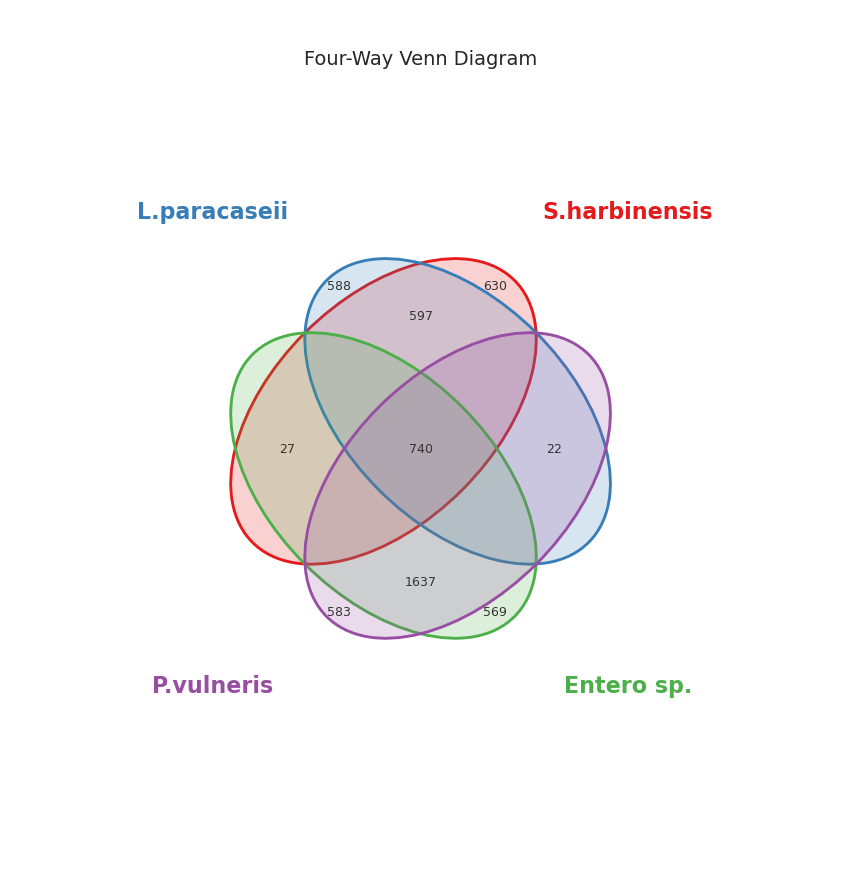

In [217]:

# --- Define your four sets here ---

# Compute all 15 non-empty intersections for annotation
sets = [harb_orthos, para_orthos, entero_orthos, vuln_orthos]
labels = ["S.harbinensis", "L.paracaseii", "Entero sp.", "P.vulneris"]


def label_for(indices):
    result = sets[indices[0]].copy()
    for i in indices[1:]:
        result &= sets[i]
    # Subtract elements that belong to sets NOT in this group
    for j in range(4):
        if j not in indices:
            result -= sets[j]
    return len(result)

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect("equal")
ax.axis("off")

colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]
alphas = 0.2

# Four overlapping ellipses (classic 4-set layout with rotated ellipses)
ellipses = [
    dict(xy=(4.5, 5.5), width=5, height=3, angle=45),
    dict(xy=(5.5, 5.5), width=5, height=3, angle=-45),
    dict(xy=(4.5, 4.5), width=5, height=3, angle=-45),
    dict(xy=(5.5, 4.5), width=5, height=3, angle=45),
]

for i, (e, color) in enumerate(zip(ellipses, colors)):
    ell = Ellipse(**e, facecolor=color, edgecolor=color,
                  linewidth=2, alpha=alphas)
    ax.add_patch(ell)
    ell2 = Ellipse(**e, facecolor="none", edgecolor=color, linewidth=2)
    ax.add_patch(ell2)

# Label positions for each set name
name_positions = [(7.8, 8.2), (2.2, 8.2), (7.8, 1.8), (2.2, 1.8)]
for i, (pos, color) in enumerate(zip(name_positions, colors)):
    ax.text(*pos, labels[i], fontsize=16, fontweight="bold",
            color=color, ha="center", va="center")

# Annotate region counts (approximate manual positions for a 4-ellipse layout)
region_positions = {
    (0,):        (6, 7.2), # harb
    (1,):        (3.9, 7.2), # para
    (2,):        (3.9, 2.8), # vuln
    (3,):        (6, 2.8), # entero
    (0,1):       (5.0, 6.8),
#     (0,2):       (3.0, 5.0),
#     (1,3):       (7.0, 5.0),
    (2,3):       (5.0, 3.2),
    (0,3):       (6.8, 5),
    (1,2):       (3.2, 5),
#     (0,1,2):     (4.5, 6.5),
#     (0,1,3):     (5.5, 6.5),
#     (0,2,3):     (4.5, 3.5),
#     (1,2,3):     (5.5, 3.5),
    (0,1,2,3):   (5.0, 5.0),
}

for idx, pos in region_positions.items():
    print(idx, pos)
    count = label_for(idx)
    ax.text(*pos, str(count), fontsize=9, ha="center", va="center", color="#333333")

ax.set_title("Four-Way Venn Diagram", fontsize=14, pad=10)
plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/venn4.png", dpi=150, bbox_inches="tight")
plt.show()
# print("Saved venn4.png")

In [250]:
hopped_orthos = (harb_orthos & entero_orthos) - vuln_orthos - para_orthos


In [251]:
hopped_orthos

{'OG0000503',
 'OG0001269',
 'OG0001278',
 'OG0001293',
 'OG0001300',
 'OG0001519',
 'OG0001551',
 'OG0002034',
 'OG0002041',
 'OG0002192',
 'OG0002378',
 'OG0002393',
 'OG0002398',
 'OG0003259',
 'OG0003601',
 'OG0003606',
 'OG0003611'}

In [282]:
import skbio

In [283]:
skbio.__version__

'0.5.6'

In [252]:
for og in hopped_orthos:
    genes = gene2ortho[gene2ortho.eq(og)]
    matches = [r for g in gff_list for r in g.all_records if r.attrs["ID"][0].split(':')[0] in genes.index]
    match_dict = {}
    for m in matches:
        gene_id = m.attrs['ID'][0].split(':')[0]
        
        if gene_id in match_dict.keys():
            match_dict[gene_id].append(m.attrs['Name'][0])
        else:
            match_dict[gene_id] = []
            
    print('-'*80)
    print(f'OG: {og}')
    for k, item in match_dict.items():
        print(mag2species.loc[gene2genome.loc[k]])
        print(f'{k}:\n', '\t'+'\n\t'.join(list(set(item))))
    print('-'*80)

--------------------------------------------------------------------------------
OG: OG0002041
s__
NODE_6_length_391301_cov_103.587712_25:
 	PHAGE-RELATED PROTEIN YOBO-RELATED
	PECTIN LYASE-RELATED
	Glycosyl hydrolases family 28
	-
	pbh1
s__Schleiferilactobacillus harbinensis
NODE_101_length_45678_cov_478.505732_17:
 	-
	Glycosyl hydrolases family 28
	EXOPOLYGALACTURONASE X-1-RELATED
s__Schleiferilactobacillus harbinensis
NODE_60_length_77636_cov_480.933102_42:
 	PHAGE-RELATED PROTEIN YOBO-RELATED
	Pectin lyase-like
	PECTIN LYASE-RELATED
	Glycosyl hydrolases family 28
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
OG: OG0001293
s__
NODE_78_length_93585_cov_156.386710_55:
 	Iron-containing alcohol dehydrogenases signature 2.
	PDDH
	ALCOHOL DEHYDROGENASE 4
	ALCOHOL DEHYDROGENASE
	Iron-containing alcohol dehydrogenases signature 1.
	lactal_redase: lactaldehyde reductase
	Iron

#### Gapseq-based analysis

In [56]:
go_descs = interpro_go_data.set_index('go')['go_annot']

In [38]:
metacyc_pwys = pd.read_csv('/data/mhoffert/tools/gapseq/dat/meta_pwy.tbl', sep='\t')

In [39]:
repstr = '|THINGS|,|FRAMES|,|Generalized-Reactions|,|Pathways|,'
metacyc_pwys['parsed_h'] = metacyc_pwys['hierarchy'].apply(lambda x: x.replace(repstr, '').lstrip('|').rstrip('|').split('|,|'))

In [40]:
metacyc_pwys.head(2)

,id,name,altname,hierarchy,taxrange,reaId,reaEc,keyRea,reaName,reaNr,ecNr,superpathway,status,spont,parsed_h
0,|12DICHLORETHDEG-PWY|,"1,2-dichloroethane degradation","1,2-dichloroethane degradation","|THINGS|,|FRAMES|,|Generalized-Reactions|,|Pat...",|TAX-2|,"DHLAXANAU-RXN,MOXXANAU-RXN,ALDXANAU-RXN,DHLBXA...","3.8.1.5,1.1.2.7,1.2.1.4,3.8.1.3",DHLAXANAU-RXN,"1,2-dichloroethane dehalogenase;2-chloroethano...",4,4,False,True,NaN,"[Degradation, CHLORINATED-COMPOUNDS-DEG]"
1,|14DICHLORBENZDEG-PWY|,"1,4-dichlorobenzene degradation","1,4-dichlorobenzene degradation","|CHLORINATED-COMPOUNDS-DEG|,|THINGS|,|FRAMES|,...",|TAX-1224|,"DIOXYXANFL-RXN,CHLOROBENDDH-RXN,CHLOROCATDIOXY...","1.14.12.26,1.3.1.119,1.13.11.M6,3.1.1.45,1.3.1...","DIOXYXANFL-RXN,CHLOROBENDDH-RXN","1,4-dichlorobenzene dioxygenase;1,4-dichlorobe...",9,7,False,True,"RXN-18361,RXN-18362","[CHLORINATED-COMPOUNDS-DEG, Degradation, AROMA..."


In [41]:
metacyc_pwys['h_1'] = metacyc_pwys['parsed_h'].apply(lambda x: x[0])
metacyc_pwys['h_2'] = metacyc_pwys['parsed_h'].apply(lambda x: x[1] if len(x) > 1 else x[-1])
metacyc_pwys['h_3'] = metacyc_pwys['parsed_h'].apply(lambda x: x[2] if len(x) > 2 else x[-1])
metacyc_pwys['h_4'] = metacyc_pwys['parsed_h'].apply(lambda x: x[3] if len(x) > 3 else x[-1])

In [42]:
metacyc_pwys['h_3'].value_counts()

PHENYLPROPANOID-SYN                  166
SECONDARY-METABOLITE-BIOSYNTHESIS    146
Toxin-Biosynthesis                   133
AROMATIC-COMPOUNDS-DEGRADATION       118
Terpenoid-Biosynthesis               117
                                    ... 
Fermentation-to-Lactate                1
PHYTOALEXIN-SYN                        1
LYSINE-DEG                             1
Hydrogen-Sulfide-Biosynthesis          1
MANDELATE-DEG                          1
Name: h_3, Length: 252, dtype: int64

In [43]:
entero_pwys = pd.read_csv('./../mag_pipeline/derep_mags/gapseq_test/UO5-1_MAG_02_protein-all-Pathways.tbl', sep='\t', skiprows=3)

In [44]:
harb_pwys = pd.read_csv('./../mag_pipeline/derep_mags/gapseq_test/HO2-3_MAG_04_protein-all-Pathways.tbl', sep='\t', skiprows=3)
harb_pwys.head(2)

,ID,Name,Prediction,Completeness,VagueReactions,KeyReactions,KeyReactionsFound,ReactionsFound
0,|12DICHLORETHDEG-PWY|,"1,2-dichloroethane degradation",False,25,0,1,0,ALDXANAU-RXN
1,|14DICHLORBENZDEG-PWY|,"1,4-dichlorobenzene degradation",False,14,0,2,0,MALEYLACETATE-REDUCTASE-RXN


In [45]:
harb_pwydf = pd.merge(harb_pwys, metacyc_pwys, left_on='ID', right_on='id', how='inner')
entero_pwydf = pd.merge(entero_pwys, metacyc_pwys, left_on='ID', right_on='id', how='inner')

In [46]:
harb_plotdf =harb_pwydf[harb_pwydf['Prediction']].groupby(['h_1', 'h_2']).count().reset_index().iloc[:, :3]
entero_plotdf = entero_pwydf[entero_pwydf['Prediction']].groupby(['h_1', 'h_2']).count().reset_index().iloc[:, :3]

In [47]:
plotdf = pd.concat([harb_plotdf.assign(species='harb'), entero_plotdf.assign(species='entero')])
plotdf

,h_1,h_2,ID,species
0,Biosynthesis,Amino-Acid-Biosynthesis,5,harb
1,Biosynthesis,Carbohydrates-Biosynthesis,8,harb
2,Biosynthesis,Cell-Structure-Biosynthesis,1,harb
3,Biosynthesis,Lipid-Biosynthesis,2,harb
4,Biosynthesis,Nucleotide-Biosynthesis,7,harb
...,...,...,...,...
69,SECONDARY-METABOLITE-DEGRADATION,Sugar-Derivatives,8,entero
70,Sulfur-Metabolism,Degradation,1,entero
71,Tetrapyrrole-Biosynthesis,Porphyrin-Compounds-Biosynthesis,3,entero
72,Vitamin-Biosynthesis,Biosynthesis,17,entero


/data/mhoffert/miniconda3/envs/beer_metagenomics/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)




In [48]:
sns.catplot(data=plotdf,
            row='h_1', x='h_2', y='ID', hue='species', kind='bar', sharex=False)

In [51]:
def match_dict_to_df(match_dict):
    df =pd.concat(pd.DataFrame(match_dict[g]).assign(gene=g) for g in match_dict.keys())
    df = df[~df.interpro.eq('-')]
    # df = pd.Series(match_dict).apply(lambda x: pd.Series(data=x)).stack().reset_index()
    # df = df.drop('level_1', axis=1).rename(columns={'level_0':'gene', 0:'interpro'})
    # # df['go'] = df['interpro'].map(interpro2go)
    return df

In [52]:
# merging orthogroup identities with gene annotations

all_matches = []
for og in hopped_orthos:
    # get IDs of genes in orthogroup
    genes = gene2ortho[gene2ortho.eq(og)]
    # get gene IDs
    matches = [r for g in gff_list for r in g.all_records if r.attrs["ID"][0].split(':')[0] in genes.index]
    # get annotations of genes
    match_dict = {}
    for m in matches:
        gene_id = m.attrs['ID'][0].split(':')[0]
        if gene_id in match_dict.keys():
            match_dict[gene_id]['interpro'].append(m.attrs['Ontology_term'][0])
            match_dict[gene_id]['desc'].append(m.attrs['interpro_desc'][0])
        else:
            match_dict[gene_id] = {'interpro':[], 'desc':[]}
    # format matches
    temp = match_dict_to_df(match_dict)
    # add GO data
    match_annots = pd.merge(temp, interpro_go_data[['interpro_id', 'go', 'go_annot']], how='inner', 
         left_on='interpro', right_on='interpro_id').assign(orthogroup=og)
    
    all_matches.append(match_annots)
    # # for key, item in match_dict.items():
    # # match_dict[key] = [i for i in set(item) if not i == '-']
    # print('-'*80)
    # for k, item in match_dict.items():
    #     print(f'{key}:\n', '\t'+'\n\t'.join(match_dict[item]['names']))
    # print('-'*80)

all_matches = pd.concat(all_matches)

In [53]:
all_matches.sort_values(['go', 'gene']).head()

,interpro,desc,gene,interpro_id,go,go_annot,orthogroup
46,IPR012712,HTH-type transcriptional regulator HpaR/FarR,NODE_26_length_210358_cov_154.326900_184,IPR012712,GO:0003677,DNA binding,OG0001519
34,IPR000835,MarR-type HTH domain,NODE_11_length_292332_cov_345.902770_65,IPR000835,GO:0003700,DNA-binding transcription factor activity,OG0001519
36,IPR000835,MarR-type HTH domain,NODE_11_length_292332_cov_345.902770_65,IPR000835,GO:0003700,DNA-binding transcription factor activity,OG0001519
38,IPR000835,MarR-type HTH domain,NODE_11_length_292332_cov_345.902770_65,IPR000835,GO:0003700,DNA-binding transcription factor activity,OG0001519
40,IPR000835,MarR-type HTH domain,NODE_11_length_292332_cov_345.902770_65,IPR000835,GO:0003700,DNA-binding transcription factor activity,OG0001519


In [54]:
plotdf = all_matches.groupby(['gene', 'interpro']).first().sort_values('go').reset_index()
plotdf.head()

,gene,interpro,desc,interpro_id,go,go_annot,orthogroup
0,NODE_26_length_210358_cov_154.326900_184,IPR012712,HTH-type transcriptional regulator HpaR/FarR,IPR012712,GO:0003677,DNA binding,OG0001519
1,NODE_11_length_292332_cov_345.902770_65,IPR000835,MarR-type HTH domain,IPR000835,GO:0003700,DNA-binding transcription factor activity,OG0001519
2,NODE_26_length_210358_cov_154.326900_184,IPR000835,MarR-type HTH domain,IPR000835,GO:0003700,DNA-binding transcription factor activity,OG0001519
3,NODE_68_length_101680_cov_139.397609_51,IPR000835,MarR-type HTH domain,IPR000835,GO:0003700,DNA-binding transcription factor activity,OG0001519
4,NODE_99_length_47719_cov_340.002077_46,IPR000835,MarR-type HTH domain,IPR000835,GO:0003700,DNA-binding transcription factor activity,OG0001519


<Axes: xlabel='go'>

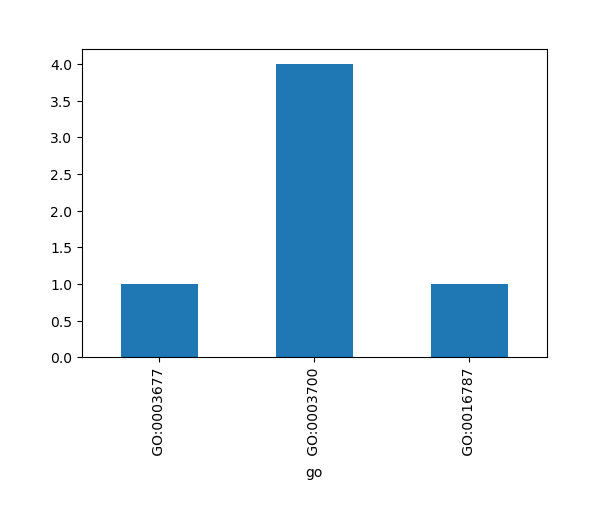

In [55]:
fig, ax = plt.subplots(figsize=(6,4))
plotdf.groupby('go').count()['gene'].plot(kind='bar')

In [67]:
'''
preprocessing of gffs and link
'''

lacto_links = get_finalized_links(lacto_orthos, gff_list, gene2ortho)
print('Lacto links:', len(lacto_links))

enterobact_links = get_finalized_links(enterobact_orthos, gff_list, gene2ortho)
print('Enterobact links:', len(enterobact_links))

unhopped_links = get_finalized_links(unhopped_orthos, gff_list, gene2ortho)
print('unhopped links:', len(unhopped_links))

# hopped_links = get_finalized_links(hopped_orthos, gff_list, gene2ortho)
# print('hopped links:', len(hopped_links))

# core_links = get_finalized_links(core_orthos, gff_list, gene2ortho)
# print('core links:', len(core_links))

unhopped links: 38


In [254]:
def circos_n_genomes(genome_gff_list, flips):
    all_sectors = {}
    split = np.linspace(1e-6, 1, len(genome_gff_list)+1)
    for i, _gff in enumerate(genome_gff_list):
        _list = sorted(_gff.get_seqid2size().items(), key=lambda item: int(item[1]))
        if flips[i]:
            _list = _list[::-1]
        scaled_dict = dict(_list)
        # scaled_dict = (pd.Series(scaled_dict) / pd.Series(scaled_dict).sum()).to_dict()
        # mms = MinMaxScaler((1, 100))
        # scaled_vals = mms.fit_transform(pd.Series(scaled_dict).values.reshape(-1, 1))
        # scaled_dict = pd.Series(data=scaled_vals.reshape(1, -1)[0], 
        #                         index=pd.Series(scaled_dict).index).to_dict()
        all_sectors.update(scaled_dict)
        
    # all_sectors = (pd.Series(all_sectors) / pd.Series(all_sectors).sum()).to_dict()
    # all_sectors['all'] = pd.Series(all_sectors).sum()
    # mms = MinMaxScaler((1e-6, 1))
    # all_sectors = pd.Series(data=mms.reshape(1, -1)[0], index=pd.Series(all_sectors).index).to_dict()
    circos = Circos(sectors=all_sectors,
                start=-358,
        end=2,
        space=0.5)
    return circos, all_sectors
        # sector2clockwise={seqid: False for seqid in harb_gff.get_seqid2size().keys()})

In [255]:
def draw_links(circos, track, sector, links, rect_color, draw_links=True):
    
    for link in links:
        gate = False
        # if not link in full_link_list:
        if link[0][0] == sector.name:
            gate=True
            track.rect(link[0][1], link[0][2], color=rect_color)
        if link[1][0] == sector.name:
            gate = True
            track.rect(link[1][1], link[1][2], color=rect_color)
        
        if gate and draw_links:
            circos.link(link[0], link[1], 
                        r1=track.r_lim[0]-1, r2=track.r_lim[0]-1, 
                        alpha=0.5, color=rect_color)
    return circos

In [256]:
%%time
c, all_sectors = circos_n_genomes([entero_gff, harb_gff, para_gff,  vuln_gff, gluc_gff],
                                 flips=[True, True, True, True, True])

min_r_pos = 100
for sector in c.sectors:
    
    # contig_track = sector.add_track((95, 99))
    # contig_track.axis(fc="gray", ec="none", alpha=0.7) 
    
    # black ring
    track = sector.add_track((99, 100))
    track.axis(fc="black", ec='black')
    
    # track for orthogroups
    gene_track = sector.add_track((95, 99))
    gene_track.axis(fc="white", ec='white')

    rect_color = 'lightgray'
    for link in core_links:
        if link[0][0] == sector.name:
            gene_track.rect(link[0][1], link[0][2], color=rect_color)
        if link[1][0] == sector.name:
            gene_track.rect(link[1][1], link[1][2], color=rect_color)
            
    # track for orthogroups
    taxa_track = sector.add_track((90, 95))
    taxa_track.axis(fc="white", ec='white')

    rect_color = mpl.colors.to_rgba('#3b719f')
    draw_links(c, taxa_track, sector, lacto_links, rect_color, False)
            
    rect_color = mpl.colors.to_rgba('#d3494e')
    draw_links(c, taxa_track, sector, enterobact_links, rect_color, False)
    
    # hop_track = sector.add_track((80, 85))
    # hop_track.axis(fc="white", ec='white')
    
    rect_color = mpl.colors.to_rgba('#287c37')
    draw_links(c, taxa_track, sector, unhopped_links, rect_color)
    
    rect_color = mpl.colors.to_rgba('#e17701')
    draw_links(c, taxa_track, sector, hopped_links, rect_color)
    
    # track for orthogroups

    # for link in enterobact_links:
    #     gate = False
    #     # if not link in full_link_list:
    #     if link[0][0] == sector.name:
    #         gate=True
    #         lacto_track.rect(link[0][1], link[0][2], color=rect_color)
    #     if link[1][0] == sector.name:
    #         gate = True
    #         lacto_track.rect(link[1][1], link[1][2], color=rect_color)
    #     if gate:
    #         c.link(link[0], link[1], r1=89, r2=89, alpha=0.5, color=rect_color)

fig1 = c.plotfig()



NameError: name 'core_links' is not defined

In [219]:
# "hops" = harb + entero
hopped_orthos = (harb_orthos & entero_orthos & gluc_orthos) - vuln_orthos - para_orthos
assert len(hopped_orthos & core_orthos) ==  0, 'should not share with core'
assert len(hopped_orthos & vuln_orthos) ==  0, 'should not share with vuln'

In [220]:
for og in hopped_orthos:
    genes = gene2ortho[gene2ortho.eq(og)]
    matches = [r for g in gff_list for r in g.all_records if r.attrs["ID"][0].split(':')[0] in genes.index]
    match_dict = {}
    for m in matches:
        gene_id = m.attrs['ID'][0].split(':')[0]
        
        if gene_id in match_dict.keys():
            match_dict[gene_id].append(m.attrs['Name'][0])
        else:
            match_dict[gene_id] = []
            
    print('-'*80)
    print(f'OG: {og}')
    for k, item in match_dict.items():
        print(mag2species.loc[gene2genome.loc[k]])
        print(f'{k}:\n', '\t'+'\n\t'.join(list(set(item))))
    print('-'*80)

--------------------------------------------------------------------------------
OG: OG0000503
s__
NODE_78_length_93585_cov_156.386710_69:
 	alpha/beta hydrolase fold
	alpha/beta-Hydrolases
	alpha/beta hydrolase
s__Schleiferilactobacillus harbinensis
NODE_97_length_48061_cov_496.035100_29:
 	CARBOXYLESTERASE 18-RELATED
	ARYLACETAMIDE DEACETYLASE
	alpha/beta-Hydrolases
	alpha/beta hydrolase
s__Gluconobacter_A japonicus
NODE_4_length_450692_cov_331.774510_19:
 	AB HYDROLASE SUPERFAMILY PROTEIN C4A8.06C
	alpha/beta-Hydrolases
	alpha/beta hydrolase
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
OG: OG0001519
s__
NODE_26_length_210358_cov_154.326900_184:
 	Bacterial regulatory protein MarR family signature
	4-HYDROXYPHENYLACETATE CATABOLISM PROTEIN
	-
	MarR family
	MarR-type HTH domain signature.
	TRANSCRIPTIONAL REGULATOR
	HpaR: homoprotocatechuate degradation operon regulator

In [221]:
orthogroup_counts.loc['OG0001519', :].rename(index=mag2species)

s__Pantoea agglomerans                    NaN
s__Pseudescherichia vulneris              NaN
s__                                       2.0
s__Gluconobacter_A japonicus              1.0
s__Levilactobacillus brevis               NaN
s__Schleiferilactobacillus harbinensis    1.0
s__Lentilactobacillus parabuchneri        NaN
s__Lacticaseibacillus paracasei           NaN
Name: OG0001519, dtype: float64

In [222]:
marr_genes = gene2ortho[gene2ortho.eq('OG0001519')]
marr_genes

NODE_11_length_292332_cov_345.902770_65     OG0001519
NODE_26_length_210358_cov_154.326900_184    OG0001519
NODE_68_length_101680_cov_139.397609_51     OG0001519
NODE_99_length_47719_cov_340.002077_46      OG0001519
dtype: object

In [223]:
ab_genes = gene2ortho[gene2ortho.eq('OG0000503')]
ab_genes

NODE_123_length_41560_cov_182.547621_38    OG0000503
NODE_12_length_239280_cov_163.895053_37    OG0000503
NODE_155_length_30806_cov_189.328412_1     OG0000503
NODE_24_length_211943_cov_16.931327_181    OG0000503
NODE_39_length_116398_cov_23.078853_10     OG0000503
NODE_4_length_450692_cov_331.774510_19     OG0000503
NODE_78_length_93585_cov_156.386710_69     OG0000503
NODE_97_length_48061_cov_496.035100_29     OG0000503
dtype: object

In [224]:
print(gene2genome.loc[marr_genes.index])
print(gene2genome.loc[marr_genes.index].map(mag2species))

NODE_11_length_292332_cov_345.902770_65     HI4-3_MAG_04
NODE_26_length_210358_cov_154.326900_184    UO5-1_MAG_02
NODE_68_length_101680_cov_139.397609_51     UO5-1_MAG_02
NODE_99_length_47719_cov_340.002077_46      HO2-3_MAG_04
dtype: object
NODE_11_length_292332_cov_345.902770_65               s__Gluconobacter_A japonicus
NODE_26_length_210358_cov_154.326900_184                                       s__
NODE_68_length_101680_cov_139.397609_51                                        s__
NODE_99_length_47719_cov_340.002077_46      s__Schleiferilactobacillus harbinensis
dtype: object


In [225]:
len(gene2genome)

14726

In [226]:
for gene in ab_genes.index:
    try: 
        print(gene2genome.loc[gene])
        print(gene2genome.loc[[gene]].map(mag2species))
    except KeyError:
        print('from another genome')

from another genome
from another genome
from another genome
from another genome
from another genome
HI4-3_MAG_04
NODE_4_length_450692_cov_331.774510_19    s__Gluconobacter_A japonicus
dtype: object
UO5-1_MAG_02
NODE_78_length_93585_cov_156.386710_69    s__
dtype: object
HO2-3_MAG_04
NODE_97_length_48061_cov_496.035100_29    s__Schleiferilactobacillus harbinensis
dtype: object


from pygenomeviz import GenomeViz
from pygenomeviz.utils import load_example_gff_file
## Plotting the locus of these genes

In [227]:
from pygenomeviz import GenomeViz
from pygenomeviz.utils import load_example_gff_file

In [228]:
from Bio import SeqIO

In [229]:
from collections import Counter

In [230]:
def gene2loc(fasta):
    ids = [r.description for r in SeqIO.parse(fasta, format='fasta')]
    seqs = [r.seq for r in SeqIO.parse(fasta, format='fasta')]
    return ids, seqs

def summarize_annotations(annotations, top_n=5):
    """
    annotations: list of lists, e.g. [['Formamidopyrimidine-DNA glycosylase'], ['DNA glycosylase/AP lyase', 'H2TH DNA-binding'], ...]
    Returns a concise summary string.
    """
    # Flatten, clean, drop placeholders
    flat = [a.strip() for group in annotations for a in group if a.strip() and a.strip() != '-']
    
    if not flat:
        return "Uncharacterized protein"
    
    counts = Counter(flat)
    
    # Prefer the annotation that looks like a full protein/family name
    # (heuristic: no "domain"/"finger"/"site" as a *second* fragment, i.e. it's a first element)
    primary_candidates = [group[0].strip() for group in annotations if group[0].strip() != '-']
    primary_counts = Counter(primary_candidates)
    primary_name = primary_counts.most_common(1)[0][0]
    
    # Collect distinct domain descriptors (excluding the primary name itself)
    domain_terms = [term for term in flat if term != primary_name]
    domain_counts = Counter(domain_terms)
    top_domains = [term for term, _ in domain_counts.most_common(top_n)]
    
    summary = f"{primary_name}"
    if top_domains:
        summary += f" ({', '.join(top_domains)})"
    return summary

In [243]:
matches = []
for genome in gene2genome.loc[marr_genes.index].unique():
    ids, seqs = gene2loc(f'./../mag_pipeline/derep_mags/{genome}_protein.faa')
    curr_matches = [ids[i] for i in range(len(ids)) if any(g in ids[i] for g in marr_genes.index)]
    matches += curr_matches
    fasta_str = '\n'.join([f'>{_id.split(" # ")[0]}\n{seqs[ids.index(_id)]}' for _id in curr_matches])
    print(fasta_str)


>NODE_11_length_292332_cov_345.902770_65
MRTQAPCLSIGFLATTTGRLFTRLMEQKLKPAGMRAGQIPVFLALGKGEILNQKYLAEFAGIEQPGMATLLARMERDGLIERETDPNDKRVSQIRLTSDGLMKSQKIIPIMEEASEEAFKGLTPLERDILITLLERMSSSLERCL
>NODE_26_length_210358_cov_154.326900_184
MHDSLTIALLQAREAAMGYFRPIVKRHNLTEQQWRIVRVLAEHPSMDFHDLAFRTCILRPSLTGILTRMERDGLVLRLKPVNDQRKLYVSLTKEGNALYQHAQAQVEEAYQQIEAEFTPEKMKQLTALLEEFIDLGNRHIAARDE
>NODE_68_length_101680_cov_139.397609_51
MELRHEAFHLLRQLFQQHTAQWQQALPELTKPQYAVMRSVAENPGIEQVALTEVAVSTKATLAEMLSRMESRGLVKREHDPADKRRRFVFLTPEGEALLESCKPVGNGVDEAFLGRLSKAEREQFSALIKKMMHD
>NODE_99_length_47719_cov_340.002077_46
MTPEIGRLLKIASNRLSWGLDQYARQHGLTGTQMSFLDFLYRRTTAGQVVLQRDIEQEFQIKRSTATQVLQTMETKGLITRQSAAQDARQKEVRLTAAAQDQVQLVRDYIEASDTKITAGYSAAEVRVITRFLQHIAELNKEENFD


In [232]:
matches = []
for genome in gene2genome.reindex(index=ab_genes.index).dropna().unique():
    ids, seqs = gene2loc(f'./../mag_pipeline/derep_mags/{genome}_protein.faa')
    curr_matches = [ids[i] for i in range(len(ids)) if any(g + ' ' in ids[i] for g in ab_genes.index)]
    matches += curr_matches
    fasta_str = '\n'.join([f'>{_id.split(" # ")[0]}\n{seqs[ids.index(_id)]}' for _id in curr_matches])
    print(fasta_str)

>NODE_4_length_450692_cov_331.774510_19
MNTLPLVLPELRPALDIFPSVDLSSETLPALRSALEDRAAQAFQTAEDFRVTLEQRHIPAGGDDERTIRLLTIRPTHTASSPRPVLLHLHGGGHCAGRPEQNTGDLCRFAQELNCLVISPDYRLTPETPFPGGIEDAYTTLCWIHDNAETLNIRRDQIGVTGESAGGNLAAALCLLARDRHGPAILFQNLIYPMLDDRTVNDAPNPSPTAGEFVWTRASNTYAWDILLTPSRPGDENISPYAAPARATDLSGLPPTIMTVGALDLFLEEDLLYAQRLIRSGVSVELDVVPGAYHAFDVTGAPIAKQTLERRITSMKRFFSPSED
>NODE_78_length_93585_cov_156.386710_69
MALENGIAQLVKDFIDAGRPSSREQNIDDRRKGYVASTVLAGKKEARVQIETRVIDDLTFQIYSPLNATETLPGALYFHGGCFVSGGFETHDNQLRQLAFYGNCRIVAVQYRLAPEHRFPAAHDDAERAATLVWQNAEVFGVNKNRITLCGDSAGGHLALVTALRIKANGLWNPAQLILIYPMLDATASFDSYILNGQDYIITRDTLLSGYEMYLADTDRQHPEASPLWRNDFNGLPPVHIITAEYDPLCDEGEMLYQHLAEQEVRCTAQRWQGVIHGFFQLGGISQSARDVMRDIAWRISSARR
>NODE_97_length_48061_cov_496.035100_29
MSTFWTPTMQTYYQQLQNLQDFSTVNQDQGVTRLDRRITAAPDGHFDPLIAAFEGHDPQPRVVHIQAPAHFSPQNDAQQQALAVRQAMGILNVNLAPTVTEETLSTAVPITVYQRPYAAQRQCLIFLHGGGFIGGSDAVVANFCKGLVDHSAGRLAVFNVNYRLAPEATLDDMQRDVDLAVRWVHDHAADYHAPADALAIGGDSAGATLALEAAYHDRVVNRHWLTHEILIYPLISFTARTEVWPLANY

ESM Atlas notes:
    The ESMC SAE feature similarity search (similarity scores ~0.90 across all 10 hits) converges on a highly consistent picture: these are bacterial carboxylesterases of the BD-FAE family, active on plant-derived ester substrates. Every neighboring cluster is 100% characterized, and two Pfam domains appear in every single member across all clusters queried — PF20434 (BD-FAE) and PF07859 (alpha/beta hydrolase fold) — with PF00135 (Carboxylesterase) covering 60–85% of members in each. Subsidiary hits to PF05448 (Acetyl xylan esterase, AXE1) and PF01738 (Dienelactone hydrolase) further support a role in hydrolysis of ester linkages in plant polysaccharides or aromatic acids like ferulic acid. The environmental sources — soil, permafrost, freshwater sediment, and poplar rhizosphere — are all habitats where bacterial decomposition of plant biomass is active, consistent with a lignocellulose-associated function.

In short, your orthogroup most likely encodes bacterial feruloyl/acetyl esterases (BD-FAE clade) that cleave ester bonds in plant cell wall polymers such as feruloylated hemicelluloses, as part of microbial biomass degradation in soil and aquatic environments.

Want to explore the programmatic API to run ESMC embeddings on the broader set of sequences from your assembly? You can do that at scale via the API on biohub.ai.



In [244]:
marr_locs = pd.DataFrame(columns=['start', 'stop', 'strand'])
for m in matches:
    marr_locs.loc[m.split(' # ')[0]] = pd.Series(index=['start', 'stop', 'strand'],
                                                 data=[int(i) for i in m.split(' # ')[1:4]])

In [245]:
marr_locs['genome'] = marr_locs.index.map(gene2genome)
marr_locs

,start,stop,strand,genome
NODE_11_length_292332_cov_345.902770_65,62859,63296,1,HI4-3_MAG_04
NODE_26_length_210358_cov_154.326900_184,191747,192184,1,UO5-1_MAG_02
NODE_68_length_101680_cov_139.397609_51,54889,55296,-1,UO5-1_MAG_02
NODE_99_length_47719_cov_340.002077_46,45870,46310,1,HO2-3_MAG_04


In [246]:
gff_dict = {'HO2-3_MAG_03':Gff("./../mag_pipeline/derep_mags/HO2-3_MAG_03.gff"),
            'HO2-3_MAG_04':Gff("./../mag_pipeline/derep_mags/HO2-3_MAG_04.gff"),
            'UO5-1_MAG_02':Gff("./../mag_pipeline/derep_mags/UO5-1_MAG_02.gff"),
            'UO5-1_MAG_01':Gff("./../mag_pipeline/derep_mags/UO5-1_MAG_01.gff"),
            'HI4-3_MAG_04':Gff("./../mag_pipeline/derep_mags/HI4-3_MAG_04.gff"),}

NODE_11_length_292332_cov_345.902770_65 start            62859
stop             63296
strand               1
genome    HI4-3_MAG_04
Name: NODE_11_length_292332_cov_345.902770_65, dtype: object
195
NODE_26_length_210358_cov_154.326900_184 start           191747
stop            192184
strand               1
genome    UO5-1_MAG_02
Name: NODE_26_length_210358_cov_154.326900_184, dtype: object
173
NODE_68_length_101680_cov_139.397609_51 start            54889
stop             55296
strand              -1
genome    UO5-1_MAG_02
Name: NODE_68_length_101680_cov_139.397609_51, dtype: object
207
NODE_99_length_47719_cov_340.002077_46 start            45870
stop             46310
strand               1
genome    HO2-3_MAG_04
Name: NODE_99_length_47719_cov_340.002077_46, dtype: object
159


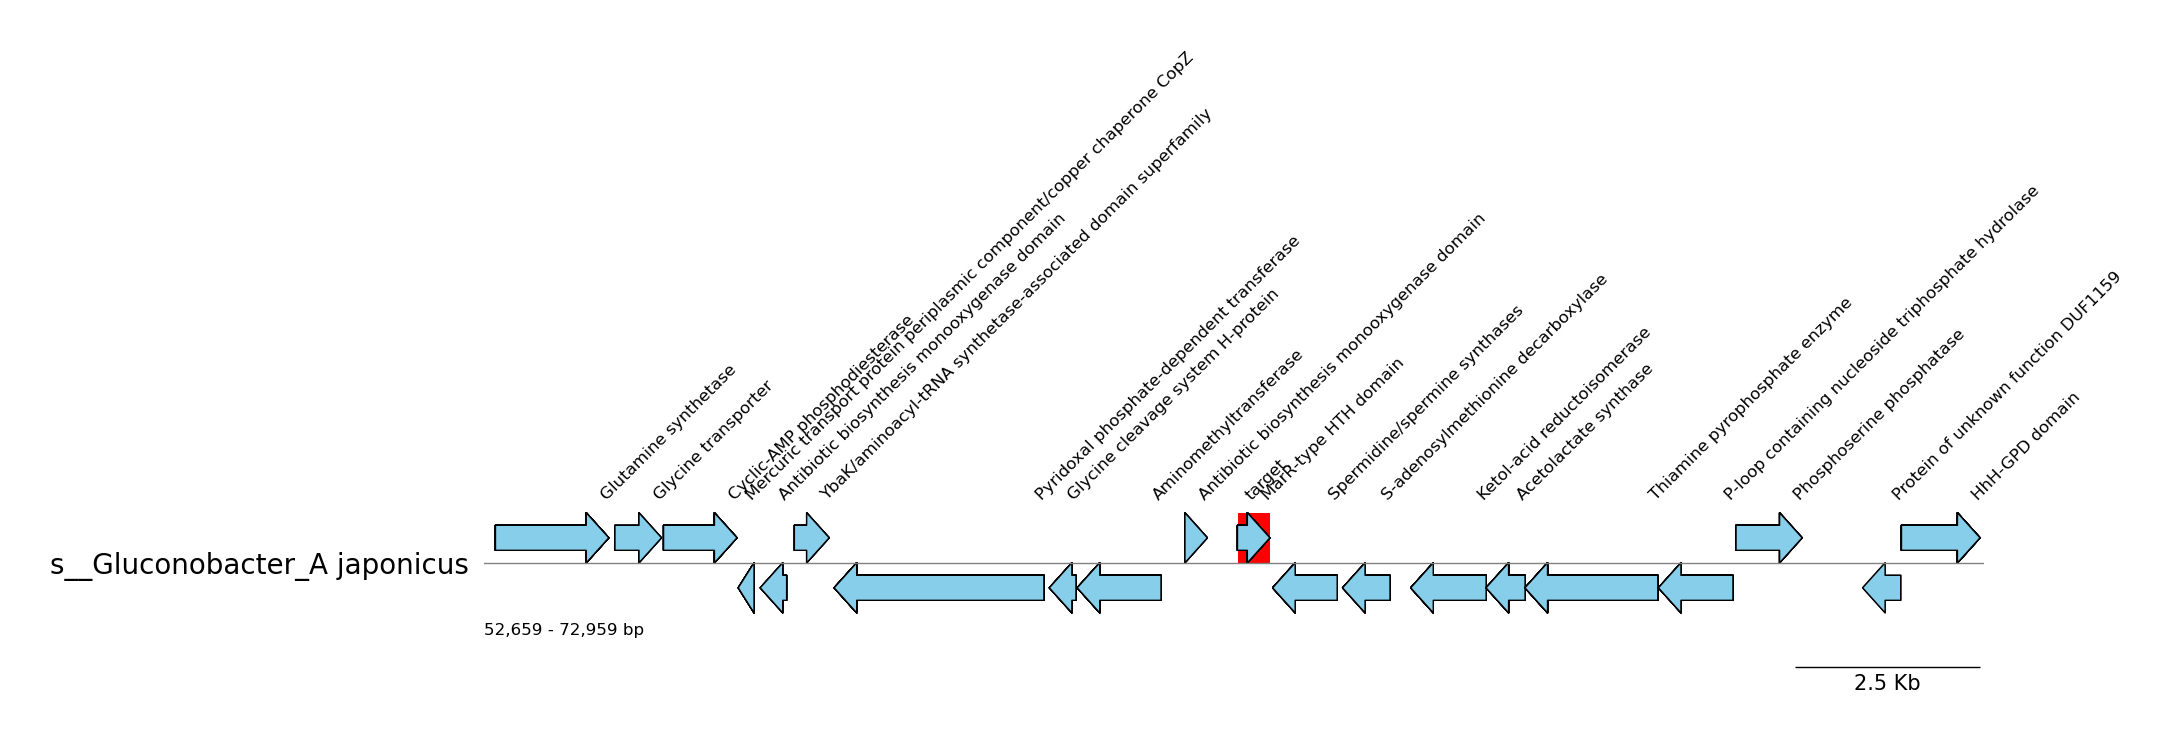

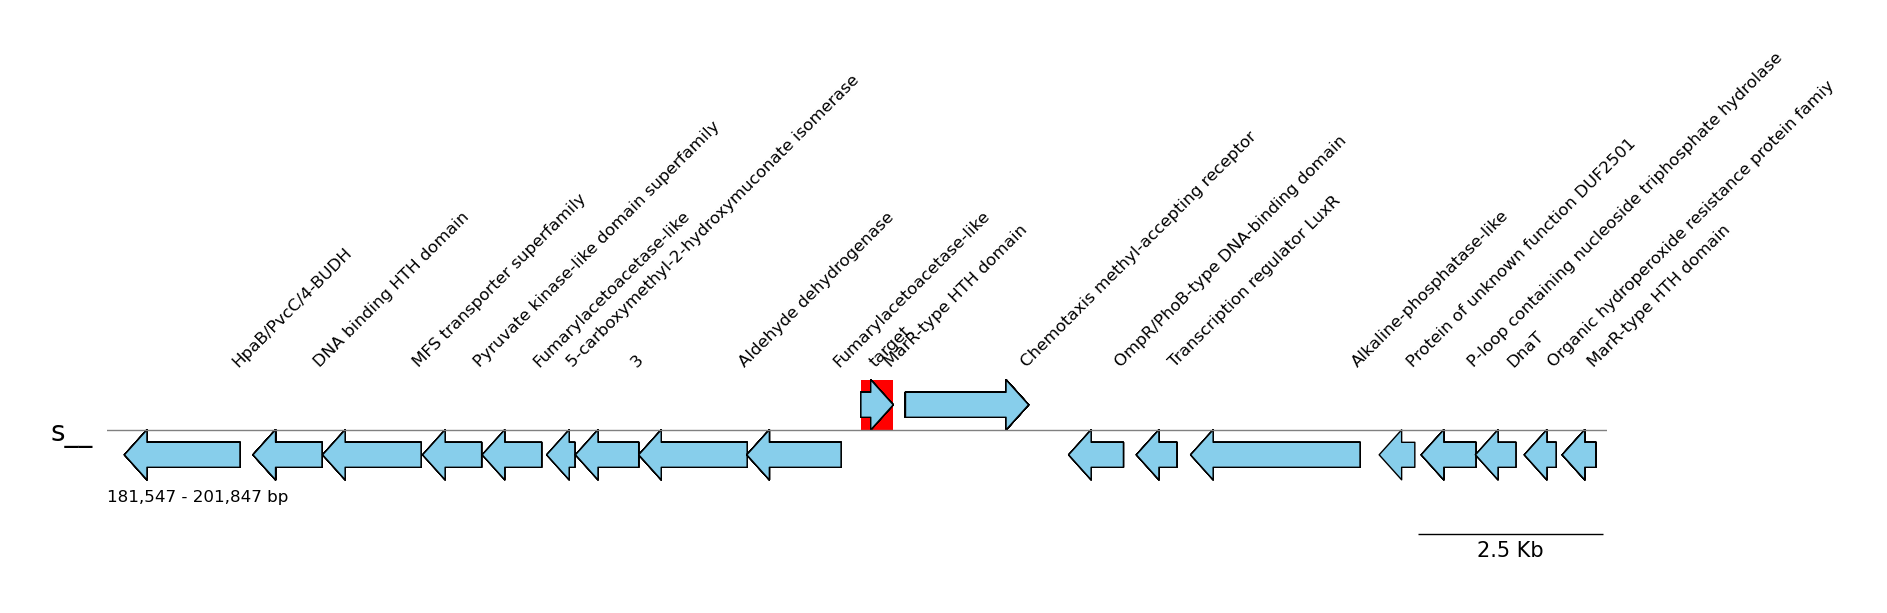

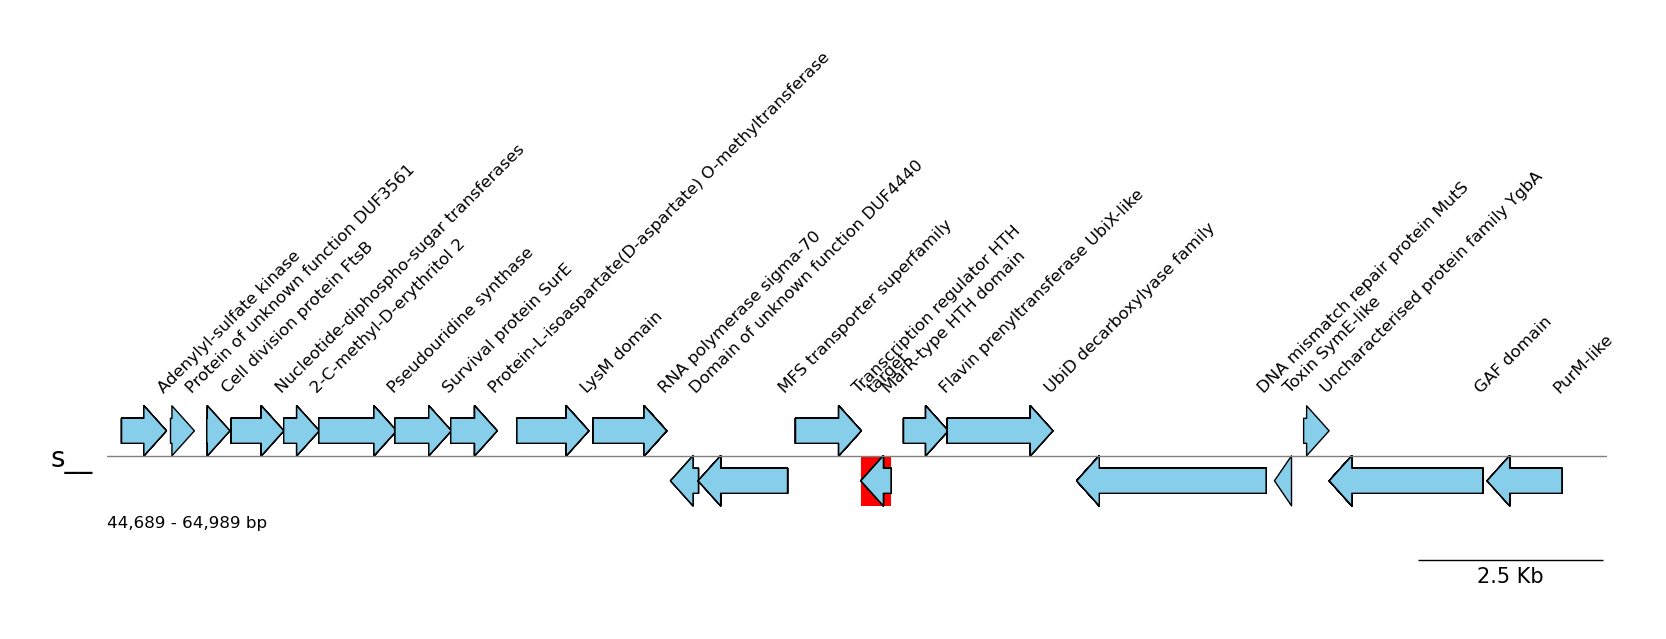

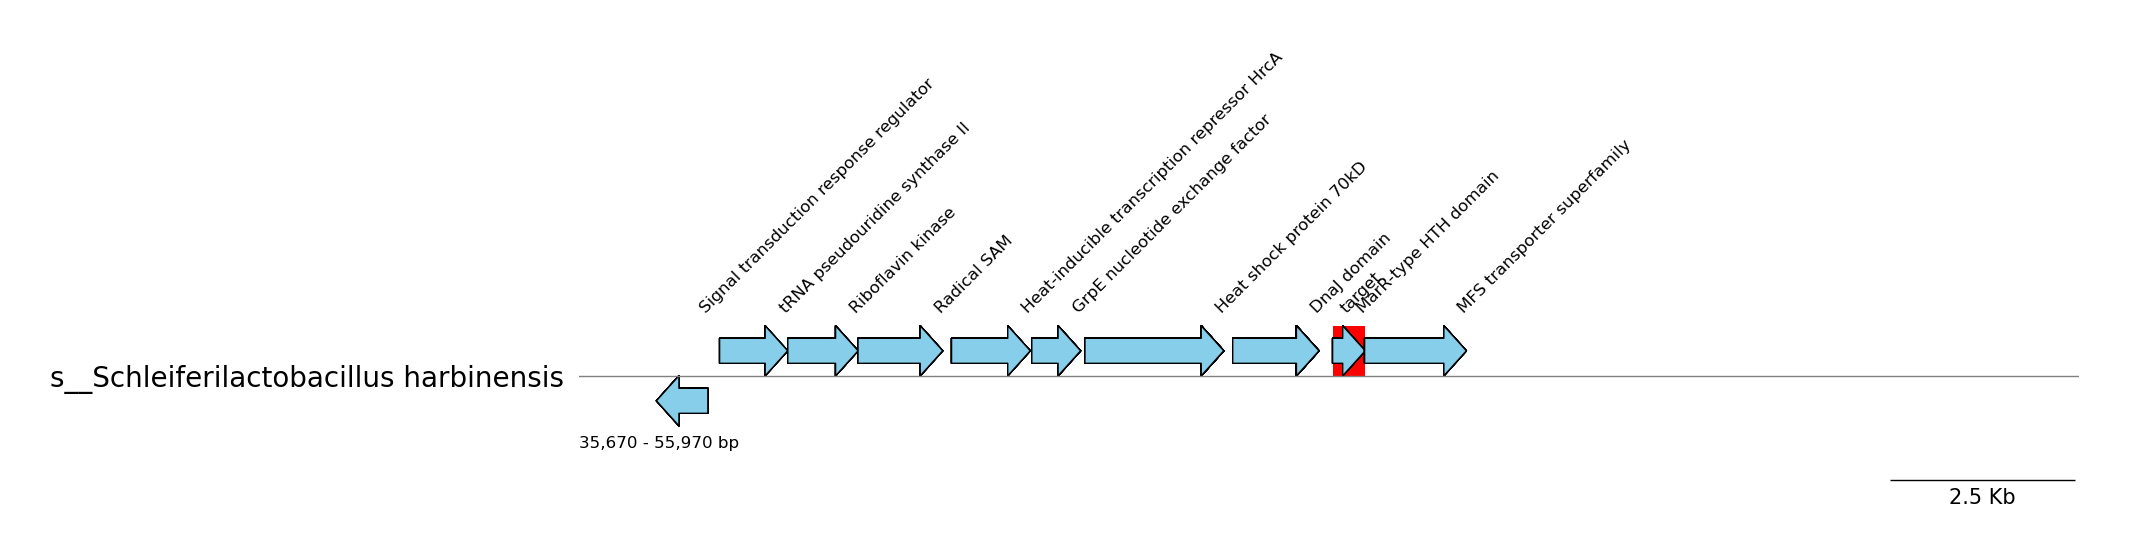

In [248]:
loc_count = 1
for index, row in marr_locs.iterrows():
    print(index, row)
    gv = GenomeViz()
    gv.set_scale_bar(ymargin=0.5)
    dist = 10000
    loc = row['start']
    strand = row['strand']
    contig = '_'.join(index.split('_')[:-1])
    loc_range = (int(loc-dist-200), int(loc+dist+100))
    target_ranges = (loc_range,)
    track = gv.add_feature_track(name=mag2species.loc[gff_dict[row['genome']].name], segments=target_ranges)
    track.set_segment_sep()

    already_added = []
    for segment in track.segments:
        ''
        track.add_feature(start=row['start'], end=row['stop'], fc='red', plotstyle='box', label='target', strand=strand)

        match_records = sorted([r.to_seq_feature() for r in gff_dict[row['genome']].all_records if (r.seqid == contig) and (r.start >= loc_range[0]) and (r.end <= loc_range[1])], key=lambda r: r.location.start)
        print(len(match_records))
        segment.add_sublabel()
        prev_id = match_records[0].id.split(':')[0]
        prev_feature = match_records[0]
        annots = []
        for feature in match_records:

            if feature.id.split(':')[0] != prev_id:
                # print(annots)
                annot_text = summarize_annotations(annots)
                segment.add_text(prev_feature.location.end,
                             text=annot_text.split(' (')[0])
                annots = [feature.qualifiers['interpro_desc']]

            else:

                annots += [feature.qualifiers['interpro_desc']]

            segment.add_features(feature, label_type="gene", fc="skyblue", 
                                 lw=1.0, text_kws=dict(bbox=dict(boxstyle="round", fc="skyblue")),
                             )

            prev_id, prev_feature = feature.id.split(':')[0], feature
            
        annot_text = summarize_annotations(annots)
        segment.add_text(prev_feature.location.end,
                             text=annot_text.split(' (')[0])
        



    fig = gv.plotfig()
    fig.savefig(f'./../data/figures/{mag2species.loc[row["genome"]]}_MarR_locus_{loc_count}.svg')
    loc_count += 1

In [167]:
import io

In [169]:
def maketabbed(func):
    def tabbed():
        output = io.StringIO()
        with contextlib.redirect_stdout(output):
            func()
        for line in output.getvalue().splitlines():
            print('\t' + line)
    return tabbed

In [171]:
def tprint(*args, **kwargs):
    print('\t', *args, **kwargs)

In [224]:

for index, row in marr_locs.iterrows():
    print(f'***\n MarR GENE: {index}\n***')
    print(f'Genome: {row["genome"]}')
    
    dist = 10000
    loc = row['start']
    strand = row['strand']
    contig = '_'.join(index.split('_')[:-1])
    loc_range = (int(loc-dist-200), int(loc+dist+100))
    target_ranges = (loc_range,)
    
    
    

    # track.add_feature(start=row['start'], end=row['stop'], fc='red', plotstyle='box', label='target', strand=strand)

    match_records = sorted([r.to_seq_feature() for r in gff_dict[row['genome']].all_records if (r.seqid == contig) and (r.start >= loc_range[0]) and (r.end <= loc_range[1])], key=lambda r: r.location.start)
    # print(len(match_records))
    # segment.add_sublabel()

    prev_id = match_records[0].id.split(':')[0]
    prev_feature = match_records[0]
    annots = []
    print('10,000 bp upstream:\n')
    i = 0
    for j, feature in enumerate(match_records):

        if feature.id.split(':')[0] != prev_id:
            # print(annots)
            annot_text = summarize_annotations(annots)

            if  prev_feature.id.split(':')[0] == index:
                tprint('*** MarR target >>>')
            tprint(f'*** Gene {i+1} ***')
            print(prev_id)
            tprint(annot_text)
            tprint(f'strand = {prev_feature.strand}')
            if  prev_feature.id.split(':')[0] == index:
                print('<<< MarR target ***')
            tprint()
            i += 1
            annots = [feature.qualifiers['interpro_desc']]

        else:

            annots += [feature.qualifiers['interpro_desc']]
        # print(annots)

        prev_id, prev_feature = feature.id.split(':')[0], feature

    print(prev_id)
    annot_text = summarize_annotations(annots)
    tprint(annot_text)
    tprint()
    tprint('10,000 bp downstream')

***
 MarR GENE: NODE_11_length_292332_cov_345.902770_65
***
Genome: HI4-3_MAG_04
10,000 bp upstream:

	 *** Gene 1 ***
NODE_11_length_292332_cov_345.902770_55
	 Glutamine synthetase (catalytic domain, N-terminal domain superfamily, beta-Grasp domain, Glutamine synthetase type I, N-terminal conserved site)
	 strand = 1
	
	 *** Gene 2 ***
NODE_11_length_292332_cov_345.902770_56
	 Glycine transporter
	 strand = 1
	
	 *** Gene 3 ***
NODE_11_length_292332_cov_345.902770_57
	 Cyclic-AMP phosphodiesterase (class-II, Ribonuclease Z/Hydroxyacylglutathione hydrolase-like)
	 strand = 1
	
	 *** Gene 4 ***
NODE_11_length_292332_cov_345.902770_58
	 Mercuric transport protein periplasmic component/copper chaperone CopZ (Heavy metal-associated domain, HMA, Heavy-metal-associated, conserved site, Heavy metal-associated domain superfamily)
	 strand = -1
	
	 *** Gene 5 ***
NODE_11_length_292332_cov_345.902770_59
	 Antibiotic biosynthesis monooxygenase domain (Dimeric alpha-beta barrel)
	 strand = -1
	
	 

### sliding GC window

start            62859
stop             63296
strand               1
genome    HI4-3_MAG_04
Name: NODE_11_length_292332_cov_345.902770_65, dtype: object


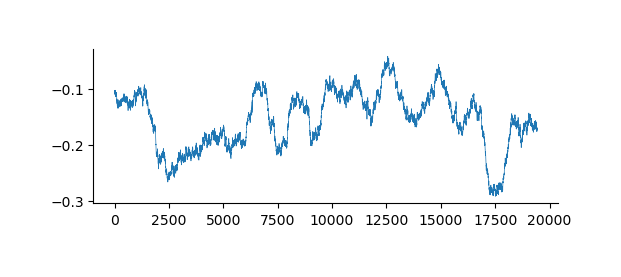

start           191747
stop            192184
strand               1
genome    UO5-1_MAG_02
Name: NODE_26_length_210358_cov_154.326900_184, dtype: object


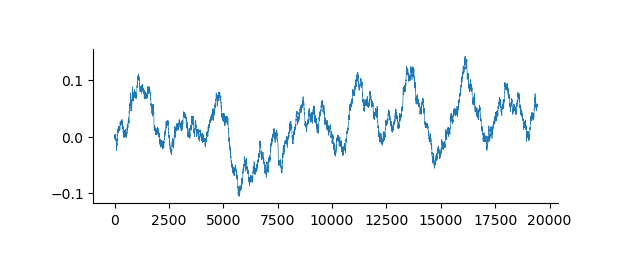

start            54889
stop             55296
strand              -1
genome    UO5-1_MAG_02
Name: NODE_68_length_101680_cov_139.397609_51, dtype: object


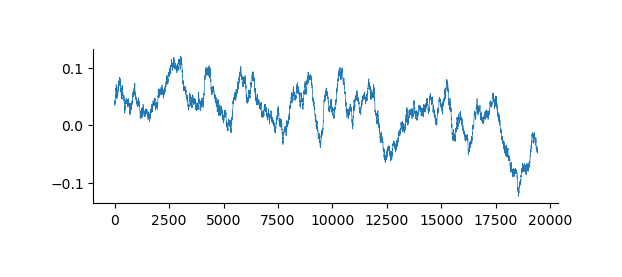

start            45870
stop             46310
strand               1
genome    HO2-3_MAG_04
Name: NODE_99_length_47719_cov_340.002077_46, dtype: object


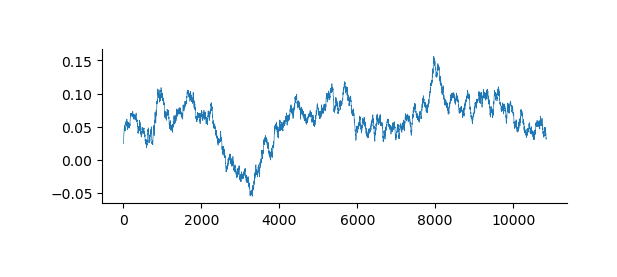

In [219]:
def gc_skew(seq):
    c = Counter(seq)
    return (c['G'] - c['C']) / (c['G'] + c['C'])

for index, row in marr_locs.iterrows():
    print(row)
    fasta = f'./../mag_pipeline/derep_mags/{gene2genome[index]}.fa'
    records = [r for r in SeqIO.parse(fasta, 'fasta')]
    
    ws = 1000
    contig = [r for r in records if r.id == '_'.join(index.split('_')[:-1])][0]
    seq = contig.seq[row['start']-10000:row['stop']+10000]
    skews = [gc_skew(seq[i:i+ws]) for i in range(0, len(seq)-ws)]
    fig, ax = plt.subplots(figsize=(6,2))
    sns.lineplot(skews)
    sns.despine()
    plt.show()
    

## Last part:
generic sugar transporter
    
    
    

In [232]:
ids = ['NODE_99_length_47719_cov_340.002077_47',
       'NODE_26_length_210358_cov_154.326900_177',
       'NODE_68_length_101680_cov_139.397609_49']

for gene, genome in zip(ids, gene2genome.loc[ids]):
    fasta = f'./../mag_pipeline/derep_mags/{genome}_protein.faa'
    records = [r for r in SeqIO.parse(fasta, 'fasta') if gene in r.id]
    print(f'>{records[0].id}')
    print(records[0].seq)

>NODE_99_length_47719_cov_340.002077_47
MTETKNDRIPGYVLGAIVATGVMSLCGTIVETAMNITFPTLMRQFGIGTSTVQWMTTLYLLVVAIIVPLSAYLKRRFTTKALFITANSLFIIGVLTDALAPSFAVLLLGRGIQGLGTGIALPLMFNIIIDQVPMAKLGLMMGVGTLITAVGPAIGPTFGGFVVDTLGWRYIFVFLLPLLIASLILGIMTIRQKHPTQAASLDWLSVLFLAVAFVAMILGFSNLGSRAFLSLTVGGMLLLAVVAFILLGWRSRQVTPIINFSVLKNSGFSSLTFALFAFQIATIGLSFILPNYIQLVNGASANLAGLLVLPGALLGAAMSPFGGRIYDNWGAKPPLLLGIILALGANVTLMVFAQSLSNWAIAVLYTVYMLSLGLSFGNLRTEGLSYLSGLTKSDGNAIMTTVQQISGAIGTAIVAAIVALGQAAPHVSRAVGTANGAQHALLFVVVLLLIALILLGSV
>NODE_26_length_210358_cov_154.326900_177
MTTSKAIEHRVINKLFRRLIVFLFILFVFSFLDRINIGFAGLTMGKDLGLTSTMFGLAATLFYVTYVLCGIPSNIMLAKIGARRWIAGIMVVWGIASTCTMFATSPQTLYVLRMLVGIAEAGFLPGILVYLTWWFPAYHRARANALFMIAMPVTMMLGSILSGYILALDGLWNLKGWQWLFLLEGLPSVVLGVVTWFYLNDTPDQATWLDDEEKQALKTMIAREQENAIAHAATPRSTLREVLTPAVLLYTLAYFCLTNTLSAINIWTPQILQSFNAGSSNIVIGLLAAIPQFCTILGMIWWSRRSDRLKERKKHTILPYLFAAAGWMLASATDHSLIQLLGIIMASTGSFTAMAIFWTTPDQVISLQSRAVALAVINAIGNVGSAVSPLLIGILRDATGSFSSGLWFVAGLLVVGALVLTRIPMTRQESLAREPDIAAQKIH
>NODE_68_length

These are just generic efflux transporters

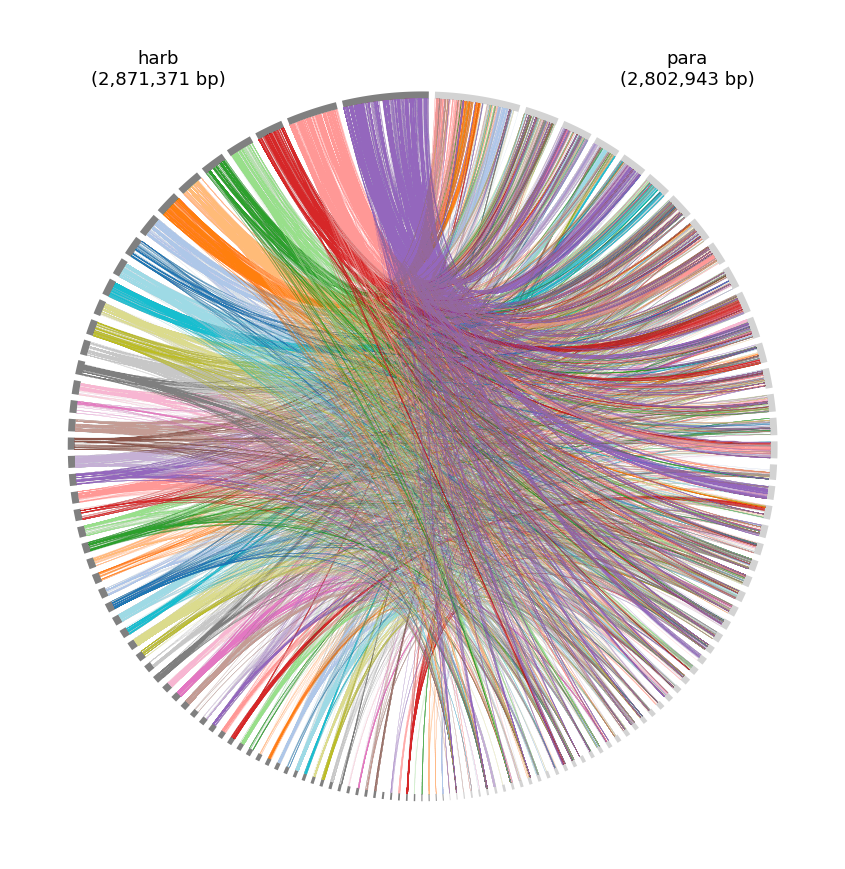

In [497]:
# %%time
# Initialize circos instance
eqid2size = gff.get_seqid2size()
space = 0 if len(seqid2size) == 1 else 2
circos = Circos(sectors=dict(**dict(reversed(sorted(para_gff.get_seqid2size().items(), key=lambda item: int(item[1])))),
                             **dict(sorted(harb_gff.get_seqid2size().items(), key=lambda item: int(item[1])))),
                start=-358,
    end=2,
    space=1,
                sector2clockwise={seqid: False for seqid in harb_gff.get_seqid2size().keys()})

circos.text(f"harb\n({harb_gff.full_genome_length:,} bp)", r=130, deg=-35, size=13)
circos.text(f"para\n({para_gff.full_genome_length:,} bp)", r=130, deg=35, size=13)

seqid2features = {**harb_gff.get_seqid2features(feature_type="protein_match"), 
                  **para_gff.get_seqid2features(feature_type="protein_match")}

for sector in circos.sectors:
    if sector.name in harb_gff.get_seqid2size().keys():
        color='gray'    
    else:
        color='lightgray'
    cds_track = sector.add_track((98, 100))
    cds_track.axis(fc=color, ec="none")

harb_sectors = harb_gff.get_seqid2size().keys()
pal = sns.color_palette('tab20', n_colors=len(harb_sectors)+1)
# pal = [sns.desaturate(c, 0.5) for c in sns.color_palette('gist_rainbow', n_colors=5)]
c_i = 0
for i, sector in enumerate(circos.sectors):
    if sector.name in harb_sectors:
        c_i += 1
        links = get_links(harb_gff, para_gff, sector, circos.sectors)
        for link in links:
            if len(seq2ortho.loc[[link[0][0], link[1][0]]].unique()) == 1:
                l1 = link[0]
                circos.link(fix_link(link[0]), fix_link(link[1]), r1=98, r2=98, alpha=0.1, color=pal[c_i])


fig = circos.plotfig()

In [412]:
hop_tolerance = pd.Series(index=mag2species.values, data=[False]*8)
hop_tolerance.loc['s__'] = True
hop_tolerance.loc['s__Schleiferilactobacillus harbinensis'] = True
hop_tolerance.loc['s__Gluconobacter_A japonicus'] = True


In [430]:
# orthogroups found in at least two genomes
clustermap_df = orthogroup_counts[(orthogroup_counts.fillna(0) > 1).sum(1) > 0].fillna(1).apply(np.log2)

In [447]:
hop_orthos = ((orthogroup_counts.loc[:, ~hop_tolerance] > 0).sum(1) - (orthogroup_counts.loc[:, hop_tolerance] > 0).sum(1)).sort_values().head(10).index

In [443]:
clustermap_df.head(2)

,s__Lacticaseibacillus paracasei,s__Schleiferilactobacillus harbinensis,s__Pantoea agglomerans,s__Pseudescherichia vulneris,s__,s__Lentilactobacillus parabuchneri,s__Levilactobacillus brevis,s__Gluconobacter_A japonicus
OG0000000,5.554589,5.523562,5.357552,5.169925,5.087463,4.392317,4.000000,3.321928
OG0000001,3.169925,2.807355,6.022368,5.209453,5.247928,2.584963,2.807355,3.807355


In [444]:
orthogroup_counts.loc[hops_genes, hop_tolerance.sort_values().index].head(3)

,s__Lacticaseibacillus paracasei,s__Pantoea agglomerans,s__Levilactobacillus brevis,s__Pseudescherichia vulneris,s__Lentilactobacillus parabuchneri,s__Gluconobacter_A japonicus,s__Schleiferilactobacillus harbinensis,s__
OG0003183,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
OG0002903,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN
OG0002863,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0


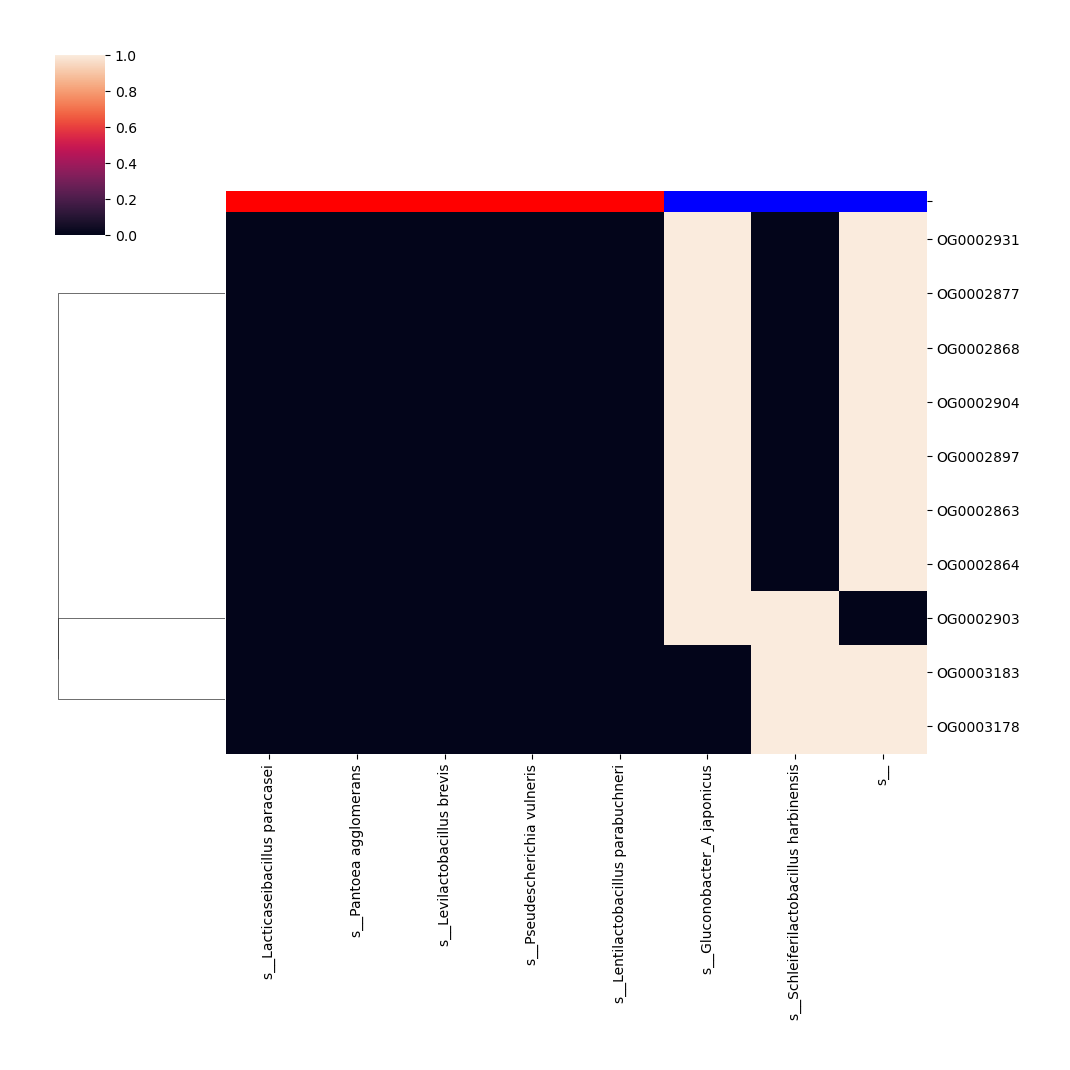

In [439]:
sns.clustermap(orthogroup_counts.loc[hops_genes, hop_tolerance.sort_values().index].fillna(0),
               col_cluster=False,
               col_colors=hop_tolerance.map({True:'blue', False:'red'}))

In [448]:
hop_genes = seq2ortho[seq2ortho.isin(hop_orthos)].index

In [450]:
mag2species

user_genome
HI4-3_MAG_04              s__Gluconobacter_A japonicus
HO2-3_MAG_03           s__Lacticaseibacillus paracasei
HO2-3_MAG_04    s__Schleiferilactobacillus harbinensis
UO2-1_MAG_03                    s__Pantoea agglomerans
UO2-3_MAG_03               s__Levilactobacillus brevis
UO5-1_MAG_01              s__Pseudescherichia vulneris
UO5-1_MAG_02                                       s__
UO6-3_MAG_03        s__Lentilactobacillus parabuchneri
Name: classification, dtype: object

In [451]:
gluc_annot = process_interpro('./../mag_pipeline/derep_mags/HI4-3_MAG_04_interpro.tsv')

In [452]:
gluc_annot[gluc_annot.gene_ID.isin(hop_genes)]

,gene_ID,gene_md4,gene_length,analysis,match_acc,match_desc,match_start,match_stop,score,match_status,date,interpro_acc,interpro_desc,contig,gene_order_contig
170,NODE_10_length_294944_cov_287.652690_65,3e6d2e63ab5038e49c03e55b74112b0b,293,Pfam,PF01066,CDP-alcohol phosphatidyltransferase,42,105,3.3E-13,T,26-05-2023,IPR000462,CDP-alcohol phosphatidyltransferase,NODE_10_length_294944_cov_287.652690,NODE_10_length_294944_cov_287.652690
171,NODE_10_length_294944_cov_287.652690_65,3e6d2e63ab5038e49c03e55b74112b0b,293,ProSitePatterns,PS00379,CDP-alcohol phosphatidyltransferases signature.,83,105,-,T,26-05-2023,IPR000462,CDP-alcohol phosphatidyltransferase,NODE_10_length_294944_cov_287.652690,NODE_10_length_294944_cov_287.652690
172,NODE_10_length_294944_cov_287.652690_65,3e6d2e63ab5038e49c03e55b74112b0b,293,Gene3D,G3DSA:1.20.120.1760,-,30,227,3.3E-22,T,26-05-2023,IPR043130,"CDP-alcohol phosphatidyltransferase, transmemb...",NODE_10_length_294944_cov_287.652690,NODE_10_length_294944_cov_287.652690
173,NODE_10_length_294944_cov_287.652690_65,3e6d2e63ab5038e49c03e55b74112b0b,293,PANTHER,PTHR14269:SF47,CDP-DIACYLGLYCEROL--SERINE O-PHOSPHATIDYLTRANS...,41,219,2.4E-22,T,26-05-2023,-,-,NODE_10_length_294944_cov_287.652690,NODE_10_length_294944_cov_287.652690
174,NODE_10_length_294944_cov_287.652690_65,3e6d2e63ab5038e49c03e55b74112b0b,293,PANTHER,PTHR14269,CDP-DIACYLGLYCEROL--GLYCEROL-3-PHOSPHATE 3-PHO...,41,219,2.4E-22,T,26-05-2023,-,-,NODE_10_length_294944_cov_287.652690,NODE_10_length_294944_cov_287.652690
175,NODE_10_length_294944_cov_287.652690_65,3e6d2e63ab5038e49c03e55b74112b0b,293,Pfam,PF08009,CDP-alcohol phosphatidyltransferase 2,232,268,3.4E-12,T,26-05-2023,IPR012616,"CDP-alcohol phosphatidyltransferase, C-terminal",NODE_10_length_294944_cov_287.652690,NODE_10_length_294944_cov_287.652690
3229,NODE_2_length_513548_cov_317.819548_76,a5e5b6df71b29734d6de12dafdc7be50,274,PANTHER,PTHR31609,YDJC DEACETYLASE FAMILY MEMBER,3,273,1.0E-35,T,26-05-2023,IPR006879,Carbohydrate deacetylase YdjC-like,NODE_2_length_513548_cov_317.819548,NODE_2_length_513548_cov_317.819548
3230,NODE_2_length_513548_cov_317.819548_76,a5e5b6df71b29734d6de12dafdc7be50,274,SUPERFAMILY,SSF88713,Glycoside hydrolase/deacetylase,1,274,5.56E-64,T,26-05-2023,IPR011330,"Glycoside hydrolase/deacetylase, beta/alpha-ba...",NODE_2_length_513548_cov_317.819548,NODE_2_length_513548_cov_317.819548
3231,NODE_2_length_513548_cov_317.819548_76,a5e5b6df71b29734d6de12dafdc7be50,274,TIGRFAM,TIGR03473,HpnK: hopanoid biosynthesis associated protein...,3,274,1.8E-119,T,26-05-2023,IPR017836,Hopanoid biosynthesis associated protein HpnK,NODE_2_length_513548_cov_317.819548,NODE_2_length_513548_cov_317.819548
3232,NODE_2_length_513548_cov_317.819548_76,a5e5b6df71b29734d6de12dafdc7be50,274,CDD,cd10804,YdjC_HpnK_like,4,254,1.48701E-123,T,26-05-2023,-,-,NODE_2_length_513548_cov_317.819548,NODE_2_length_513548_cov_317.819548


In [449]:
harb_annot[harb_annot.gene_ID.isin(hop_genes)]

,gene_ID,gene_md4,gene_length,analysis,match_acc,match_desc,match_start,match_stop,score,match_status,date,interpro_acc,interpro_desc,contig,gene_order_contig
10838,NODE_155_length_21491_cov_473.582898_15,793f9cc805d19131f03eac7cd0e76d29,174,SUPERFAMILY,SSF52540,P-loop containing nucleoside triphosphate hydr...,1,128,2.95E-15,T,30-05-2023,IPR027417,P-loop containing nucleoside triphosphate hydr...,NODE_155_length_21491_cov_473.582898,NODE_155_length_21491_cov_473.582898
10839,NODE_155_length_21491_cov_473.582898_15,793f9cc805d19131f03eac7cd0e76d29,174,Gene3D,G3DSA:3.40.50.300,-,1,131,9.4E-13,T,30-05-2023,IPR027417,P-loop containing nucleoside triphosphate hydr...,NODE_155_length_21491_cov_473.582898,NODE_155_length_21491_cov_473.582898
10840,NODE_155_length_21491_cov_473.582898_15,793f9cc805d19131f03eac7cd0e76d29,174,PANTHER,PTHR37816,YALI0E33011P,1,168,7.3E-30,T,30-05-2023,-,-,NODE_155_length_21491_cov_473.582898,NODE_155_length_21491_cov_473.582898
10841,NODE_155_length_21491_cov_473.582898_15,793f9cc805d19131f03eac7cd0e76d29,174,PANTHER,PTHR37816:SF1,DNA TOPOLOGY MODULATION PROTEIN FLAR-RELATED P...,1,168,7.3E-30,T,30-05-2023,-,-,NODE_155_length_21491_cov_473.582898,NODE_155_length_21491_cov_473.582898
17624,NODE_4_length_347146_cov_415.003498_236,06772f32edbee544a51c4b57cd350b6b,390,Pfam,PF13560,Helix-turn-helix domain,3,57,1.2E-6,T,30-05-2023,-,-,NODE_4_length_347146_cov_415.003498,NODE_4_length_347146_cov_415.003498
17625,NODE_4_length_347146_cov_415.003498_236,06772f32edbee544a51c4b57cd350b6b,390,SMART,SM00530,mbf_short4,6,61,2.2E-4,T,30-05-2023,IPR001387,Cro/C1-type helix-turn-helix domain,NODE_4_length_347146_cov_415.003498,NODE_4_length_347146_cov_415.003498
17626,NODE_4_length_347146_cov_415.003498_236,06772f32edbee544a51c4b57cd350b6b,390,Gene3D,G3DSA:1.10.260.40,-,2,72,3.7E-11,T,30-05-2023,IPR010982,"Lambda repressor-like, DNA-binding domain supe...",NODE_4_length_347146_cov_415.003498,NODE_4_length_347146_cov_415.003498
17627,NODE_4_length_347146_cov_415.003498_236,06772f32edbee544a51c4b57cd350b6b,390,ProSiteProfiles,PS50943,Cro/C1-type HTH domain profile.,7,61,12.389872,T,30-05-2023,IPR001387,Cro/C1-type helix-turn-helix domain,NODE_4_length_347146_cov_415.003498,NODE_4_length_347146_cov_415.003498
17628,NODE_4_length_347146_cov_415.003498_236,06772f32edbee544a51c4b57cd350b6b,390,CDD,cd00093,HTH_XRE,4,61,1.92652E-8,T,30-05-2023,IPR001387,Cro/C1-type helix-turn-helix domain,NODE_4_length_347146_cov_415.003498,NODE_4_length_347146_cov_415.003498
17629,NODE_4_length_347146_cov_415.003498_236,06772f32edbee544a51c4b57cd350b6b,390,Pfam,PF06114,IrrE N-terminal-like domain,165,286,1.3E-17,T,30-05-2023,IPR010359,IrrE N-terminal-like domain,NODE_4_length_347146_cov_415.003498,NODE_4_length_347146_cov_415.003498


In [372]:
harb_groups = orthogroup_counts.loc[:, 's__Schleiferilactobacillus harbinensis']
para_groups = orthogroup_counts.loc[:, 's__Lacticaseibacillus paracasei']

In [367]:
_groups[~para_groups.isnull()]
harb_orthos = harb_groups[~harb_groups.isnull()]

OG0000000    46.0
OG0000001     7.0
OG0000002    10.0
OG0000003    16.0
OG0000004    13.0
             ... 
OG0005452     1.0
OG0005453     1.0
OG0005454     1.0
OG0005455     1.0
OG0005456     1.0
Name: s__Schleiferilactobacillus harbinensis, Length: 1954, dtype: float64

In [371]:
mag2species

user_genome
HI4-3_MAG_04              s__Gluconobacter_A japonicus
HO2-3_MAG_03           s__Lacticaseibacillus paracasei
HO2-3_MAG_04    s__Schleiferilactobacillus harbinensis
UO2-1_MAG_03                    s__Pantoea agglomerans
UO2-3_MAG_03               s__Levilactobacillus brevis
UO5-1_MAG_01              s__Pseudescherichia vulneris
UO5-1_MAG_02                                       s__
UO6-3_MAG_03        s__Lentilactobacillus parabuchneri
Name: classification, dtype: object

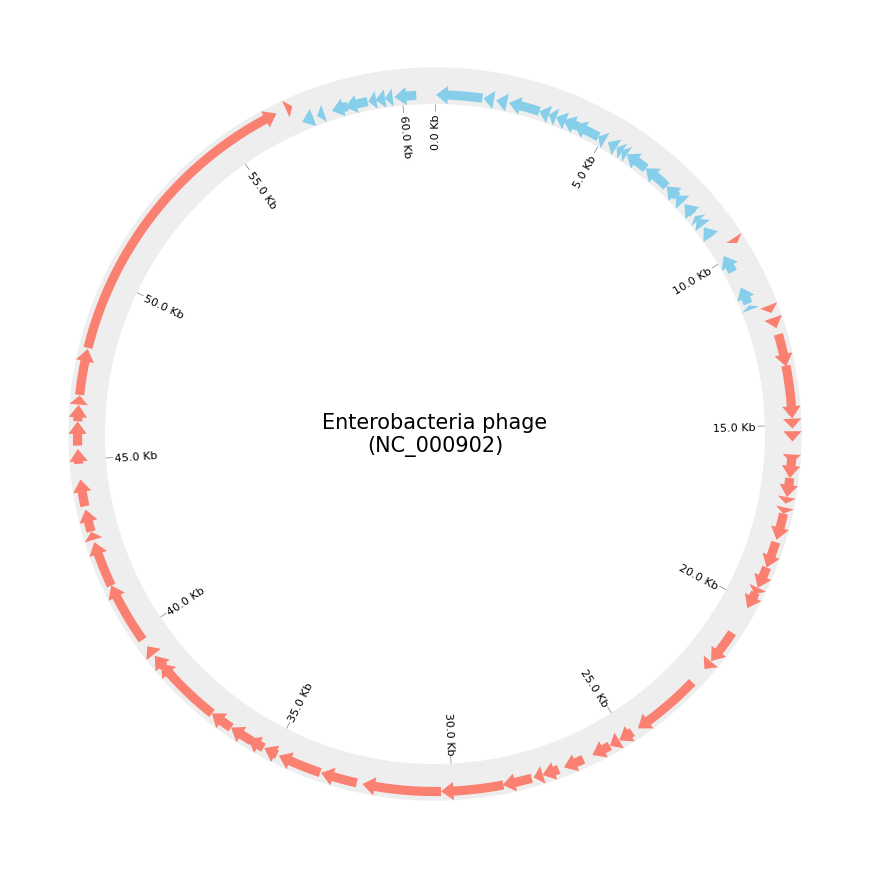

In [45]:

# Load GFF file
gff_file = load_prokaryote_example_file("enterobacteria_phage.gff")
gff = Gff(gff_file)

# Initialize circos instance
seqid2size = gff.get_seqid2size()
space = 0 if len(seqid2size) == 1 else 2
circos = Circos(sectors=seqid2size, space=space)
circos.text("Enterobacteria phage\n(NC_000902)", size=15)

seqid2features = gff.get_seqid2features(feature_type="CDS")
for sector in circos.sectors:
    cds_track = sector.add_track((90, 100))
    cds_track.axis(fc="#EEEEEE", ec="none")

    features = seqid2features[sector.name]
    label_pos_list, labels = [], []
    for feature in features:
        # Plot CDS features
        if feature.location.strand == 1:
            cds_track.genomic_features(feature, plotstyle="arrow", r_lim=(95, 100), fc="salmon")
        else:
            cds_track.genomic_features(feature, plotstyle="arrow", r_lim=(90, 95), fc="skyblue")
        # Extract feature product label & position
        start, end = int(feature.location.start), int(feature.location.end)
        label_pos = (start + end) / 2
        label = feature.qualifiers.get("product", [""])[0]
        if label == "" or label.startswith("hypothetical"):
            continue
        # cds_track.annotate(label_pos, label, label_size=7)

    # Plot xticks & intervals on inner position
    cds_track.xticks_by_interval(
        interval=5000,
        outer=False,
        label_formatter=lambda v: f"{v/ 1000:.1f} Kb",
        label_orientation="vertical",
        line_kws=dict(ec="grey"),
    )

fig = circos.plotfig()

In [46]:
feature

SeqFeature(SimpleLocation(ExactPosition(59776), ExactPosition(60406), strand=-1), type='CDS', id='cds-NP_050579.1', qualifiers=...)

In [43]:
from pycirclize.parser import Gff

from pycirclize.utils import load_prokaryote_example_file

# # Load GFF file
# gff_file = load_prokaryote_example_file("enterobacteria_phage.gff")
# gff = Gff(gff_file)

# Initialize circos instance
# seqid2size = gff.get_seqid2size()
seqid2size = dict((f'contig{i+1}', int(name.split('_length_')[-1].split('_cov')[0])) for i, name in enumerate(harb_annot['contig'].unique()))
space = 0 if len(seqid2size) == 1 else 2
circos = Circos(sectors=seqid2size, space=space)
for sector in circos.sectors:
    cds_track = sector.add_track((90, 100))
    cds_track.axis(fc="#EEEEEE", ec="none")
    
    cds_track.genomic_features(feature, plotstyle="arrow", r_lim=(95, 100), fc="salmon")


fig = circos.plotfig()

NameError: name 'feature' is not defined

In [36]:
seqid2size

{'NC_000902.1': 60942}

{'contig1': 86887,
 'contig2': 77636,
 'contig3': 38912,
 'contig4': 59792,
 'contig5': 203974,
 'contig6': 66950,
 'contig7': 12721,
 'contig8': 47719,
 'contig9': 68423,
 'contig10': 347146,
 'contig11': 35703,
 'contig12': 36505,
 'contig13': 34846,
 'contig14': 20561,
 'contig15': 32539,
 'contig16': 28095,
 'contig17': 46310,
 'contig18': 30556,
 'contig19': 25175,
 'contig20': 50235,
 'contig21': 26421,
 'contig22': 106041,
 'contig23': 6995,
 'contig24': 56682,
 'contig25': 18914,
 'contig26': 43161,
 'contig27': 48061,
 'contig28': 114039,
 'contig29': 60811,
 'contig30': 45678,
 'contig31': 31993,
 'contig32': 40442,
 'contig33': 60935,
 'contig34': 98009,
 'contig35': 98248,
 'contig36': 49820,
 'contig37': 41420,
 'contig38': 22603,
 'contig39': 11079,
 'contig40': 93075,
 'contig41': 55285,
 'contig42': 11704,
 'contig43': 48773,
 'contig44': 12467,
 'contig45': 19824,
 'contig46': 16045,
 'contig47': 11977,
 'contig48': 15250,
 'contig49': 30522,
 'contig50': 11473,
 'cont

In [33]:
# Initialize circos instance
circos = Circos(
                )


TypeError: __init__() missing 1 required positional argument: 'sectors'

In [ ]:
def make_genome_map(annot):

## Figure 4: yeast

In [758]:
# chromosome name mapping
chromosome_name_map = {'NC_001133.9':'chromosome1',
'NC_001134.8':'chromosome2',
'NC_001135.5':'chromosome3',
'NC_001136.10':'chromosome4',
'NC_001137.3':'chromosome5',
'NC_001138.5':'chromosome6',
'NC_001139.9':'chromosome7',
'NC_001140.6':'chromosome8',
'NC_001141.2':'chromosome9',
'NC_001142.9':'chromosome10',
'NC_001143.9':'chromosome11',
'NC_001144.5':'chromosome12',
'NC_001145.3':'chromosome13',
'NC_001146.8':'chromosome14',
'NC_001147.6':'chromosome15',
'NC_001148.4':'chromosome16'}
##contig=<ID=NC_001224.1,length=85779>


















In [789]:
beer_vcf = pd.read_csv('/data/mhoffert/fiererlab/beer/vcf_pipeline/beer_filtered.vcf.gz',skiprows=48, sep='\t', compression='gzip')

beer_vcf['#CHROM'] = beer_vcf['#CHROM'].map(chromosome_name_map)
beer_vcf[['#CHROM', 'POS', 'REF', 'ALT']]
bam_cols = [c for c in beer_vcf.columns if '.bam' in c]
for bc in bam_cols:
    beer_vcf[bc] = beer_vcf[bc].apply(lambda x: x.split(':')[0])
beer_vcf_parsed = beer_vcf[['#CHROM', 'POS', 'REF', 'ALT'] + bam_cols]
beer_vcf_parsed = beer_vcf_parsed.rename(columns=dict((s, s.replace('./', '').split('_S')[0]) for s in bam_cols))
beer_vcf_parsed = beer_vcf_parsed.drop('CommStd', axis=1).dropna()

In [809]:
gts = ['./.', '0/0', '0/1', '1/1']
gts_diff_list = []
for index, row in beer_vcf_parsed.iterrows():
    display(index)
    clear_output(wait=True)
    hop_freq = row[[s for s in row.index if s[0] == 'H']].value_counts()
    nohop_freq = row[[s for s in row.index if s[0] == 'U']].value_counts()

    gts_diff_list.append(hop_freq.reindex(gts).fillna(0) - nohop_freq.reindex(gts).fillna(0))

5929

In [816]:
gt_hop_specificity = pd.concat(gts_diff_list, axis=1).T

(array([1.28e+02, 1.34e+02, 1.39e+02, 7.50e+01, 1.52e+02, 5.24e+03,
        4.50e+01, 1.50e+01, 0.00e+00, 2.00e+00]),
 array([-23. , -18.6, -14.2,  -9.8,  -5.4,  -1. ,   3.4,   7.8,  12.2,
         16.6,  21. ]),
 <BarContainer object of 10 artists>)

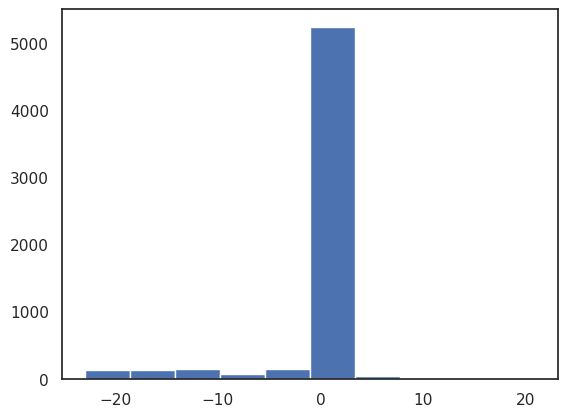

In [847]:
plt.hist(gt_hop_specificity['1/1'])

In [848]:
with open('/data/mhoffert/fiererlab/beer/vcf_pipeline/queries.txt', 'w') as handle:
    for index, row in beer_vcf.loc[gt_hop_specificity.index[gt_hop_specificity['0/1'] > 5], :].iterrows():
        handle.write(f'{row["#CHROM"]}\t{row["POS"]}\n')
    

In [849]:
genomes_vcf = pd.read_csv('/data/mhoffert/fiererlab/beer/1002yeast/1011Matrix.gvcf', skiprows=55, sep='\t', nrows=500)

In [853]:
genomes_vcf_queried = pd.read_csv('/data/mhoffert/fiererlab/beer/vcf_pipeline/queried_1011Matrix.gvcf',  sep='\t', names=genomes_vcf.columns)

In [856]:
genomes_vcf_queried.shape

(119, 1020)

In [857]:
for col in genomes_vcf_queried.columns[9:]:
    genomes_vcf_queried[col] = genomes_vcf_queried[col].apply(lambda x: x.split(':')[0])

In [860]:
(genomes_vcf_queried == '0/1').sum().sort_values(ascending=False).head(10)

BFG    25
BTE    22
BFE    21
BMG    20
CKS    19
BMM    19
CFI    18
CKK    18
CGC    18
CFN    17
dtype: int64

In [846]:
genomes_vcf.head()

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,AAA,...,SACE_YDF,SACE_YDG,SACE_YDH,SACE_YDI,SACE_YDJ,SACE_YDK,SACE_YDL,SACE_YDM,SACE_YDN,SACE_YDO
0,chromosome1,33,.,CA,C,740.25,.,AC=48;AF=0.070;AN=686;BaseQRankSum=0.804;Clipp...,GT:AD:DP:GQ:PGT:PID:PL,"./.:0,0:0",...,"./.:3,0:3","./.:11,0:11","0/0:12,0:12:0:.:.:0,0,168","0/0:6,0:6:0:.:.:0,0,2","./.:0,0:0","./.:5,0:5","./.:1,0:1","./.:0,0:0","0/0:6,0:6:12:.:.:0,12,180","0/0:2,0:2:3:.:.:0,3,45"
1,chromosome1,56,.,A,AC,8812.42,.,AC=2;AF=0.013;AN=158;DP=5238;FS=0.000;GQ_MEAN=...,GT:AD:DP:GQ:PGT:PID:PL,"./.:0,0:0",...,"./.:0,0:0","./.:12,0:12","./.:5,0:5","./.:1,0:1","./.:0,0:0","./.:4,0:4","./.:1,0:1","./.:0,0:0","./.:0,0:0:.:0|1:56_A_ACCACACC","./.:0,0:0"
2,chromosome1,63,.,T,C,223.10,.,AC=4;AF=0.071;AN=56;DP=5226;FS=0.000;GQ_MEAN=6...,GT:AD:DP:GQ:PGT:PID:PL,"./.:0,0:0",...,"./.:0,0:0","./.:12,0:12","./.:5,0:5","./.:1,0:1","./.:0,0:0","./.:4,0:4","./.:1,0:1","./.:0,0:0","0/0:0,0:1:0:0|1:56_A_ACCACACC:0,0,0","./.:0,0:0"
3,chromosome1,65,.,CTA,C,2593.68,.,AC=3;AF=6.944e-03;AN=432;DP=5586;FS=0.000;GQ_M...,GT:AD:DP:GQ:PGT:PID:PL,"./.:0,0:0",...,"./.:0,0:0","./.:12,0:12","./.:5,0:5","./.:1,0:1","./.:0,0:0","0/0:4,0:4:0:.:.:0,0,14","0/0:1,0:1:3:.:.:0,3,42","./.:0,0:0","0/0:7,0:7:0:.:.:0,0,115","./.:0,0:0"
4,chromosome1,71,.,CTACCCTAA,C,5238.64,.,AC=2;AF=4.808e-03;AN=416;DP=5697;FS=0.000;GQ_M...,GT:AD:DP:GQ:PGT:PID:PL,"./.:0,0:0",...,"./.:0,0:0","./.:12,0:12","./.:5,0:5","0/0:3,0:3:9:.:.:0,9,86","./.:0,0:0","0/0:5,0:5:12:.:.:0,12,180","0/0:1,0:1:3:.:.:0,3,42","./.:0,0:0","./.:0,0:1:.:0|1:56_A_ACCACACC","./.:0,0:0"


In [841]:
beer_vcf.loc[gt_hop_specificity.index[gt_hop_specificity['0/1'] > 15], :]

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,./CommStd_S36_sort.bam,...,./UO2-1_S37_sort.bam,./UO2-3_S27_sort.bam,./UO3-1_S44_sort.bam,./UO3-3_S34_sort.bam,./UO4-1_S8_sort.bam,./UO4-3_S41_sort.bam,./UO5-1_S2_sort.bam,./UO5-3_S48_sort.bam,./UO6-1_S14_sort.bam,./UO6-3_S52_sort.bam
134,chromosome1,70943,.,C,T,12343.80,.,.,GT:PL:DP:SP:AD:GP:GQ,./.,...,1/1,1/1,1/1,1/1,1/1,1/1,1/1,1/1,1/1,1/1
135,chromosome1,92310,.,G,T,12117.20,.,.,GT:PL:DP:SP:AD:GP:GQ,./.,...,1/1,1/1,1/1,1/1,1/1,1/1,1/1,1/1,1/1,1/1
165,chromosome1,183954,.,T,C,11999.60,.,.,GT:PL:DP:SP:AD:GP:GQ,./.,...,1/1,1/1,1/1,1/1,1/1,1/1,0/1,1/1,1/1,0/1
171,chromosome1,184325,.,C,T,1148.44,.,.,GT:PL:DP:SP:AD:GP:GQ,./.,...,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0
303,chromosome1,220382,.,C,A,5949.84,.,.,GT:PL:DP:SP:AD:GP:GQ,./.,...,1/1,1/1,1/1,1/1,1/1,1/1,1/1,./.,1/1,1/1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5698,chromosome16,98068,.,T,C,1959.44,.,.,GT:PL:DP:SP:AD:GP:GQ,./.,...,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0
5702,chromosome16,98236,.,A,G,1985.07,.,.,GT:PL:DP:SP:AD:GP:GQ,./.,...,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0
5703,chromosome16,98320,.,T,C,1566.09,.,.,GT:PL:DP:SP:AD:GP:GQ,1/1,...,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0
5705,chromosome16,98464,.,C,T,1734.81,.,.,GT:PL:DP:SP:AD:GP:GQ,./.,...,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0,0/0


## Supplementary Table 1

In [40]:
bins_name_map = pd.read_csv('/data/mhoffert/fiererlab/beer/mag_pipeline/bins_names_map.tsv', sep='\t', index_col=0)

bins_data = pd.read_csv('/data/mhoffert/fiererlab/beer/mag_pipeline/full_bin_qa_data.tsv', sep='\t', index_col=0)

In [41]:
mag2species.index

Index(['HI4-3_MAG_04', 'HO2-3_MAG_03', 'HO2-3_MAG_04', 'UO2-1_MAG_03',
       'UO2-3_MAG_03', 'UO5-1_MAG_01', 'UO5-1_MAG_02', 'UO6-3_MAG_03',
       'S_cerevisiae'],
      dtype='object', name='user_genome')

In [43]:
bins_data

,user_genome,classification,fastani_reference,fastani_reference_radius,fastani_taxonomy,fastani_ani,fastani_af,closest_placement_reference,closest_placement_radius,closest_placement_taxonomy,...,0.1,1,2,3,4,5+,Completeness,Contamination,Strain heterogeneity,sample_name_y
0,UI5-3_S21.2,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,GCF_001433855.1,95.0,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,97.50,0.931,GCF_001433855.1,95.0,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,...,2,374,0,0,0,0,99.06,0.00,0.00,UI5-3
1,concoct.25,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11,1120,40,2,0,0,99.57,3.98,76.09,UI5-3
2,concoct.41,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,GCF_000425885.1,95.0,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,98.05,0.870,GCF_000425885.1,95.0,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,...,2,346,2,0,0,0,99.21,0.52,0.00,UI5-3
3,concoct.13,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,1166,4,0,0,0,99.66,0.49,0.00,HI1-1
4,concoct.12,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,1166,4,0,0,0,99.66,0.49,0.00,HI6-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,HO2-3_S40.1,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,GCF_000829035.1,95.0,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,98.21,0.899,GCF_000829035.1,95.0,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,...,1,585,0,0,0,0,99.46,0.00,0.00,HO2-3
121,HO2-3_S40.5,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,GCF_000425885.1,95.0,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,98.04,0.892,GCF_000425885.1,95.0,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactob...,...,3,345,2,0,0,0,98.69,0.52,0.00,HO2-3
122,concoct.5,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,1166,4,0,0,0,99.66,0.49,0.00,HO2-3
123,concoct.7,d__Bacteria;p__Proteobacteria;c__Gammaproteoba...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,1159,10,0,0,0,99.65,1.19,20.00,HC1


In [44]:
st1 = pd.merge(bins_data, bins_name_map, left_on='uid', right_on='bin_uid')

In [45]:
st1 = st1[st1.bin_uid_new.isin(mag2species.index)][['bin_uid_new', 'user_genome', 'classification', 'classification_method', 'Completeness', 'Contamination',
       'Strain heterogeneity']]

In [47]:
st1.columns = ['uid', 'original_mag_id', 'gtdbtk_classification', 'gtdbtk_classification_method', 'checkm_completeness', 'checkm_contamination', 'checkm_strain_heterogeneity']

In [48]:
st1.to_csv('/data/mhoffert/fiererlab/beer/tables/SupplementaryTable1_MAG_info.tsv', sep='\t')

In [27]:
bins_name_map

,Unnamed: 0,path,bin_uid,bin_uid_new,passed_filtering
0,0,/data/mhoffert/fiererlab/beer/mag_pipeline/UI5...,concoct.25_UI5-3,UI5-3_MAG_01,True
1,1,/data/mhoffert/fiererlab/beer/mag_pipeline/UI5...,concoct.41_UI5-3,UI5-3_MAG_02,True
2,2,/data/mhoffert/fiererlab/beer/mag_pipeline/UI5...,UI5-3_S21.1_UI5-3,UI5-3_MAG_03,False
3,3,/data/mhoffert/fiererlab/beer/mag_pipeline/UI5...,UI5-3_S21.2_UI5-3,UI5-3_MAG_04,True
4,4,/data/mhoffert/fiererlab/beer/mag_pipeline/HI1...,concoct.13_HI1-1,HI1-1_MAG_01,True
...,...,...,...,...,...
152,152,/data/mhoffert/fiererlab/beer/mag_pipeline/HO2...,HO2-3_S40.5_HO2-3,HO2-3_MAG_04,True
153,153,/data/mhoffert/fiererlab/beer/mag_pipeline/HC1...,concoct.5_HC1,HC1_MAG_01,False
154,154,/data/mhoffert/fiererlab/beer/mag_pipeline/HC1...,concoct.7_HC1,HC1_MAG_02,True
155,155,/data/mhoffert/fiererlab/beer/mag_pipeline/HO6...,concoct.27_HO6-1,HO6-1_MAG_01,False


# Old code

pH HI
pH HO
pH UI
pH UO
Density HI
Density HO
Density UI
Density UO
Glucose HI
Glucose HO
Glucose UI
Glucose UO
Sucrose HI
Sucrose HO
Sucrose UI
Sucrose UO
Maltose HI
Maltose HO
Maltose UI
Maltose UO
Maltotriose HI
Maltotriose HO
Maltotriose UI
Maltotriose UO


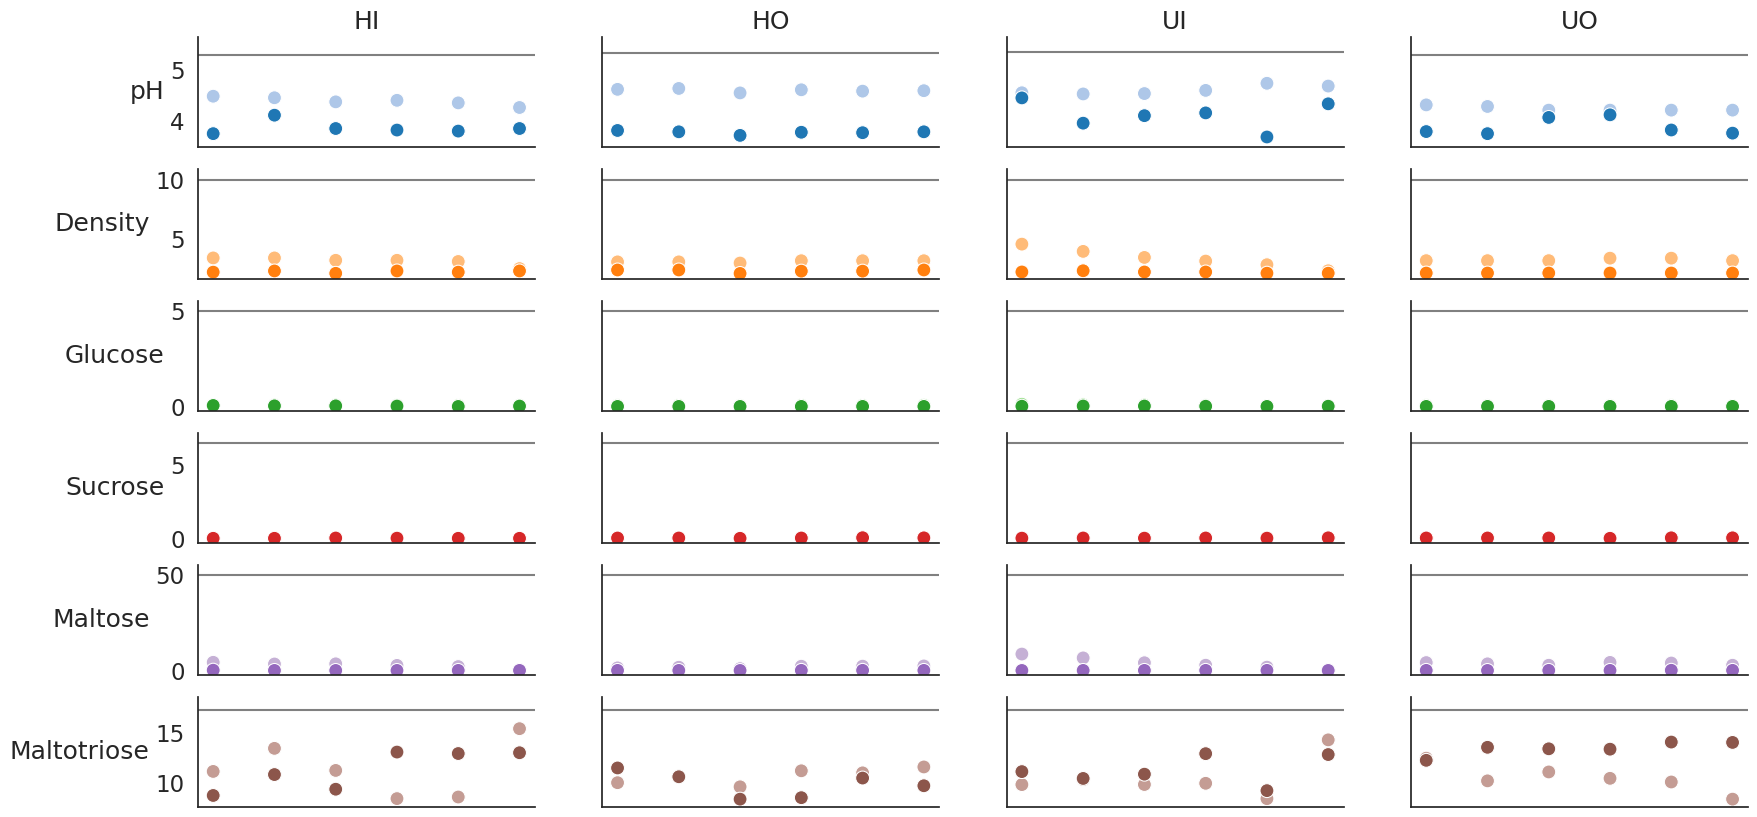

In [20]:
# do it manually
fig = plt.figure(figsize=(20, 10))
# column and row control


treatments = ['HI', 'HO', 'UI', 'UO']
measurements = ['pH', 'Density', 'Glucose', 'Sucrose', 'Maltose', 'Maltotriose'] #, 'Alcohol (% v/v)']
colors = sns.color_palette('tab20', n_colors=len(measurements)*2)

nrow, ncol = len(measurements), len(treatments)
gs = fig.add_gridspec(nrow, ncol)
i = 0
for measurement, treatment  in itertools.product(measurements, treatments):
    print(measurement, treatment)
    ax = fig.add_subplot(gs[measurements.index(measurement), treatments.index(treatment)])
    

        
    subset = tidy_plotdf[tidy_plotdf['measurement'].eq(measurement) & tidy_plotdf['treatment'].eq(treatment)]
    color_ind = measurements.index(measurement)
    sns.scatterplot(data=subset, x='replicate', y='value', hue='timepoint (weeks)', ax=ax,
                    alpha=1, s=100,
                    palette=[colors[color_ind *2+1], colors[color_ind * 2]], legend=False)
    
    # plot baselines
    control_values = tidy_plotdf[tidy_plotdf['measurement'].eq(measurement) & tidy_plotdf['treatment'].eq(treatment.replace('I', 'C').replace('O','C'))]
    if len(control_values) > 0:
        ax.axhline(control_values['value'].mean(), color='gray', zorder=0)
    else:
        ax.axhline(0, color='gray', zorder=0)
    ax.set_ylabel(measurement, rotation=0, ha='right', va='center')
    ax.set_xlabel('Replicate')
    extend = 0.05
    ax.set_ylim(ax.get_ylim()[0]*(1-extend), ax.get_ylim()[1]*(1+extend))
    
    if i < 4:
        ax.set_title(treatment)
    
    if i % 4 != 0:
        ax.set_ylabel('')
        plt.tick_params(left=False, labelleft=False)
    
    if i < 24:
        ax.set_xlabel('')
        plt.tick_params(bottom=False, labelbottom=False)
        
    sns.despine()  
    
    i += 1
    
plt.savefig('/data/mhoffert/fiererlab/beer/figures/SF1.png', dpi=300, bbox_inches='tight')
        
    
    


making hulls
1 week
3 week
making hulls
H 1 week
H 3 week
U 1 week
U 3 week
making hulls
I 1 week
I 3 week
O 1 week
O 3 week
making hulls
H I 1 week
H I 3 week
H O 1 week
H O 3 week
U I 1 week
U I 3 week
U O 1 week
U O 3 week


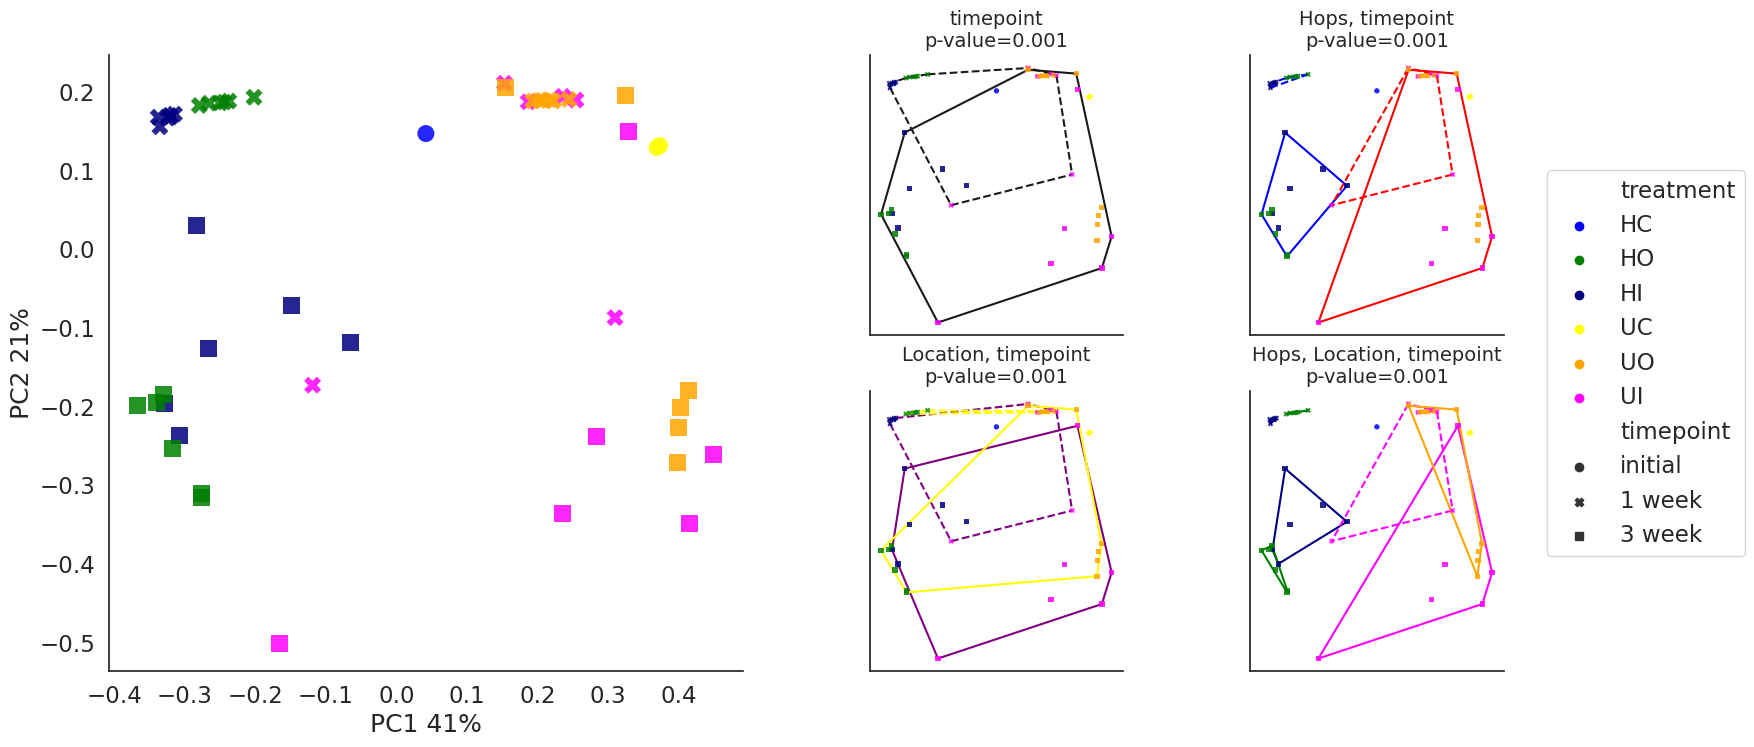

In [77]:
fig = plt.figure(figsize=(18, 8))
gs = fig.add_gridspec(2, 4)
ax = fig.add_subplot(gs[:2, :2])
x, y = 'PC1', 'PC2'
sns.scatterplot(data=braycurtis_community_plotdf, x=x, y=y, hue='treatment', ax=ax, style='timepoint',
                linewidth=0, alpha=0.85, s=150, 
                hue_order=['HC', 'HO', 'HI', 'UC', 'UO', 'UI'], 
                palette=['blue', 'green', 'navy', 'yellow', 'orange', 'magenta'])

ax.set_ylabel(f'{y} {braycurtis_community_pcoa.proportion_explained.loc[y]*100:.0f}%')
ax.set_xlabel(f'{x} {braycurtis_community_pcoa.proportion_explained.loc[x]*100:.0f}%')

lgd = ax.legend(loc='center left', bbox_to_anchor=(2.25, 0.5))
sns.despine()

# colors need to be manually specified
colors = [['k', 'k'], ['blue', 'blue', 'red', 'red'], ['purple', 'purple', 'yellow', 'yellow'], ['navy', 'navy', 'green', 'green', 'magenta','magenta', 'orange', 'orange']]

for ( pm1, pm2), test_condition, condition_colors in zip(itertools.product([0,1], [2,3]), 
                                       ['timepoint', 'Hops + timepoint', 'Location + timepoint', 'Hops + Location + timepoint'],
                                       colors):
    ax = fig.add_subplot(gs[pm1, pm2])
    conditions = test_condition.split(' + ')
   
    # scatter underlying data 
    sns.scatterplot(data=braycurtis_community_plotdf, x=x, y=y, hue='treatment', ax=ax, style='timepoint',
                linewidth=0, alpha=0.85, s=15, 
                hue_order=['HC', 'HO', 'HI', 'UC', 'UO', 'UI'], 
                palette=['blue', 'green', 'navy', 'yellow', 'orange', 'magenta'], legend=False)
    
    print('making hulls')
    # Plotting PERMANOVA hulls
    # --------------------------------------------------------------------------------
    # make a subset df to safely add columns
    pm_plotdf = braycurtis_community_plotdf.copy(deep=True)

    # make a condition column with the combined condition columns
    pm_plotdf['condition'] = pm_plotdf[conditions].apply(lambda row: ' '.join([row[c] for c in conditions]), axis=1)
    # get unique values: 1 simplex / permanova per unique value
    unique_combos = pm_plotdf[~pm_plotdf['timepoint'].eq('initial')]['condition'].unique()
    # maybe need to map to ints?
    condition_map = dict((unique_combos[i], i) for i in range(len(unique_combos)))

    for uc, uc_c in zip(unique_combos, condition_colors):
        print(uc)
        if '1 week' in uc:
            linestyle = '--'
        else:
            linestyle = '-'
        # get points relevant to group
        subset = pm_plotdf[pm_plotdf['condition'].eq(uc)]
        points = subset[['PC1', 'PC2']].values
        hull = ConvexHull(points)

        # plot hulls
        for simplex in hull.simplices:
            plt.plot(points[simplex, 0], points[simplex, 1], ls=linestyle, color=uc_c, zorder=0)
            
    # do PERMANOVA
    # --------------------------------------------------------------------------------          
    # do permanova
    permanova_samples = pm_plotdf[~pm_plotdf['timepoint'].eq('initial')]['Sample ID'].unique()
    # get grouping from condition
    grouping = pm_plotdf.set_index('Sample ID').loc[permanova_samples, 'condition'].values
    # make distance matrix
    dm = DistanceMatrix(braycurtis_community_dists.loc[permanova_samples, permanova_samples].values)
    dm.ids = permanova_samples
    # perform test
    permanova_result = permanova(dm, grouping = grouping)
    pval = permanova_result['p-value']
    
    plt.tick_params(labelleft=False, labelbottom=False, bottom=False, left=False)
    ax.set_title(f'{", ".join(conditions)}\np-value={pval}', fontsize=14)
    ax.set_ylabel(' ')
    ax.set_xlabel(' ')
    
    
# ax = fig.add_subplot(1,2,2)
# x, y = 'PC1', 'PC2'
# sns.scatterplot(data=braycurtis_functional_plotdf[braycurtis_functional_plotdf.timepoint.eq('3 week')], 
#                 x=x, y=y, hue='treatment', ax=ax, style='timepoint',
#                 linewidth=0, alpha=0.25, s=150, 
#                 hue_order=['HC', 'HO', 'HI', 'UC', 'UO', 'UI'], 
#                 palette=['blue', 'green', 'navy', 'yellow', 'orange', 'magenta'], legend=False)

# ax.set_ylabel(f'{y} {braycurtis_functional_pcoa.proportion_explained.loc[y]*100:.0f}%')
# ax.set_xlabel(f'{x} {braycurtis_functional_pcoa.proportion_explained.loc[x]*100:.0f}%')

# lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
sns.despine()
fig.subplots_adjust(wspace=0.5)
# plt.savefig('/data/mhoffert/fiererlab/beer/figures/figure2.png', dpi=300, bbox_inches='tight', bbox_extra_artists=(lgd,))

## Figure 2B
Organisms correlated with PC1 and PC2

In [364]:
plotdf['species'].unique()

array(['S_cerevisiae', 'g__Enterobacter', 's__Gluconobacter_A japonicus',
       's__Lacticaseibacillus paracasei',
       's__Lentilactobacillus parabuchneri',
       's__Levilactobacillus brevis', 's__Pantoea agglomerans',
       's__Pseudescherichia vulneris',
       's__Schleiferilactobacillus harbinensis'], dtype=object)

S_cerevisiae
g__Enterobacter
s__Gluconobacter_A japonicus
s__Lacticaseibacillus paracasei
s__Lentilactobacillus parabuchneri
s__Levilactobacillus brevis
s__Pantoea agglomerans
s__Pseudescherichia vulneris
s__Schleiferilactobacillus harbinensis


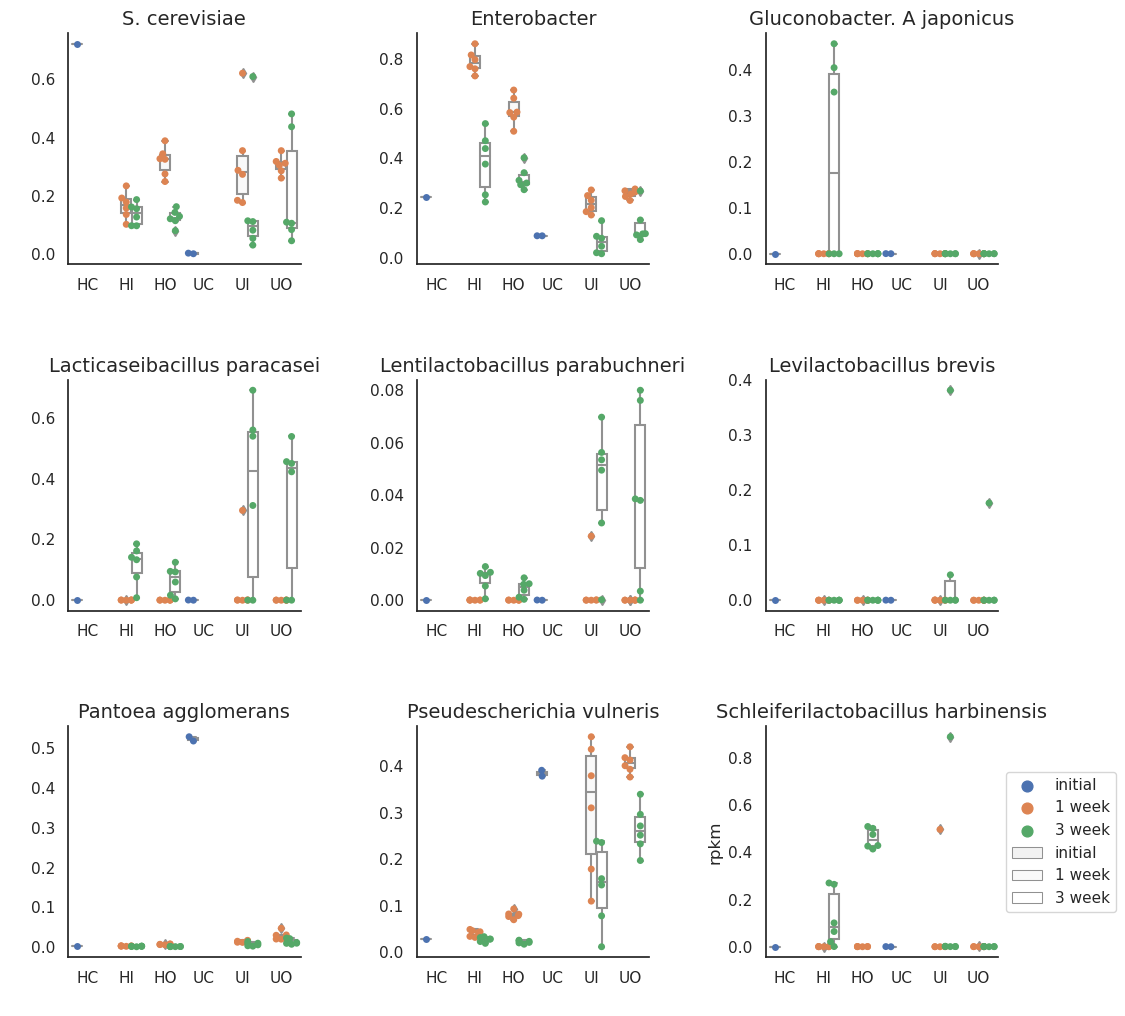

In [871]:
species = plotdf['species'].unique()
fig = plt.figure(figsize=(12, 12))
i = 1
for s in species:
    print(s)
    ax = fig.add_subplot(3, 3,i)

    sns.swarmplot(data=plotdf[plotdf['species'].eq(s)],
                  x='treatment', y='rpkm', hue='timepoint', dodge=True,
                 )
    
    sns.boxplot(data=plotdf[plotdf['species'].eq(s)],
                  x='treatment', y='rpkm', hue='timepoint', dodge=True,
                  color='white')
    
    if i == len(species):
        lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    else:
        ax.set_ylabel(' ')
        ax.get_legend().remove()
    
    ax.set_xlabel(' ')
    ax.set_title(s.split('__')[-1].replace('_', '. '), fontsize=14)
    sns.despine()
    
    
    i += 1
fig.subplots_adjust(wspace=0.5, hspace=0.5)
plt.savefig('/data/mhoffert/fiererlab/beer/figures/figure2_alt.png', bbox_inches='tight', dpi=300)

In [411]:
treatments

['HI', 'HO', 'UI', 'UO']

In [426]:
table_wide = table_tidy[~table_tidy['sample_name'].isin(['CommStd', 'ExtB1', 'NTC'])].set_index(['sample_name', 'species'])['rpkm'].unstack().fillna(0).T
table_norm = table_wide.divide(table_wide.sum(0))

In [461]:
plotdf = pd.merge(table_norm.stack().rename('rpkm').reset_index(), md, left_on='sample_name', right_on='Sample ID')

In [458]:
plotdf = pd.merge(table_tidy, md, left_on='sample_name', right_on='Sample ID')

S_cerevisiae HI
S_cerevisiae HO
S_cerevisiae UI
S_cerevisiae UO
g__Enterobacter HI
g__Enterobacter HO
g__Enterobacter UI
g__Enterobacter UO
s__Gluconobacter_A japonicus HI
s__Gluconobacter_A japonicus HO
s__Gluconobacter_A japonicus UI
s__Gluconobacter_A japonicus UO
s__Lacticaseibacillus paracasei HI
s__Lacticaseibacillus paracasei HO
s__Lacticaseibacillus paracasei UI
s__Lacticaseibacillus paracasei UO
s__Lentilactobacillus parabuchneri HI
s__Lentilactobacillus parabuchneri HO
s__Lentilactobacillus parabuchneri UI
s__Lentilactobacillus parabuchneri UO
s__Levilactobacillus brevis HI
s__Levilactobacillus brevis HO
s__Levilactobacillus brevis UI
s__Levilactobacillus brevis UO
s__Pantoea agglomerans HI
s__Pantoea agglomerans HO
s__Pantoea agglomerans UI
s__Pantoea agglomerans UO
s__Pseudescherichia vulneris HI
s__Pseudescherichia vulneris HO
s__Pseudescherichia vulneris UI
s__Pseudescherichia vulneris UO
s__Schleiferilactobacillus harbinensis HI
s__Schleiferilactobacillus harbinensis HO


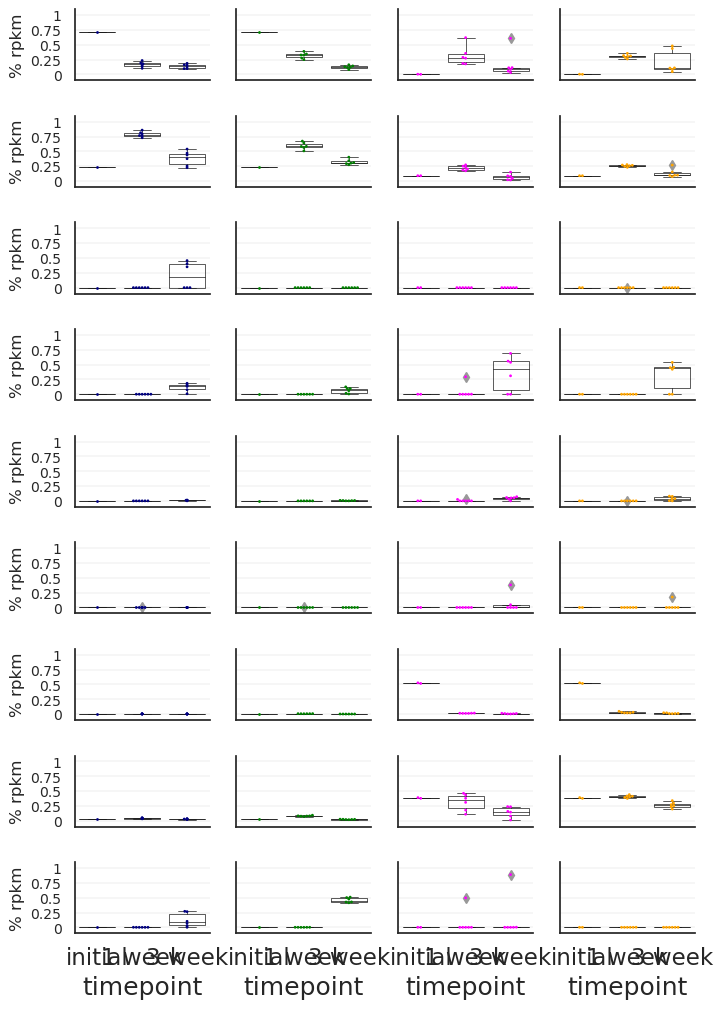

In [507]:
species = plotdf['species'].unique()
fig = plt.figure(figsize=(8, 12))
i = 1
x_map = {'initial':0,
'1 week':1,
'3 week':3}
colors = ['navy', 'green', 'magenta', 'orange']
row_axes = []

PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'k'},
    'medianprops':{'color':'k'},
    'whiskerprops':{'color':'k'},
    'capprops':{'color':'k'}
}

for s, t in list(itertools.product(species, treatments)):
    print(s, t)
    if len(row_axes) == 4:
        row_axes = []
    if i % 4 == 1:
        ax = fig.add_subplot(9, 4, i)
    else:
        ax = fig.add_subplot(9, 4, i, sharey=row_axes[-1])
    row_axes.append(ax)

    sns.swarmplot(data=plotdf[plotdf['species'].eq(s) & plotdf['treatment'].isin([t, t.replace('O', 'C').replace('I', 'C')])],
                  x='timepoint', y='rpkm', ax=ax, alpha=1, s=2,
                  zorder=3, color=colors[treatments.index(t)]
                  )
    
    sns.boxplot(data=plotdf[plotdf['species'].eq(s) & plotdf['treatment'].isin([t, t.replace('O', 'C').replace('I', 'C')])],
                  x='timepoint', y='rpkm', ax=ax,
                 color='white', zorder=2, whis=2.5, linewidth=0.5, **PROPS
                  )
    
    # sns.pointplot(data=plotdf[plotdf['species'].eq(s) & plotdf['treatment'].isin([t, t.replace('O', 'C').replace('I', 'C')])],
    #               x='timepoint', y='rpkm', ax=ax,
    #               zorder=1, color=colors[treatments.index(t)],
    #               markers='', errwidth=0, scale=0.5
    #           )
    
    if i < 33:
        plt.tick_params(labelbottom=False, bottom=False)
        ax.set_xlabel(' ')
        
    yticklocs = [0, 0.25, 0.5, 0.75, 1]
    ax.set_yticks(yticklocs)
    
    if i % 4 == 1:
        ax.set_yticklabels(yticklocs, fontsize=10)
        ax.set_ylabel('% rpkm', fontsize=12)
    else:
        plt.tick_params(labelleft=False)
        ax.set_ylabel(' ')
        
    for ytick in yticklocs:
        ax.axhline(ytick, linewidth=0.1, zorder=0, color='gray')
    ax.set_ylim(-0.1, 1.1)

    # ax.get_legend().remove()
    
    # else:
    #     ax.set_xticks([0,1,3])
    #     ax.set_xticklabels(['initial', '1 week', '3 week'])

    # ax.set_xlim(0, 5)
#     sns.boxplot(data=plotdf[plotdf['species'].eq(s)],
#                   x='treatment', y='rpkm', hue='timepoint', dodge=True,
#                   color='white')
    
#     if i == len(species):
#         lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
#     else:
#         ax.set_ylabel(' ')
#         ax.get_legend().remove()
    
#     ax.set_xlabel(' ')
#     ax.set_title(s.split('__')[-1].replace('_', '. '), fontsize=14)
    sns.despine()
    
    
    i += 1
fig.subplots_adjust(hspace=0.5)

In [528]:
species

array(['S_cerevisiae', 'g__Enterobacter', 's__Gluconobacter_A japonicus',
       's__Lacticaseibacillus paracasei',
       's__Lentilactobacillus parabuchneri',
       's__Levilactobacillus brevis', 's__Pantoea agglomerans',
       's__Pseudescherichia vulneris',
       's__Schleiferilactobacillus harbinensis'], dtype=object)

S_cerevisiae H
S_cerevisiae U
g__Enterobacter H
g__Enterobacter U
s__Pseudescherichia vulneris H
s__Pseudescherichia vulneris U
s__Pantoea agglomerans H
s__Pantoea agglomerans U
s__Gluconobacter_A japonicus H
s__Gluconobacter_A japonicus U
s__Lacticaseibacillus paracasei H
s__Lacticaseibacillus paracasei U
s__Lentilactobacillus parabuchneri H
s__Lentilactobacillus parabuchneri U
s__Levilactobacillus brevis H
s__Levilactobacillus brevis U
s__Schleiferilactobacillus harbinensis H
s__Schleiferilactobacillus harbinensis U


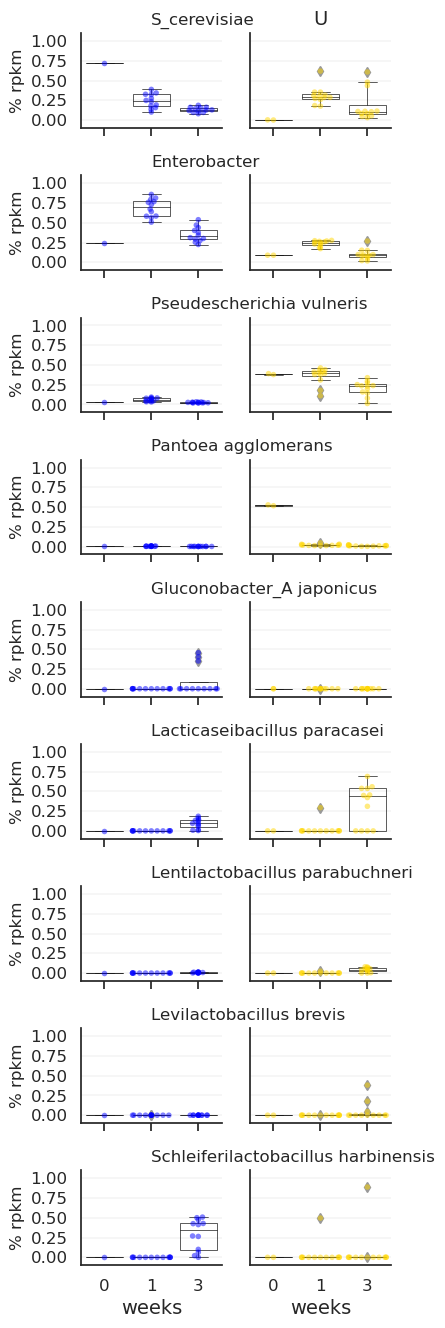

In [862]:
species = plotdf['species'].unique()
fig = plt.figure(figsize=(4, 16))
i = 1
x_map = {'initial':0,
'1 week':1,
'3 week':3}
colors = ['blue', 'gold']
col_axes = []

PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'k'},
    'medianprops':{'color':'k'},
    'whiskerprops':{'color':'k'},
    'capprops':{'color':'k'}
}
species = ['S_cerevisiae', 
           'g__Enterobacter', 
           's__Pseudescherichia vulneris',
           's__Pantoea agglomerans',
           's__Gluconobacter_A japonicus',
           's__Lacticaseibacillus paracasei',
           's__Lentilactobacillus parabuchneri',
           's__Levilactobacillus brevis', 
           's__Schleiferilactobacillus harbinensis']
for s, t in list(itertools.product( species, ['H', 'U'])):
    print(s, t)
    # if len(col_axes) == 4:
    #     col_axes = []
    # if i % 4 == 1:
    #     ax = fig.add_subplot(2, 9, i)
    # else:
    #     ax = fig.add_subplot(2, 9, i, shareycol_axes[-1])
    # row_axes.append(ax)
    
    ax = fig.add_subplot(9, 2, i)
    sns.swarmplot(data=plotdf[plotdf['species'].eq(s) & plotdf['Hops'].eq(t)],
                  x='timepoint', y='rpkm', ax=ax, alpha=0.5, s=4,
                  zorder=3, color=colors[['H', 'U'].index(t)]
                  )
    
    sns.boxplot(data=plotdf[plotdf['species'].eq(s) & plotdf['Hops'].eq(t)],
                  x='timepoint', y='rpkm', ax=ax,
                 color='white', zorder=2, whis=2.5, linewidth=0.5, **PROPS
                  )
    
    # sns.pointplot(data=plotdf[plotdf['species'].eq(s) & plotdf['treatment'].isin([t, t.replace('O', 'C').replace('I', 'C')])],
    #               x='timepoint', y='rpkm', ax=ax,
    #               zorder=1, color=colors[treatments.index(t)],
    #               markers='', errwidth=0, scale=0.5
    #           )
    if i < 3:
        ax.set_title(t, fontsize=14)
    if i % 2 == 1:
        newtitle = s.split("__")[-1]
        ax.set_title(f'{newtitle}', fontsize=12, rotation=0, ha='left')
    
    if i % 2 != 1:
        plt.tick_params(labelleft=False, left=False)
        ax.set_ylabel(' ')
    else:
        ax.set_ylabel('% rpkm', fontsize=12)
        
    plt.tick_params(labelsize=12)    
    yticklocs = [0, 0.25, 0.5, 0.75, 1]
    ax.set_yticks(yticklocs)
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlabel(' ')
    if i < 17:
        plt.tick_params(labelbottom=False, bottom=True)
    else:
        ax.set_xticklabels([0, 1, 3])
        # ax.set_xticks([0, 1, 3])
        
        ax.set_xlabel('weeks', fontsize=14)
#     if i % 4 == 1:
#         ax.set_yticklabels(yticklocs, fontsize=10)
#         ax.set_ylabel('% rpkm', fontsize=12)
#     else:
#         plt.tick_params(labelleft=False)
#         ax.set_ylabel(' ')
        
    for ytick in yticklocs:
        ax.axhline(ytick, linewidth=0.1, zorder=0, color='gray')


    # ax.get_legend().remove()
    
    # else:
    #     ax.set_xticks([0,1,3])
    #     ax.set_xticklabels(['initial', '1 week', '3 week'])

    # ax.set_xlim(0, 5)
#     sns.boxplot(data=plotdf[plotdf['species'].eq(s)],
#                   x='treatment', y='rpkm', hue='timepoint', dodge=True,
#                   color='white')
    
#     if i == len(species):
#         lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
#     else:
#         ax.set_ylabel(' ')
#         ax.get_legend().remove()
    
#     ax.set_xlabel(' ')
#     ax.set_title(s.split('__')[-1].replace('_', '. '), fontsize=14)
    sns.despine()
    
    
    i += 1
fig.subplots_adjust(hspace=0.5)
plt.savefig('/data/mhoffert/fiererlab/beer/figures/figure3.png', dpi=300, bbox_inches='tight')

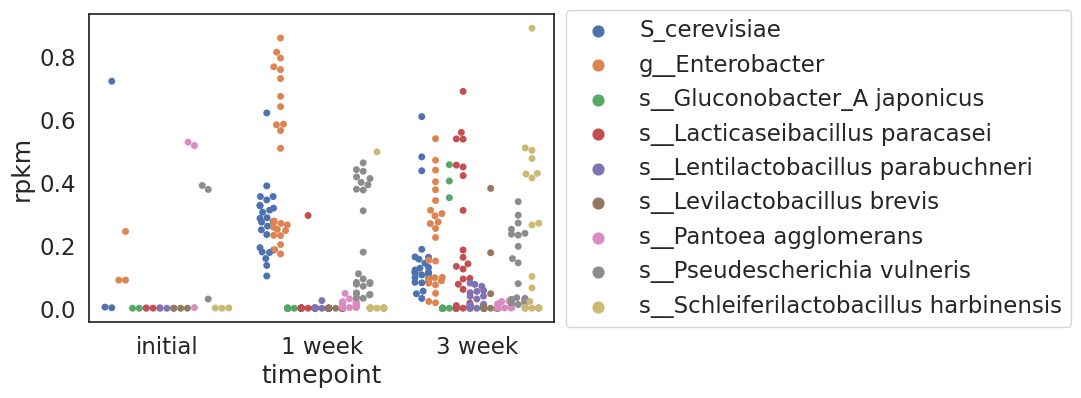

In [511]:
fig, ax = plt.subplots(figsize=(6,4))
sns.swarmplot(data=plotdf, x='timepoint', y='rpkm', hue='species', dodge=True)
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

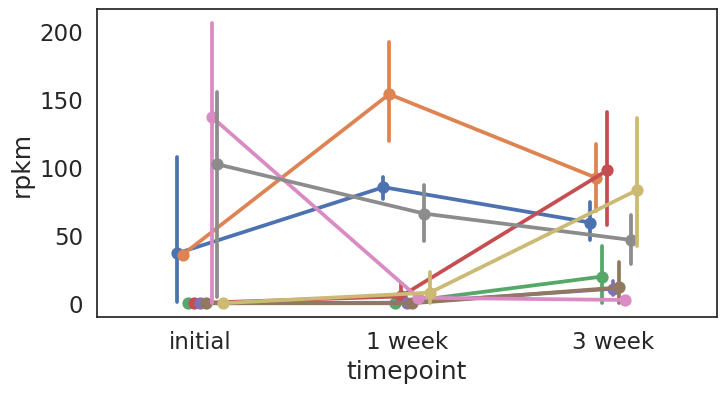

In [380]:
fig, ax = plt.subplots(figsize=(8,4))
sns.pointplot(data=plotdf,
              x='timepoint', y='rpkm', hue='species', dodge=True,
             )
ax.get_legend().remove()